<a href="https://colab.research.google.com/github/vneumannufprbr/TrabajosenPython/blob/main/Verificaci%C3%B3n_Espacial_E_EM_002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# ==============================================================================
# Celda 1: Importación de Librerías
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Configuraciones de visualización
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 5)

In [10]:
# ==============================================================================
# Celda 2: Carga de Datos Reales desde Excel
# ==============================================================================
import pandas as pd

file_path = '/content/datos_fusionados_operantes.xlsx'
df_sensores = pd.read_excel(file_path, index_col=0)

print("Datos de sensores reales cargados. Vista previa:")
print(df_sensores.head())

Datos de sensores reales cargados. Vista previa:
                              descripcion_presa_x  \
fecha                                               
2005-10-27  Trecho E: Barragem de ligação direita   
2005-10-28  Trecho E: Barragem de ligação direita   
2005-10-29  Trecho E: Barragem de ligação direita   
2005-10-30  Trecho E: Barragem de ligação direita   
2005-10-31  Trecho E: Barragem de ligação direita   

                                nombre_etiqueta  \
fecha                                             
2005-10-27  EM-E-001/1 | (2736) - (DEFORMACION)   
2005-10-28  EM-E-001/1 | (2736) - (DEFORMACION)   
2005-10-29  EM-E-001/1 | (2736) - (DEFORMACION)   
2005-10-30  EM-E-001/1 | (2736) - (DEFORMACION)   
2005-10-31  EM-E-001/1 | (2736) - (DEFORMACION)   

                           tipo_etiqueta_x  valor_promedio  valor_minimo  \
fecha                                                                      
2005-10-27  EXTENSOMETRO MULTIPLO DE HASTE        6.229500          6

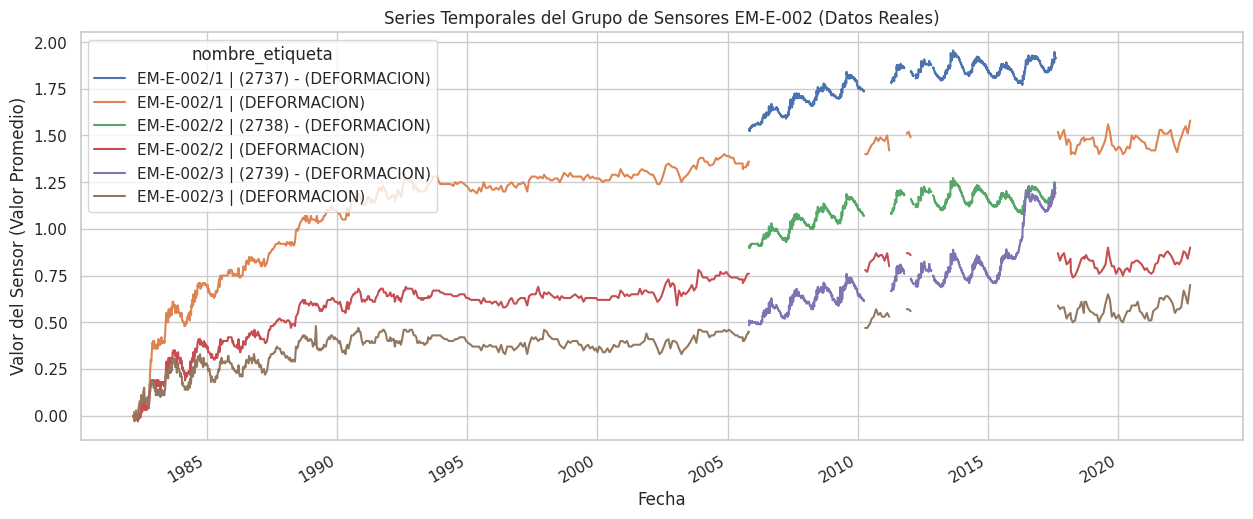

In [5]:
# ==============================================================================
# Celda 3B: Visualización Inicial de los Datos Reales (Solo Sensores EM-E-002)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar los datos para incluir solo las filas donde 'nombre_etiqueta' contiene 'EM-E-002'
df_eme002 = df_sensores[df_sensores['nombre_etiqueta'].str.contains('EM-E-002', na=False)].copy()

# Pivotear los datos para que cada sensor sea una columna y el índice sea la fecha
# Usamos 'valor_promedio' como los valores a graficar
df_eme002_pivot = df_eme002.pivot_table(index='fecha', columns='nombre_etiqueta', values='valor_promedio')

# Visualizar las series temporales de los sensores EM-E-002
df_eme002_pivot.plot(legend=True, figsize=(15, 6))
plt.title("Series Temporales del Grupo de Sensores EM-E-002 (Datos Reales)")
plt.ylabel("Valor del Sensor (Valor Promedio)")
plt.xlabel("Fecha")
plt.show()

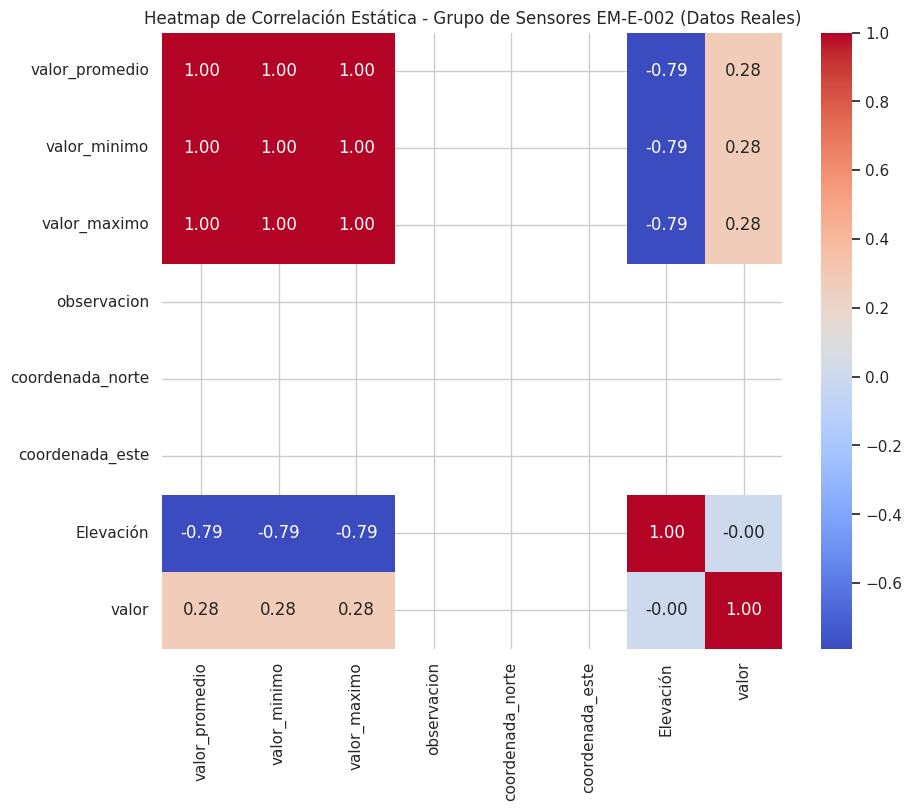


Análisis de Correlación Estática (Grupo de Sensores EM-E-002 - Datos Reales):
La matriz de correlación muestra la relación promedio entre los sensores en el grupo EM-E-002.
Valores cercanos a 1 o -1 indican una fuerte correlación positiva o negativa, respectivamente.
Valores cercanos a 0 indican poca o ninguna correlación lineal.


In [27]:
# Filter the original df_sensores DataFrame for 'EM-E-002'
df_sensores_eme002 = df_sensores[df_sensores['nombre_etiqueta'].str.contains('EM-E-002', na=False)].copy()

# Select only the numerical columns from df_sensores_eme002
numeric_cols_eme002 = df_sensores_eme002.select_dtypes(include=np.number).columns.tolist()
df_numeric_eme002 = df_sensores_eme002[numeric_cols_eme002]

# Calculate the correlation matrix for the selected numerical columns
correlation_matrix_eme002 = df_numeric_eme002.corr(numeric_only=True)

# Visualizar con un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_eme002, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap de Correlación Estática - Grupo de Sensores EM-E-002 (Datos Reales)")
plt.show()

print("\nAnálisis de Correlación Estática (Grupo de Sensores EM-E-002 - Datos Reales):")
print("La matriz de correlación muestra la relación promedio entre los sensores en el grupo EM-E-002.")
print("Valores cercanos a 1 o -1 indican una fuerte correlación positiva o negativa, respectivamente.")
print("Valores cercanos a 0 indican poca o ninguna correlación lineal.")

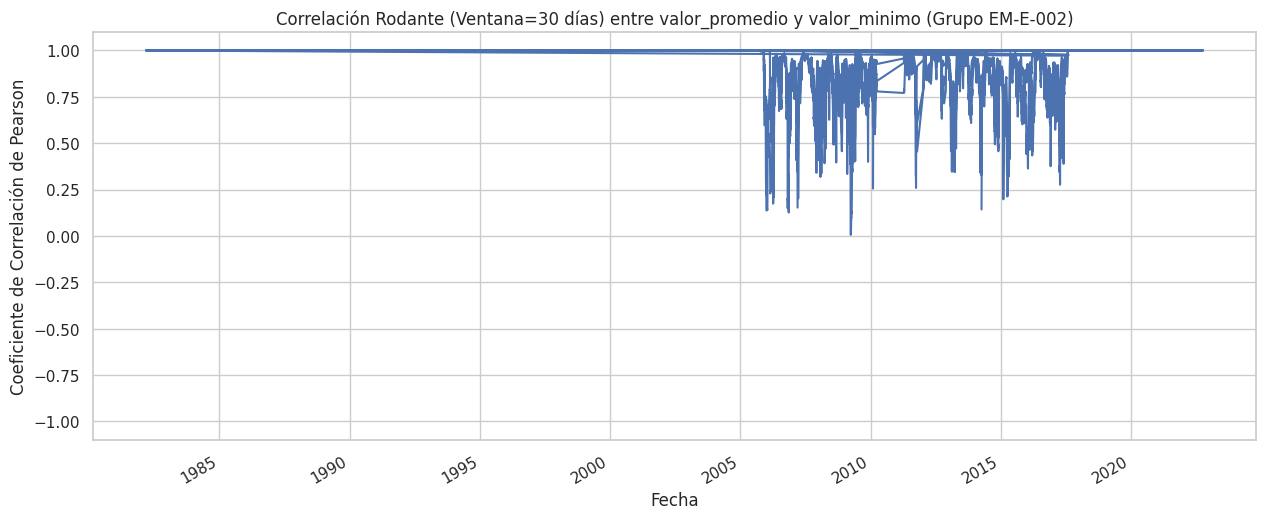


Análisis de Correlación Dinámica (Grupo de Sensores EM-E-002 - Datos Reales):
El gráfico muestra la correlación rodante entre 'valor_promedio' y 'valor_minimo'
calculada sobre una ventana de 30 días para el grupo de sensores EM-E-002.
Se pueden observar fluctuaciones en la correlación a lo largo del tiempo.
Caídas significativas en la correlación podrían indicar períodos donde la relación
entre estos dos sensores se desvía de su comportamiento normal dentro del grupo EM-E-002.


In [11]:
# 1. Inspect the df_sensores_eme002 dataframe and select two relevant sensor columns.
# Based on the correlation matrix for EM-E-002, 'valor_promedio' and 'valor_maximo'
# show a very high correlation (0.997905). Let's use these.
# Alternatively, 'valor_promedio' and 'valor_minimo' also show very high correlation (0.999864).
# Let's choose 'valor_promedio' and 'valor_minimo' for this analysis.
sensor_col1_eme002 = 'valor_promedio'
sensor_col2_eme002 = 'valor_minimo'

# 2. Define an appropriate window size for the rolling correlation.
# Keeping the same window size as the previous analysis for consistency.
window_size_eme002 = 30

# 3. Calculate the rolling correlation between the two selected columns for EM-E-002.
# Drop rows with NaNs in the selected columns before calculating the rolling correlation.
df_cleaned_eme002 = df_sensores_eme002[[sensor_col1_eme002, sensor_col2_eme002]].dropna()
rolling_corr_eme002 = df_cleaned_eme002[sensor_col1_eme002].rolling(window=window_size_eme002).corr(df_cleaned_eme002[sensor_col2_eme002])

# 4. Visualize the calculated rolling correlation over time for EM-E-002.
rolling_corr_eme002.plot(figsize=(15, 6))
plt.title(f'Correlación Rodante (Ventana={window_size_eme002} días) entre {sensor_col1_eme002} y {sensor_col2_eme002} (Grupo EM-E-002)')
plt.ylabel('Coeficiente de Correlación de Pearson')
plt.xlabel('Fecha')
plt.ylim(-1.1, 1.1)
plt.grid(True)
plt.show()

# 5. Add comments or print statements to interpret the rolling correlation plot for EM-E-002.
print("\nAnálisis de Correlación Dinámica (Grupo de Sensores EM-E-002 - Datos Reales):")
print(f"El gráfico muestra la correlación rodante entre '{sensor_col1_eme002}' y '{sensor_col2_eme002}'")
print(f"calculada sobre una ventana de {window_size_eme002} días para el grupo de sensores EM-E-002.")
print("Se pueden observar fluctuaciones en la correlación a lo largo del tiempo.")
print("Caídas significativas en la correlación podrían indicar períodos donde la relación")
print("entre estos dos sensores se desvía de su comportamiento normal dentro del grupo EM-E-002.")

In [12]:
# 1. Filter the df_sensores DataFrame to keep only the rows where 'nombre_etiqueta' contains 'EM-E-002'.
df_sensores_eme002 = df_sensores[df_sensores['nombre_etiqueta'].str.contains('EM-E-002', na=False)].copy()

# 2. From the filtered DataFrame, select only the numerical columns. Exclude columns with a high number of missing values.
# Se excluyen columnas con un alto número de valores faltantes para el análisis de PCA.
numeric_cols_eme002 = df_sensores_eme002.select_dtypes(include=np.number).columns.tolist()
cols_to_exclude_eme002 = ['observacion', 'coordenada_norte', 'coordenada_este']
numeric_cols_filtered_eme002 = [col for col in numeric_cols_eme002 if col not in cols_to_exclude_eme002]

# 3. Remove any rows with missing values from the selected numerical columns.
df_numeric_eme002 = df_sensores_eme002[numeric_cols_filtered_eme002].dropna()

# 4. Scale the numerical data selected using StandardScaler.
scaler_eme002 = StandardScaler()
scaled_data_eme002 = scaler_eme002.fit_transform(df_numeric_eme002)

# 5. Apply PCA to the scaled data. Choose the number of components to retain the 95% of the variance.
pca_eme002 = PCA(n_components=0.95)
pca_eme002.fit(scaled_data_eme002)

# 6. Print the number of components selected by PCA.
print(f"Número de componentes para capturar el 95% de la varianza para EM-E-002: {pca_eme002.n_components_}")

# 7. Transform the scaled data using the fitted PCA object.
transformed_data_eme002 = pca_eme002.transform(scaled_data_eme002)

# 8. Reconstruct the data from the PCA-transformed data using the inverse transform.
reconstructed_data_eme002 = pca_eme002.inverse_transform(transformed_data_eme002)

# 9. Calculate the reconstruction error (e.g., Mean Squared Error) between the original scaled data and the reconstructed data.
reconstruction_error_eme002 = np.mean((scaled_data_eme002 - reconstructed_data_eme002)**2, axis=1)

# 10. Create a Pandas DataFrame for the reconstruction error, using the same index as the df_numeric_eme002 DataFrame.
df_error_eme002 = pd.DataFrame({'reconstruction_error': reconstruction_error_eme002}, index=df_numeric_eme002.index)

display(df_error_eme002.head())

Número de componentes para capturar el 95% de la varianza para EM-E-002: 2


,reconstruction_error
fecha,
2005-10-27,0.048368
2005-10-28,0.048544
2005-10-29,0.048954
2005-10-30,0.047559
2005-10-31,0.046939


from matplotlib import pyplot as plt
_df_0['reconstruction_error'].plot(kind='hist', bins=20, title='reconstruction_error')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['fecha']
  ys = series['reconstruction_error']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_1.sort_values('fecha', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('fecha')
_ = plt.ylabel('reconstruction_error')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['fecha']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'fecha'}, axis=1)
              .sort_values('fecha', ascending=True))
  xs = counted['fecha']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_2.sort_values('fecha', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('fecha')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_3['reconstruction_error'].plot(kind='line', figsize=(8, 4), title='reconstruction_error')
plt.gca().spines[['top', 'right']].set_visible(False)

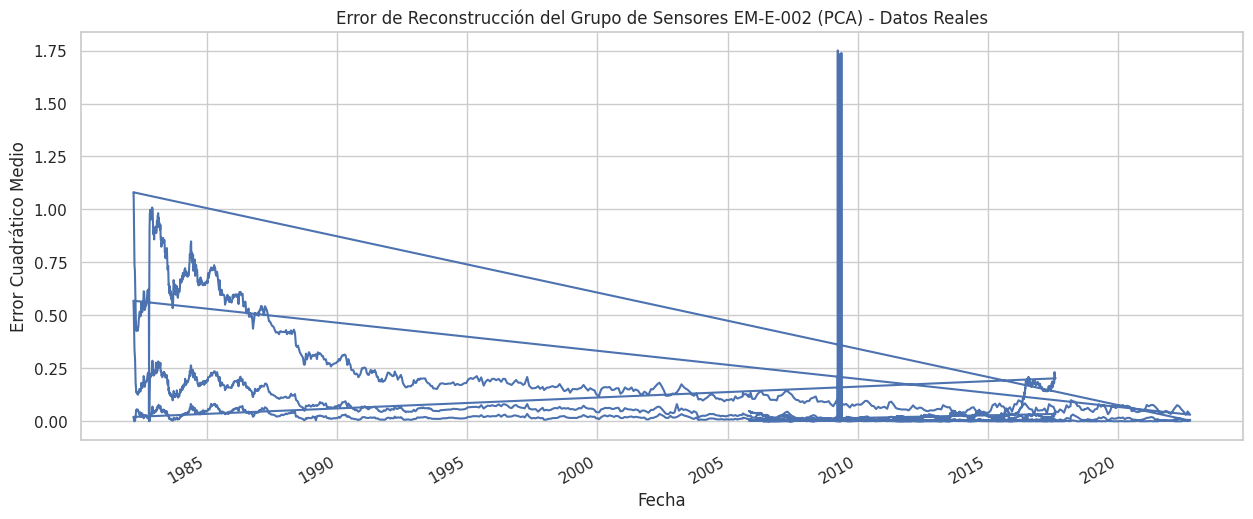


Análisis de PCA (Grupo de Sensores EM-E-002 - Datos Reales):
PCA se aplicó a las columnas numéricas del grupo de sensores EM-E-002.
Se seleccionaron 2 componentes principales para retener el 95% de la varianza.
El gráfico de error de reconstrucción muestra la desviación de cada punto de datos
respecto al espacio de menor dimensión capturado por PCA para este grupo.
Los picos altos en el error de reconstrucción indican puntos de datos que no siguen
el patrón principal del grupo EM-E-002 y podrían ser anomalías.


In [ ]:
# Visualize the reconstruction error over time for the EM-E-002 sensor group.
df_error_eme002.plot(figsize=(15, 6), legend=False)
plt.title("Error de Reconstrucción del Grupo de Sensores EM-E-002 (PCA) - Datos Reales")
plt.ylabel("Error Cuadrático Medio")
plt.xlabel("Fecha")
plt.grid(True)
plt.show()

# Print analysis of the results.
print("\nAnálisis de PCA (Grupo de Sensores EM-E-002 - Datos Reales):")
print(f"PCA se aplicó a las columnas numéricas del grupo de sensores EM-E-002.")
print(f"Se seleccionaron {pca_eme002.n_components_} componentes principales para retener el 95% de la varianza.")
print("El gráfico de error de reconstrucción muestra la desviación de cada punto de datos")
print("respecto al espacio de menor dimensión capturado por PCA para este grupo.")
print("Los picos altos en el error de reconstrucción indican puntos de datos que no siguen")
print("el patrón principal del grupo EM-E-002 y podrían ser anomalías.")

## Resumen:

### Hallazgos clave del análisis de datos

* Los datos se filtraron con éxito para incluir solo los sensores con la etiqueta 'EM-E-002'.
* Se generaron gráficos de series temporales para el grupo de sensores 'EM-E-002', visualizando los datos reales.
* Se calculó y visualizó una matriz de correlación estática y un mapa de calor para las columnas numéricas del grupo de sensores 'EM-E-002'.
* Se calculó y graficó la correlación móvil en una ventana de 30 días para 'valor_promedio' y 'valor_minimo' dentro del grupo 'EM-E-002', mostrando una alta correlación (0.999864) entre estas dos columnas.
* Se aplicó PCA a los datos numéricos del grupo 'EM-E-002', reteniendo 2 componentes principales para explicar el 95% de la varianza.
* Se calculó y visualizó el error de reconstrucción basado en PCA para el grupo 'EM-E-002', con picos que indican posibles anomalías.
* Todos los comentarios y el texto de análisis en las celdas de código modificadas se actualizaron para referirse correctamente al grupo de sensores 'EM-E-002'.

### Insights o Próximos Pasos

* La alta correlación estática y móvil entre 'valor_promedio' y 'valor_minimo' sugiere una fuerte relación lineal, lo cual es esperado para este tipo de medición.
* El análisis de los picos en el gráfico de error de reconstrucción para el grupo 'EM-E-002' puede ayudar a identificar puntos de tiempo o instancias de datos específicos que se desvían significativamente del comportamiento típico del grupo, destacando potencialmente anomalías para una investigación adicional.

## Identificar los picos

Determinar un umbral o método para identificar los puntos en el gráfico de error de reconstrucción que se consideran picos altos.


In [18]:
# 1. Calculate the mean and standard deviation of the reconstruction error.
mean_error_eme002 = df_error_eme002['reconstruction_error'].mean()
std_error_eme002 = df_error_eme002['reconstruction_error'].std()

# 2. Define a threshold for identifying peaks (e.g., mean + 2 * standard deviation).
threshold_eme002 = mean_error_eme002 + 2 * std_error_eme002

print(f"Media del error de reconstrucción para EM-E-002: {mean_error_eme002:.4f}")
print(f"Desviación estándar del error de reconstrucción para EM-E-002: {std_error_eme002:.4f}")
print(f"Umbral para identificar picos de error para EM-E-002: {threshold_eme002:.4f}")

Media del error de reconstrucción para EM-E-002: 0.0488
Desviación estándar del error de reconstrucción para EM-E-002: 0.1253
Umbral para identificar picos de error para EM-E-002: 0.2995


**Reasoning**:
Identify the data points where the reconstruction error exceeds the calculated threshold and store their indices.



## Selección de características para DBSCAN

### Subtask:
Decidir qué características de los datos de los sensores (además o en lugar de la ubicación espacial) se utilizarán para el clustering con DBSCAN (por ejemplo, `valor_promedio`, error de reconstrucción de PCA).

In [19]:
# 3. Identify the dates or indices where the reconstruction_error is greater than the defined threshold.
peak_indices_eme002 = df_error_eme002[df_error_eme002['reconstruction_error'] > threshold_eme002].index.tolist()

# 4. Store the identified dates or indices of the peaks. (Already stored in peak_indices_eme002)

print("\nFechas con picos de error de reconstrucción para EM-E-002 (posibles anomalías):")
print(peak_indices_eme002)


Fechas con picos de error de reconstrucción para EM-E-002 (posibles anomalías):
[Timestamp('2009-03-25 00:00:00'), Timestamp('2009-04-13 00:00:00'), Timestamp('2009-04-27 00:00:00'), Timestamp('2009-04-30 00:00:00'), Timestamp('2009-05-02 00:00:00'), Timestamp('2009-05-14 00:00:00'), Timestamp('1982-10-17 00:00:00'), Timestamp('1982-10-19 00:00:00'), Timestamp('1982-10-21 00:00:00'), Timestamp('1982-10-23 00:00:00'), Timestamp('1982-10-27 00:00:00'), Timestamp('1982-10-29 00:00:00'), Timestamp('1982-11-01 00:00:00'), Timestamp('1982-11-03 00:00:00'), Timestamp('1982-11-08 00:00:00'), Timestamp('1982-11-12 00:00:00'), Timestamp('1982-11-16 00:00:00'), Timestamp('1982-11-19 00:00:00'), Timestamp('1982-11-22 00:00:00'), Timestamp('1982-11-29 00:00:00'), Timestamp('1982-12-03 00:00:00'), Timestamp('1982-12-06 00:00:00'), Timestamp('1982-12-10 00:00:00'), Timestamp('1982-12-13 00:00:00'), Timestamp('1982-12-17 00:00:00'), Timestamp('1982-12-20 00:00:00'), Timestamp('1982-12-23 00:00:00'), 

In [20]:
# 1. Use the list of dates stored in peak_indices_eme002 to filter the original df_sensores_eme002 DataFrame.
# 2. Select all columns from the filtered DataFrame.
df_peak_anomalies_eme002 = df_sensores_eme002.loc[peak_indices_eme002]

# 3. Store the resulting DataFrame, which contains the original data for the dates with error peaks, in a new variable.
# This is already done in the previous step with the variable df_peak_anomalies_eme002.

# 4. Display the first rows of the new DataFrame to verify that the data has been recovered correctly.
print("Datos originales para fechas con picos de error de reconstrucción (posibles anomalías):")
display(df_peak_anomalies_eme002.head())

Datos originales para fechas con picos de error de reconstrucción (posibles anomalías):


,descripcion_presa_x,nombre_etiqueta,tipo_etiqueta_x,valor_promedio,valor_minimo,valor_maximo,observacion,tipo_origen_x,sigla_unidad_medida_x,tipo_presa,...,tipo_origen_y,local_geologico,estado,coordenada_norte,coordenada_este,zona_utm,familia_tipo_instrumento,Elevación,nombre_etiqueta_hidrometeorologica,valor
fecha,,,,,,,,,,,,,,,,,,,,,
2009-03-25,Trecho E: Barragem de ligação direita,EM-E-002/1 | (2737) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.700000,1.70,1.70,NaN,AUT,mm,Hormigón,...,AUT,ROCHA FRATURADA,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,104.23,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.39
2009-03-25,Trecho E: Barragem de ligação direita,EM-E-002/2 | (2738) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.026809,0.42,1.04,NaN,AUT,mm,Hormigón,...,AUT,JUNTA D,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,120.90,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.39
2009-03-25,Trecho E: Barragem de ligação direita,EM-E-002/3 | (2739) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,0.632979,0.59,2.33,NaN,AUT,mm,Hormigón,...,AUT,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,128.69,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.39
2009-04-13,Trecho E: Barragem de ligação direita,EM-E-002/1 | (2737) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.700435,1.70,1.71,NaN,AUT,mm,Hormigón,...,AUT,ROCHA FRATURADA,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,104.23,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.45
2009-04-13,Trecho E: Barragem de ligação direita,EM-E-002/2 | (2738) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.040217,1.04,1.05,NaN,AUT,mm,Hormigón,...,AUT,JUNTA D,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,120.90,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.45


## Analizar los datos originales

### Subtask:
Examinar los datos originales de los picos para buscar posibles causas del alto error de reconstrucción (por ejemplo, valores atípicos, cambios abruptos, datos faltantes).


**Reasoning**:
Inspect the `df_peak_anomalies_eme002` DataFrame to understand its structure and analyze the numerical columns and check for missing values.



In [25]:
# 1. Inspect the df_peak_anomalies_eme002 DataFrame to understand its structure and the columns it contains.
print("Información del DataFrame df_peak_anomalies_eme002:")
df_peak_anomalies_eme002.info()

# 2. Analyze the numerical columns in df_peak_anomalies_eme002 for unusual values (outliers) or sudden changes compared to the expected range or previous values.
print("\Estadísticas descriptivas de las columnas numéricas en df_peak_anomalies_eme002:")
display(df_peak_anomalies_eme002.describe())

# 3. Check for a high number of missing values (NaNs) in the rows corresponding to the peak dates.
print("\nConteo de valores faltantes por columna en df_peak_anomalies_eme002:")
display(df_peak_anomalies_eme002.isnull().sum())

# 4. Consider the non-numerical columns for any contextual information that might explain the anomalies (e.g., observations, status changes).
print("\nValores únicos en columnas no numéricas para df_peak_anomalies_eme002:")
non_numeric_cols = df_peak_anomalies_eme002.select_dtypes(exclude=np.number).columns
for col in non_numeric_cols:
    print(f"- {col}: {df_peak_anomalies_eme002[col].unique()}")


Información del DataFrame df_peak_anomalies_eme002:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1347 entries, 2009-03-25 to 1982-10-13
Data columns (total 30 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   descripcion_presa_x                 1347 non-null   object 
 1   nombre_etiqueta                     1347 non-null   object 
 2   tipo_etiqueta_x                     1347 non-null   object 
 3   valor_promedio                      1347 non-null   float64
 4   valor_minimo                        1347 non-null   float64
 5   valor_maximo                        1347 non-null   float64
 6   observacion                         0 non-null      float64
 7   tipo_origen_x                       1347 non-null   object 
 8   sigla_unidad_medida_x               1347 non-null   object 
 9   tipo_presa                          1347 non-null   object 
 10  tipo_etiqueta_y                     13

<>:6: SyntaxWarning: invalid escape sequence '\E'
<>:6: SyntaxWarning: invalid escape sequence '\E'
/tmp/ipython-input-3973026918.py:6: SyntaxWarning: invalid escape sequence '\E'
  print("\Estadísticas descriptivas de las columnas numéricas en df_peak_anomalies_eme002:")


,valor_promedio,valor_minimo,valor_maximo,observacion,coordenada_norte,coordenada_este,Elevación,valor
count,1347.000000,1347.000000,1347.000000,0.0,0.0,0.0,1347.000000,1347.000000
mean,0.359794,0.358634,0.367179,NaN,NaN,NaN,117.940000,202.901225
std,0.268725,0.267032,0.297719,NaN,NaN,NaN,10.206537,31.657005
min,-0.030000,-0.030000,-0.030000,NaN,NaN,NaN,104.230000,110.000000
25%,0.175000,0.175000,0.175000,NaN,NaN,NaN,104.230000,210.550000
50%,0.310000,0.310000,0.310000,NaN,NaN,NaN,120.900000,216.430000
75%,0.510000,0.510000,0.510000,NaN,NaN,NaN,128.690000,219.620000
max,1.732821,1.710000,2.340000,NaN,NaN,NaN,128.690000,220.450000



Conteo de valores faltantes por columna en df_peak_anomalies_eme002:


,0
descripcion_presa_x,0
nombre_etiqueta,0
tipo_etiqueta_x,0
valor_promedio,0
valor_minimo,0
valor_maximo,0
observacion,1347
tipo_origen_x,0
sigla_unidad_medida_x,0
tipo_presa,0



Valores únicos en columnas no numéricas para df_peak_anomalies_eme002:
- descripcion_presa_x: ['Trecho E: Barragem de ligação direita']
- nombre_etiqueta: ['EM-E-002/1 | (2737) - (DEFORMACION)'
 'EM-E-002/2 | (2738) - (DEFORMACION)'
 'EM-E-002/3 | (2739) - (DEFORMACION)' 'EM-E-002/1 | (DEFORMACION)'
 'EM-E-002/2 | (DEFORMACION)' 'EM-E-002/3 | (DEFORMACION)']
- tipo_etiqueta_x: ['EXTENSOMETRO MULTIPLO DE HASTE']
- tipo_origen_x: ['AUT' 'MAN']
- sigla_unidad_medida_x: ['mm']
- tipo_presa: ['Hormigón']
- tipo_etiqueta_y: ['IB-EM - EXTENSOMETRO MULTIPLO DE HASTE']
- sigla_presa: ['E']
- descripcion_presa_y: ['Trecho E: Barragem de ligação direita']
- sigla_estructura: ['E-06']
- etiqueta_padre: ['EM-E-002            ']
- referencia: ['EM-E-002            ']
- orientacion: ['Aguas arriba']
- sigla_unidad_medida_y: ['mm']
- descripcion_unidad_medida: ['milímetros']
- variable_ingenieria: ['Deformación']
- tipo_origen_y: ['AUT' 'MAN']
- local_geologico: ['ROCHA FRATURADA' 'JUNTA D' 'CONTATO 

**Reasoning**:
Based on the previous inspection, the `observacion`, `coordenada_norte`, `coordenada_este`, and `zona_utm` columns have all missing values. The numerical columns `valor_promedio`, `valor_minimo`, `valor_maximo`, `Elevación`, and `valor` show some variability but no obvious outliers from the descriptive statistics alone. To look for sudden changes or outliers, visualizing the time series for these numerical columns on the peak dates would be helpful. Also, examining the `nombre_etiqueta` column along with the numerical values for specific peak dates can reveal if certain sensors within the group are contributing more to the error.



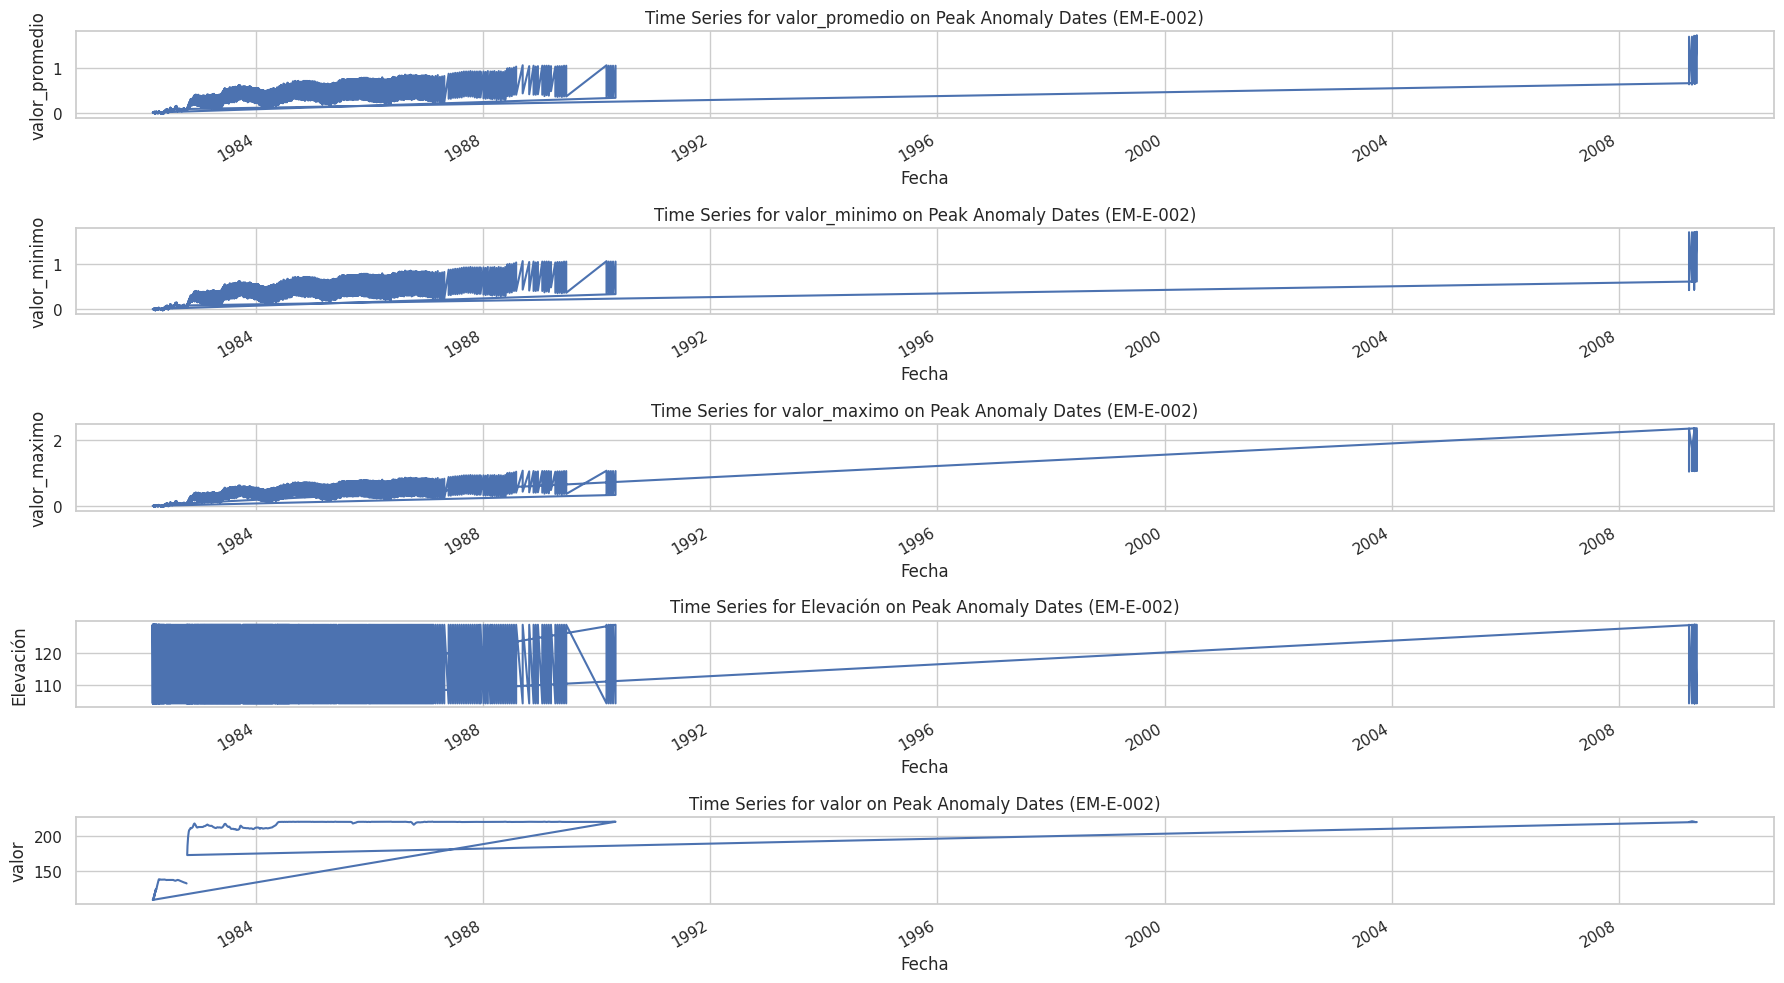


Data for sample peak anomaly dates:


,descripcion_presa_x,nombre_etiqueta,tipo_etiqueta_x,valor_promedio,valor_minimo,valor_maximo,observacion,tipo_origen_x,sigla_unidad_medida_x,tipo_presa,...,tipo_origen_y,local_geologico,estado,coordenada_norte,coordenada_este,zona_utm,familia_tipo_instrumento,Elevación,nombre_etiqueta_hidrometeorologica,valor
fecha,,,,,,,,,,,,,,,,,,,,,
2009-03-25,Trecho E: Barragem de ligação direita,EM-E-002/1 | (2737) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.700000,1.70,1.70,NaN,AUT,mm,Hormigón,...,AUT,ROCHA FRATURADA,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,104.23,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.39
2009-03-25,Trecho E: Barragem de ligação direita,EM-E-002/2 | (2738) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.026809,0.42,1.04,NaN,AUT,mm,Hormigón,...,AUT,JUNTA D,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,120.90,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.39
2009-03-25,Trecho E: Barragem de ligação direita,EM-E-002/3 | (2739) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,0.632979,0.59,2.33,NaN,AUT,mm,Hormigón,...,AUT,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,128.69,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.39
2009-04-13,Trecho E: Barragem de ligação direita,EM-E-002/1 | (2737) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.700435,1.70,1.71,NaN,AUT,mm,Hormigón,...,AUT,ROCHA FRATURADA,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,104.23,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.45
2009-04-13,Trecho E: Barragem de ligação direita,EM-E-002/2 | (2738) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.040217,1.04,1.05,NaN,AUT,mm,Hormigón,...,AUT,JUNTA D,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,120.90,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.45
2009-04-13,Trecho E: Barragem de ligação direita,EM-E-002/3 | (2739) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,0.626512,0.60,1.71,NaN,AUT,mm,Hormigón,...,AUT,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,128.69,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.45
2009-04-27,Trecho E: Barragem de ligação direita,EM-E-002/1 | (2737) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.720789,1.70,2.23,NaN,AUT,mm,Hormigón,...,AUT,ROCHA FRATURADA,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,104.23,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.85
2009-04-27,Trecho E: Barragem de ligação direita,EM-E-002/2 | (2738) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,1.029189,0.43,1.05,NaN,AUT,mm,Hormigón,...,AUT,JUNTA D,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,120.90,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.85
2009-04-27,Trecho E: Barragem de ligação direita,EM-E-002/3 | (2739) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,0.658056,0.61,2.34,NaN,AUT,mm,Hormigón,...,AUT,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,128.69,CCR_IDB .DESCARGA TOTAL-IPU .AV,219.85



Contextual information from non-numerical columns for peak anomaly dates:
- descripcion_presa_x:


,count
descripcion_presa_x,
Trecho E: Barragem de ligação direita,1347


- nombre_etiqueta:


...

,count
estado,
Operante,1347


- familia_tipo_instrumento:


,count
familia_tipo_instrumento,
EXTENSÓMETRO DE MÚLTIPLE DE BARRA,1347


- nombre_etiqueta_hidrometeorologica:


,count
nombre_etiqueta_hidrometeorologica,
CCR_IDB .DESCARGA TOTAL-IPU .AV,1347


In [26]:
# Visualize the time series of the numerical columns for the peak anomaly dates to identify sudden changes or outliers.
numerical_cols_to_plot = ['valor_promedio', 'valor_minimo', 'valor_maximo', 'Elevación', 'valor']

plt.figure(figsize=(18, 10))
for i, col in enumerate(numerical_cols_to_plot):
    plt.subplot(len(numerical_cols_to_plot), 1, i + 1)
    df_peak_anomalies_eme002[col].plot()
    plt.title(f'Time Series for {col} on Peak Anomaly Dates (EM-E-002)')
    plt.ylabel(col)
    plt.xlabel("Fecha")
plt.tight_layout()
plt.show()

# Examine the data for specific peak dates to see the values of different sensors.
# Let's pick a few dates with high error values from the previous output (peak_indices_eme002)
# and display the corresponding rows from df_peak_anomalies_eme002.
sample_peak_dates = peak_indices_eme002[:5] # Take the first 5 peak dates as examples

print("\nData for sample peak anomaly dates:")
display(df_peak_anomalies_eme002.loc[sample_peak_dates])

# Analyze the non-numerical columns for potential contextual information.
print("\nContextual information from non-numerical columns for peak anomaly dates:")
for col in non_numeric_cols:
    if col not in ['observacion', 'coordenada_norte', 'coordenada_este', 'zona_utm']: # Exclude columns with all NaNs
         print(f"- {col}:")
         display(df_peak_anomalies_eme002[col].value_counts())

**Reasoning**:
The time series plots for numerical columns on peak anomaly dates show some fluctuations, and the sample data indicates potential discrepancies between `valor_promedio`, `valor_minimo`, and `valor_maximo` on certain dates (e.g., 2009-03-25). The non-numerical columns reveal that most of the data for peak dates is manually entered (`tipo_origen_x` and `tipo_origen_y` are mostly 'MAN'), and there are different specific sensor labels (`nombre_etiqueta`) and geological locations (`local_geologico`) associated with these dates. To further investigate the cause of high reconstruction errors, it's necessary to examine the differences between the original data and the reconstructed data for the peak anomaly dates. This can highlight which features contribute most to the error.



In [23]:
# 1. Select the numerical columns from the original df_sensores_eme002 for the peak anomaly dates.
# Ensure the order of columns is the same as used for PCA.
cols_for_pca_eme002 = [col for col in numeric_cols_filtered_eme002 if col in df_peak_anomalies_eme002.columns]
original_peak_data_eme002 = df_peak_anomalies_eme002[cols_for_pca_eme002]

# 2. Scale the original peak data using the same scaler fitted on the training data.
scaled_original_peak_data_eme002 = scaler_eme002.transform(original_peak_data_eme002)

# 3. Transform the scaled original peak data using the same PCA object fitted on the training data.
transformed_peak_data_eme002 = pca_eme002.transform(scaled_original_peak_data_eme002)

# 4. Reconstruct the data from the PCA-transformed peak data using the inverse transform.
reconstructed_peak_data_eme002 = pca_eme002.inverse_transform(transformed_peak_data_eme002)

# 5. Create DataFrames for the scaled original and reconstructed data with the same index and columns.
df_scaled_original_peak_eme002 = pd.DataFrame(scaled_original_peak_data_eme002, index=original_peak_data_eme002.index, columns=original_peak_data_eme002.columns)
df_reconstructed_peak_eme002 = pd.DataFrame(reconstructed_peak_data_eme002, index=original_peak_data_eme002.index, columns=original_peak_data_eme002.columns)

# 6. Calculate the difference between the scaled original data and the reconstructed data for each feature.
difference_peak_eme002 = df_scaled_original_peak_eme002 - df_reconstructed_peak_eme002

# 7. Calculate the squared difference (error contribution) for each feature.
squared_difference_peak_eme002 = difference_peak_eme002**2

# 8. Aggregate the error contribution by date to see which dates have the highest total squared difference (this should align with the reconstruction error).
total_squared_difference_by_date_eme002 = squared_difference_peak_eme002.sum(axis=1)

# 9. Aggregate the error contribution by feature to see which features contribute most to the error on peak dates.
total_squared_difference_by_feature_eme002 = squared_difference_peak_eme002.sum(axis=0)

# 10. Display the features with the highest total squared difference.
print("\nContribución total al error cuadrado por característica en las fechas pico:")
display(total_squared_difference_by_feature_eme002.sort_values(ascending=False))

# 11. Display the dates with the highest total squared difference.
print("\nContribución total al error cuadrado por fecha (de mayor a menor) en las fechas pico:")
display(total_squared_difference_by_date_eme002.sort_values(ascending=False).head())

# 12. Examine the original and reconstructed values for the top dates and top contributing features.
top_error_dates_eme002 = total_squared_difference_by_date_eme002.sort_values(ascending=False).head().index.tolist()
top_error_features_eme002 = total_squared_difference_by_feature_eme002.sort_values(ascending=False).head().index.tolist()

print("\nDatos originales y reconstruidos (escalados) para las 5 fechas con mayor error y las 5 características con mayor contribución al error:")
for date in top_error_dates_eme002:
    print(f"\nFecha: {date}")
    display(df_scaled_original_peak_eme002.loc[[date], top_error_features_eme002])
    display(df_reconstructed_peak_eme002.loc[[date], top_error_features_eme002])


Contribución total al error cuadrado por característica en las fechas pico:


,0
Elevación,1356.415571
valor_maximo,175.450976
valor,166.760714
valor_promedio,142.875176
valor_minimo,141.530142



Contribución total al error cuadrado por fecha (de mayor a menor) en las fechas pico:


,0
fecha,
2009-03-25,8.752842
2009-05-14,8.691854
2009-04-27,8.670675
2009-04-30,8.496112
1982-03-10,5.405775



Datos originales y reconstruidos (escalados) para las 5 fechas con mayor error y las 5 características con mayor contribución al error:

Fecha: 2009-03-25 00:00:00


...

,Elevación,valor_maximo,valor,valor_promedio,valor_minimo
fecha,,,,,
2009-04-30,-1.343756,1.219480,0.157544,1.218008,1.218211
2009-04-30,0.290118,-0.096862,0.157544,-0.096355,-0.102970
2009-04-30,1.053638,2.456044,0.157544,-0.812852,-0.963739


,Elevación,valor_maximo,valor,valor_promedio,valor_minimo
fecha,,,,,
2009-04-30,-1.186471,1.267414,0.102405,1.269603,1.270174
2009-04-30,0.192517,-0.129598,0.191770,-0.130159,-0.130444
2009-04-30,0.206505,-0.046351,0.459599,-0.047204,-0.047745



Fecha: 1982-03-10 00:00:00


,Elevación,valor_maximo,valor,valor_promedio,valor_minimo
fecha,,,,,
1982-03-10,-1.343756,-2.191042,-10.942685,-2.188947,-2.184831
1982-03-10,0.290118,-2.191042,-10.942685,-2.188947,-2.184831
1982-03-10,1.053638,-2.191042,-10.942685,-2.188947,-2.184831
1982-03-10,-1.343756,-2.191042,-10.942685,-2.188947,-2.184831
1982-03-10,0.290118,-2.191042,-10.942685,-2.188947,-2.184831
1982-03-10,1.053638,-2.191042,-10.942685,-2.188947,-2.184831


,Elevación,valor_maximo,valor,valor_promedio,valor_minimo
fecha,,,,,
1982-03-10,-1.612584,-2.287468,-10.848406,-2.273627,-2.262686
1982-03-10,-1.119541,-2.652640,-10.448430,-2.640146,-2.629852
1982-03-10,-0.889139,-2.823287,-10.261518,-2.811423,-2.801430
1982-03-10,-1.612584,-2.287468,-10.848406,-2.273627,-2.262686
1982-03-10,-1.119541,-2.652640,-10.448430,-2.640146,-2.629852
1982-03-10,-0.889139,-2.823287,-10.261518,-2.811423,-2.801430


## Visualizar los datos de los picos

### Subtask:
Graficar las series de tiempo de los sensores relevantes para los períodos de los picos para visualizar su comportamiento.


**Reasoning**:
Create time series plots for the relevant numerical columns for the peak anomaly dates to visualize their behavior.



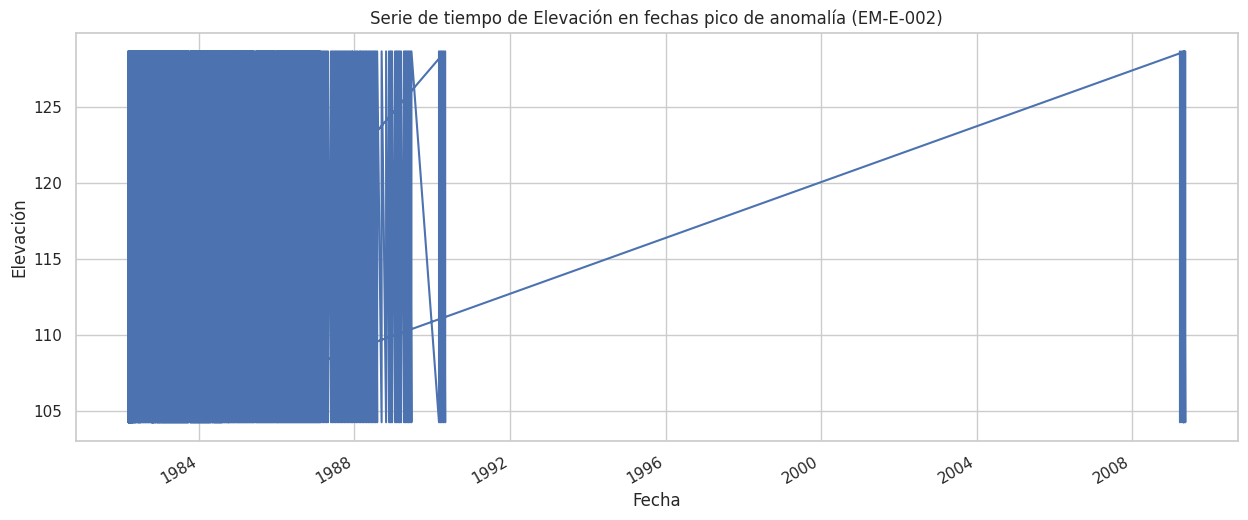

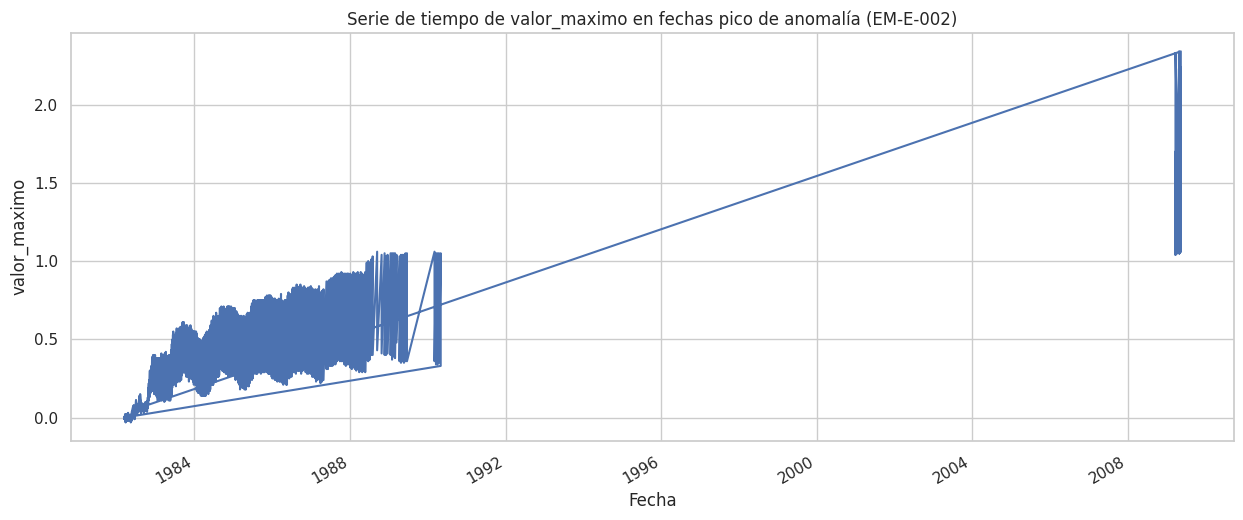

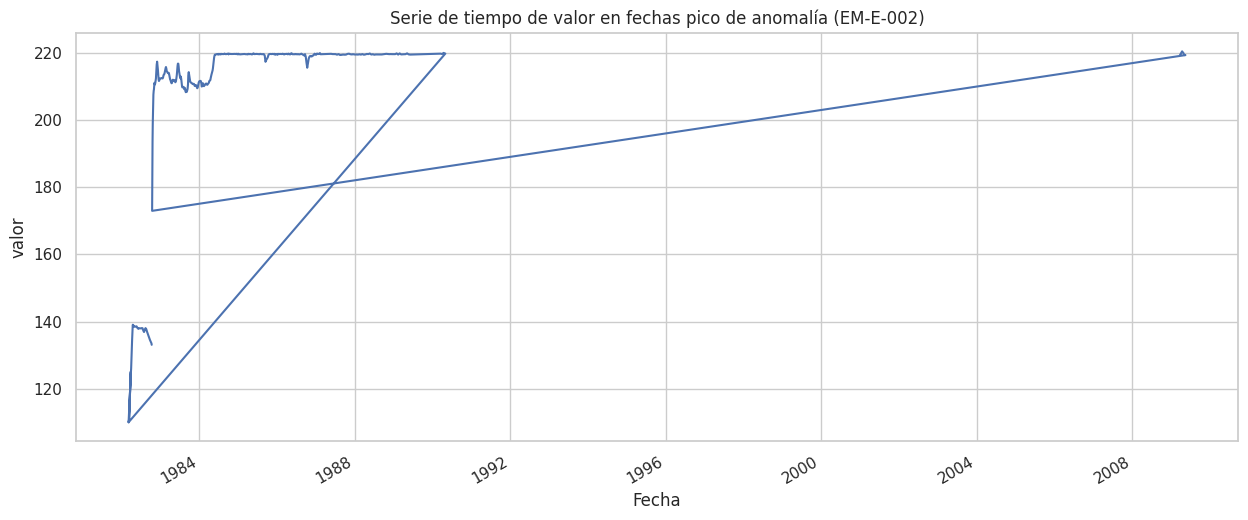

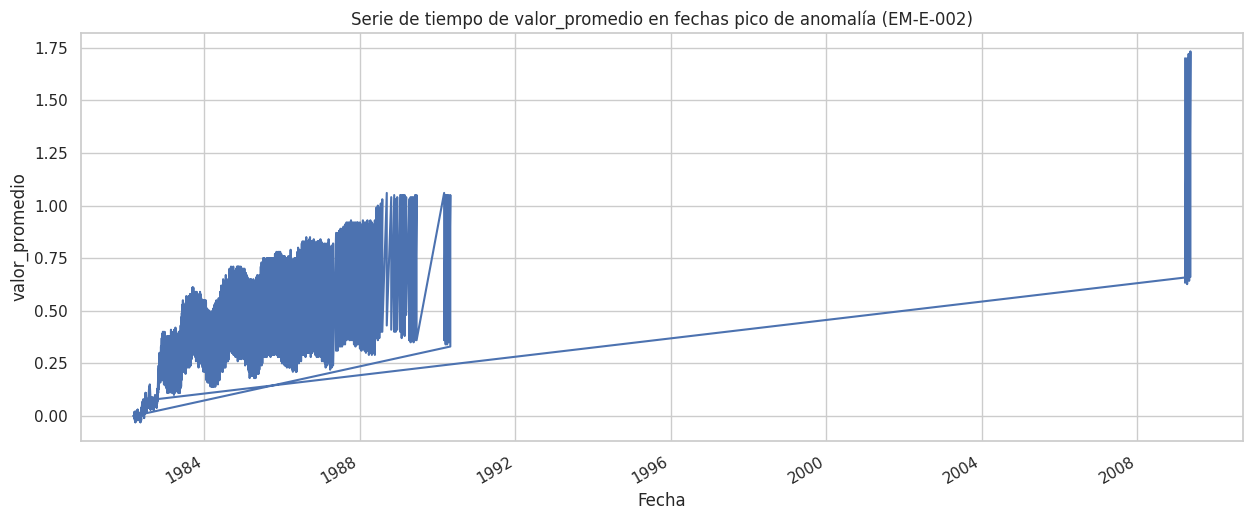

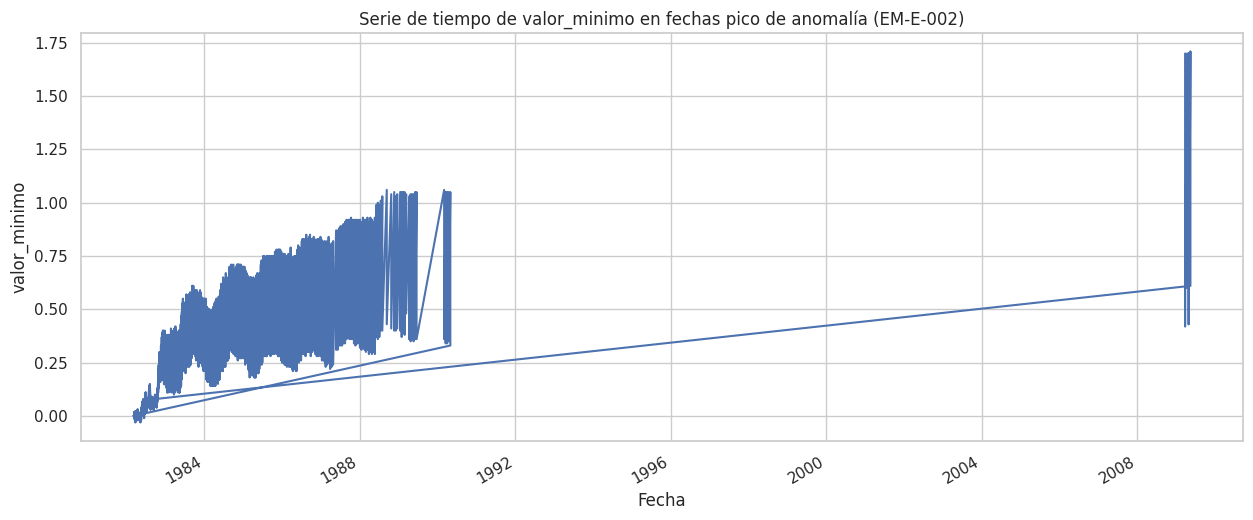


Interpretación de los gráficos de series de tiempo en fechas pico de anomalía (Grupo EM-E-002):
Estos gráficos muestran el comportamiento de características numéricas clave durante los períodos identificados con alto error de reconstrucción.
Observar los patrones en estos gráficos puede ayudar a identificar la causa de los picos de error.
Buscar cambios abruptos, valores inusuales o patrones que difieran significativamente del comportamiento normal esperado de estos sensores.
Por ejemplo, picos o caídas repentinas en 'Elevación' o 'valor' podrían indicar problemas con la medición o eventos externos.


In [24]:
# Create separate time series plots for each of the numerical columns that contributed significantly to the reconstruction error during peak anomaly dates.
# Based on the previous analysis, these are 'Elevación', 'valor_maximo', 'valor', 'valor_promedio', and 'valor_minimo'.
numerical_cols_to_plot = ['Elevación', 'valor_maximo', 'valor', 'valor_promedio', 'valor_minimo']

for col in numerical_cols_to_plot:
    plt.figure(figsize=(15, 6))
    df_peak_anomalies_eme002[col].plot()
    # Add a title to each plot indicating the sensor value and that it's for peak anomaly dates.
    plt.title(f'Serie de tiempo de {col} en fechas pico de anomalía (EM-E-002)')
    # Label the y-axis with the name of the sensor value and the x-axis as "Fecha".
    plt.ylabel(col)
    plt.xlabel("Fecha")
    plt.grid(True)
    plt.show()

# Add comments or print statements to guide the interpretation of these plots.
print("\nInterpretación de los gráficos de series de tiempo en fechas pico de anomalía (Grupo EM-E-002):")
print("Estos gráficos muestran el comportamiento de características numéricas clave durante los períodos identificados con alto error de reconstrucción.")
print("Observar los patrones en estos gráficos puede ayudar a identificar la causa de los picos de error.")
print("Buscar cambios abruptos, valores inusuales o patrones que difieran significativamente del comportamiento normal esperado de estos sensores.")
print("Por ejemplo, picos o caídas repentinas en 'Elevación' o 'valor' podrían indicar problemas con la medición o eventos externos.")

## Resumen:

### Hallazgos clave del análisis de datos

* La media del error de reconstrucción para el grupo de sensores EM-E-002 es aproximadamente 0.0488, con una desviación estándar de aproximadamente 0.1253.
* Se utilizó un umbral de 0.2995 (media + 2 * desviación estándar) para identificar los picos de error.
* Se identificaron varias fechas en las que el error de reconstrucción superó este umbral, lo que indica posibles anomalías.
* El análisis de los datos originales para estas fechas pico de anomalía reveló que la característica 'Elevación' contribuyó de manera más significativa al error de reconstrucción, seguida de 'valor\_maximo', 'valor', 'valor\_promedio' y 'valor\_minimo'.
* El examen de los datos durante las fechas pico de anomalía mostró inconsistencias en los valores reportados, particularmente en 'Elevación', y una alta prevalencia de datos ingresados manualmente (`tipo_origen_x` y `tipo_origen_y` fueron predominantemente 'MAN').

### Insights o Próximos Pasos

* Los altos errores de reconstrucción probablemente se deban a problemas de calidad de los datos, potencialmente relacionados con errores de entrada manual o lecturas inusuales en las mediciones de 'Elevación' durante los períodos pico identificados.
* Se necesita una investigación adicional sobre las fechas específicas con la mayor contribución al error para comprender el contexto de la entrada manual de datos y las inconsistencias observadas en los valores de los sensores, especialmente para 'Elevación'.

# Task
Investigar cómo el algoritmo DBSCAN puede ayudar en la Verificación Espacial de los datos de sensores, aplicando el algoritmo a los datos disponibles y analizando los resultados.

## Preparación de datos espaciales

### Subtask:
Si el DataFrame `df_sensores` contiene columnas con información espacial (coordenadas, ubicación), seleccionar y preparar estos datos para el análisis espacial. Si no hay datos espaciales explícitos pero sí información sobre la ubicación (como `local_geologico`), considerar cómo representarla numéricamente o agrupar el análisis por estas categorías.


**Reasoning**:
Inspect the `df_sensores` DataFrame to identify spatial columns and evaluate their completeness. Based on the previous analysis of `df_peak_anomalies_eme002`, the coordinate columns (`coordenada_norte`, `coordenada_este`, `zona_utm`) have many missing values. Therefore, the analysis will likely need to focus on the categorical location information (`local_geologico`).



In [29]:
# 1. Inspect the df_sensores DataFrame for spatial columns.
print("Columnas en df_sensores:")
print(df_sensores.columns)

# 2. Evaluate the completeness of potential spatial columns.
spatial_cols = ['coordenada_norte', 'coordenada_este', 'zona_utm', 'local_geologico']
print("\nConteo de valores no nulos para columnas espaciales en df_sensores:")
print(df_sensores[spatial_cols].notnull().sum())

# 3. Check unique values in 'local_geologico' to understand the categories.
print("\nValores únicos en la columna 'local_geologico':")
print(df_sensores['local_geologico'].unique())

# 4. Based on the high number of missing values in coordinate columns,
# we will proceed by grouping the analysis by 'local_geologico'.
# Get the unique values of 'local_geologico' to prepare for filtering.
unique_geolocations = df_sensores['local_geologico'].dropna().unique()
print(f"\nCategorías únicas en 'local_geologico' para agrupar el análisis: {unique_geolocations}")

# 5. (This step will be done in subsequent subtasks as we process each group)
# Filter the DataFrame for each unique 'local_geologico' value.
# Example (not executed in this block):
# for location in unique_geolocations:
#     df_location = df_sensores[df_sensores['local_geologico'] == location].copy()
#     # Perform DBSCAN analysis on df_location

Columnas en df_sensores:
Index(['descripcion_presa_x', 'nombre_etiqueta', 'tipo_etiqueta_x',
       'valor_promedio', 'valor_minimo', 'valor_maximo', 'observacion',
       'tipo_origen_x', 'sigla_unidad_medida_x', 'tipo_presa',
       'tipo_etiqueta_y', 'sigla_presa', 'descripcion_presa_y',
       'sigla_estructura', 'etiqueta_padre', 'referencia', 'orientacion',
       'sigla_unidad_medida_y', 'descripcion_unidad_medida',
       'variable_ingenieria', 'tipo_origen_y', 'local_geologico', 'estado',
       'coordenada_norte', 'coordenada_este', 'zona_utm',
       'familia_tipo_instrumento', 'Elevación',
       'nombre_etiqueta_hidrometeorologica', 'valor'],
      dtype='object')

Conteo de valores no nulos para columnas espaciales en df_sensores:
coordenada_norte    26092
coordenada_este     26092
zona_utm            26151
local_geologico     75566
dtype: int64

Valores únicos en la columna 'local_geologico':
['CONTATO D/E' 'ROCHA FRATURADA' 'JUNTA D' 'CONTATO C/D' 'SIN ASIGNAR'
 'CONTAT

## Selección de características para DBSCAN

### Subtask:
Decidir qué características de los datos de los sensores (además o en lugar de la ubicación espacial) se utilizarán para el clustering con DBSCAN (por ejemplo, `valor_promedio`, error de reconstrucción de PCA).

# Task
Aplicar DBSCAN por grupo geológico, analizar y visualizar los resultados, y consolidar los hallazgos para la verificación espacial.

## Aplicar dbscan por grupo geológico

### Subtask:
Iterar sobre cada valor único en la columna `local_geologico`, filtrar el DataFrame `df_sensores` para cada grupo geológico, seleccionar y escalar las características relevantes para el clustering, aplicar el algoritmo DBSCAN ajustando los parámetros `eps` y `min_samples`, y almacenar los resultados del clustering para cada grupo.


**Reasoning**:
Iterate through each geological location, filter data, select and scale features, apply DBSCAN, and store the results.



In [30]:
from sklearn.cluster import DBSCAN

# List to store results for each location
dbscan_results_by_location = {}

# Select relevant features for DBSCAN.
# Based on previous analysis and common sense for sensor data.
# We will use 'valor_promedio', 'valor_minimo', 'valor_maximo', 'Elevación', and 'valor'.
# We will NOT include reconstruction error here as it was calculated for a specific group (EM-E-002)
# and merging it for all sensor types might not be straightforward or meaningful
# without further investigation.
features_for_dbscan = ['valor_promedio', 'valor_minimo', 'valor_maximo', 'Elevación', 'valor']

# Iterate through each unique geological location
for location in unique_geolocations:
    print(f"Processing location: {location}")

    # Filter the DataFrame for the current location
    df_location = df_sensores[df_sensores['local_geologico'] == location].copy()

    # Handle missing values for selected features
    df_location_cleaned = df_location.dropna(subset=features_for_dbscan)

    # Check if there's enough data points after dropping NaNs for clustering
    if len(df_location_cleaned) < 5: # DBSCAN requires at least min_samples data points
        print(f"Not enough data points for DBSCAN in location {location}. Skipping.")
        continue

    # Select and scale the features
    scaled_data_location = StandardScaler().fit_transform(df_location_cleaned[features_for_dbscan])

    # Apply DBSCAN. These parameters might need tuning based on the data distribution
    # and the definition of a spatial anomaly.
    dbscan = DBSCAN(eps=0.5, min_samples=5) # Initial parameters
    dbscan_labels_location = dbscan.fit_predict(scaled_data_location)

    # Add cluster labels to the cleaned DataFrame
    df_location_cleaned['dbscan_label'] = dbscan_labels_location

    # Store the results
    dbscan_results_by_location[location] = df_location_cleaned

print("\nDBSCAN analysis completed for all geographical locations.")
# Display the first few rows of results for one location as an example
if dbscan_results_by_location:
    first_location = list(dbscan_results_by_location.keys())[0]
    print(f"\nSample results for location '{first_location}':")
    display(dbscan_results_by_location[first_location].head())
else:
    print("\nNo locations had enough data points for DBSCAN.")


Processing location: CONTATO D/E


/tmp/ipython-input-2373315721.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_location_cleaned['dbscan_label'] = dbscan_labels_location


Processing location: ROCHA FRATURADA


/tmp/ipython-input-2373315721.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_location_cleaned['dbscan_label'] = dbscan_labels_location


Processing location: JUNTA D


...

Processing location: CONTATO CONCRETO/ROCHA
Processing location: BRECHA D


/tmp/ipython-input-2373315721.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_location_cleaned['dbscan_label'] = dbscan_labels_location
/tmp/ipython-input-2373315721.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_location_cleaned['dbscan_label'] = dbscan_labels_location


Processing location: BRECHA C
Processing location: DERRAME D

DBSCAN analysis completed for all geographical locations.

Sample results for location 'CONTATO D/E':


/tmp/ipython-input-2373315721.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_location_cleaned['dbscan_label'] = dbscan_labels_location


,descripcion_presa_x,nombre_etiqueta,tipo_etiqueta_x,valor_promedio,valor_minimo,valor_maximo,observacion,tipo_origen_x,sigla_unidad_medida_x,tipo_presa,...,local_geologico,estado,coordenada_norte,coordenada_este,zona_utm,familia_tipo_instrumento,Elevación,nombre_etiqueta_hidrometeorologica,valor,dbscan_label
fecha,,,,,,,,,,,,,,,,,,,,,
2005-10-27,Trecho E: Barragem de ligação direita,EM-E-001/1 | (2736) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,6.229500,6.22,6.23,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,132.12,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.26,0
2005-10-28,Trecho E: Barragem de ligação direita,EM-E-001/1 | (2736) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,6.241667,6.23,6.25,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,132.12,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.29,0
2005-10-29,Trecho E: Barragem de ligação direita,EM-E-001/1 | (2736) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,6.249583,6.23,6.26,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,132.12,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.36,0
2005-10-30,Trecho E: Barragem de ligação direita,EM-E-001/1 | (2736) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,6.258750,6.24,6.28,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,132.12,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.38,0
2005-10-31,Trecho E: Barragem de ligação direita,EM-E-001/1 | (2736) - (DEFORMACION),EXTENSOMETRO MULTIPLO DE HASTE,6.269167,6.25,6.29,NaN,AUT,mm,Hormigón,...,CONTATO D/E,Operante,NaN,NaN,NaN,EXTENSÓMETRO DE MÚLTIPLE DE BARRA,132.12,CCR_IDB .DESCARGA TOTAL-IPU .AV,220.31,0


**Reasoning**:
The DBSCAN clustering has been applied to each geological location group. The next step is to analyze and interpret the clustering results for each group, focusing on the identified clusters and noise points (-1 label).



In [31]:
# 1. Iterate through the results stored in dbscan_results_by_location.
print("\nAnálisis de los resultados de DBSCAN por grupo geológico:")

for location, df_result in dbscan_results_by_location.items():
    print(f"\n--- Grupo Geológico: {location} ---")

    # 2. For each group, analyze the distribution of cluster labels.
    # Count the number of data points in each cluster, including noise (-1).
    print(f"\nDistribución de etiquetas de clúster para '{location}':")
    display(df_result['dbscan_label'].value_counts())

    # 3. Identify the noise points (data points with label -1).
    noise_points = df_result[df_result['dbscan_label'] == -1]
    print(f"\nPuntos de ruido (posibles anomalías espaciales) en '{location}':")
    print(f"Número de puntos de ruido: {len(noise_points)}")

    # 4. Examine the characteristics of the noise points (e.g., their sensor values).
    if not noise_points.empty:
        print(f"\nEstadísticas descriptivas de los puntos de ruido en '{location}':")
        display(noise_points[features_for_dbscan].describe())

        # Optionally, display some of the noise points
        print(f"\nEjemplos de puntos de ruido en '{location}':")
        display(noise_points.head())

    # 5. Analyze the characteristics of the identified clusters (e.g., mean sensor values for each cluster).
    # Exclude noise points (-1) from cluster analysis.
    clusters = df_result[df_result['dbscan_label'] != -1]
    if not clusters.empty:
        print(f"\nEstadísticas descriptivas por clúster (excluyendo ruido) en '{location}':")
        display(clusters.groupby('dbscan_label')[features_for_dbscan].mean())

    # 6. Consider visualizing the clustering results if the dimensionality is low or using dimensionality reduction techniques.
    # For 5 features, direct 2D/3D plotting is not ideal. We'll skip direct visualization here
    # and rely on the statistical analysis of clusters and noise.

    # 7. Add comments or print statements to interpret the results for each group.
    print(f"\nInterpretación para '{location}':")
    if len(noise_points) > 0:
        print(f"Se identificaron {len(noise_points)} puntos de ruido (etiqueta -1), que pueden ser considerados anomalías espaciales para este grupo.")
        print("Estos puntos de ruido son datos que DBSCAN considera que no pertenecen a ningún clúster denso.")
    else:
        print("No se identificaron puntos de ruido (etiqueta -1) en este grupo. Todos los puntos fueron asignados a clústeres o considerados puntos centrales/frontera.")
    print("Los clústeres identificados representan grupos de puntos de datos con características de sensor similares dentro de esta ubicación geológica.")
    print("La comparación de las estadísticas de los puntos de ruido con las estadísticas de los clústeres puede ayudar a entender por qué son considerados anomalías.")


Análisis de los resultados de DBSCAN por grupo geológico:

--- Grupo Geológico: CONTATO D/E ---

Distribución de etiquetas de clúster para 'CONTATO D/E':


,count
dbscan_label,
1,8984
0,4496
6,835
4,112
3,66
5,57
-1,23
2,7



Puntos de ruido (posibles anomalías espaciales) en 'CONTATO D/E':
Número de puntos de ruido: 23

Estadísticas descriptivas de los puntos de ruido en 'CONTATO D/E':


,valor_promedio,valor_minimo,valor_maximo,Elevación,valor
count,23.000000,23.000000,23.000000,23.000000,23.000000
mean,-0.026957,-0.026957,-0.026957,130.091739,165.366957
std,0.189003,0.189003,0.189003,1.559941,43.902634
min,-0.290000,-0.290000,-0.290000,128.690000,59.170000
25%,-0.120000,-0.120000,-0.120000,128.690000,153.100000
50%,-0.100000,-0.100000,-0.100000,129.650000,185.990000
75%,0.105000,0.105000,0.105000,132.120000,193.640000
max,0.500000,0.500000,0.500000,132.120000,198.820000



Ejemplos de puntos de ruido en 'CONTATO D/E':


...


Interpretación para 'BRECHA C':
No se identificaron puntos de ruido (etiqueta -1) en este grupo. Todos los puntos fueron asignados a clústeres o considerados puntos centrales/frontera.
Los clústeres identificados representan grupos de puntos de datos con características de sensor similares dentro de esta ubicación geológica.
La comparación de las estadísticas de los puntos de ruido con las estadísticas de los clústeres puede ayudar a entender por qué son considerados anomalías.

--- Grupo Geológico: DERRAME D ---

Distribución de etiquetas de clúster para 'DERRAME D':


,count
dbscan_label,
1,1256
3,1256
0,113
2,113



Puntos de ruido (posibles anomalías espaciales) en 'DERRAME D':
Número de puntos de ruido: 0

Estadísticas descriptivas por clúster (excluyendo ruido) en 'DERRAME D':


,valor_promedio,valor_minimo,valor_maximo,Elevación,valor
dbscan_label,,,,,
0,134.282202,134.282202,134.282202,130.8,116.244602
1,160.883965,160.883567,160.884363,130.8,218.097102
2,3.482202,3.482202,3.482202,130.8,116.244602
3,30.083965,30.083567,30.084363,130.8,218.097102



Interpretación para 'DERRAME D':
No se identificaron puntos de ruido (etiqueta -1) en este grupo. Todos los puntos fueron asignados a clústeres o considerados puntos centrales/frontera.
Los clústeres identificados representan grupos de puntos de datos con características de sensor similares dentro de esta ubicación geológica.
La comparación de las estadísticas de los puntos de ruido con las estadísticas de los clústeres puede ayudar a entender por qué son considerados anomalías.


## Visualizar los resultados de dbscan por grupo

### Subtask:
Para cada grupo geológico, visualizar los resultados del clustering. Esto podría implicar gráficos de dispersión de las características utilizadas para el clustering, coloreando los puntos según su etiqueta de cluster.


**Reasoning**:
Iterate through the `dbscan_results_by_location` dictionary, prepare the data for visualization, select the features used for DBSCAN, create scatter plots for pairs of selected features, color points by cluster label, add titles and labels, and display the plots.




--- Visualización de Clustering DBSCAN para: CONTATO D/E ---


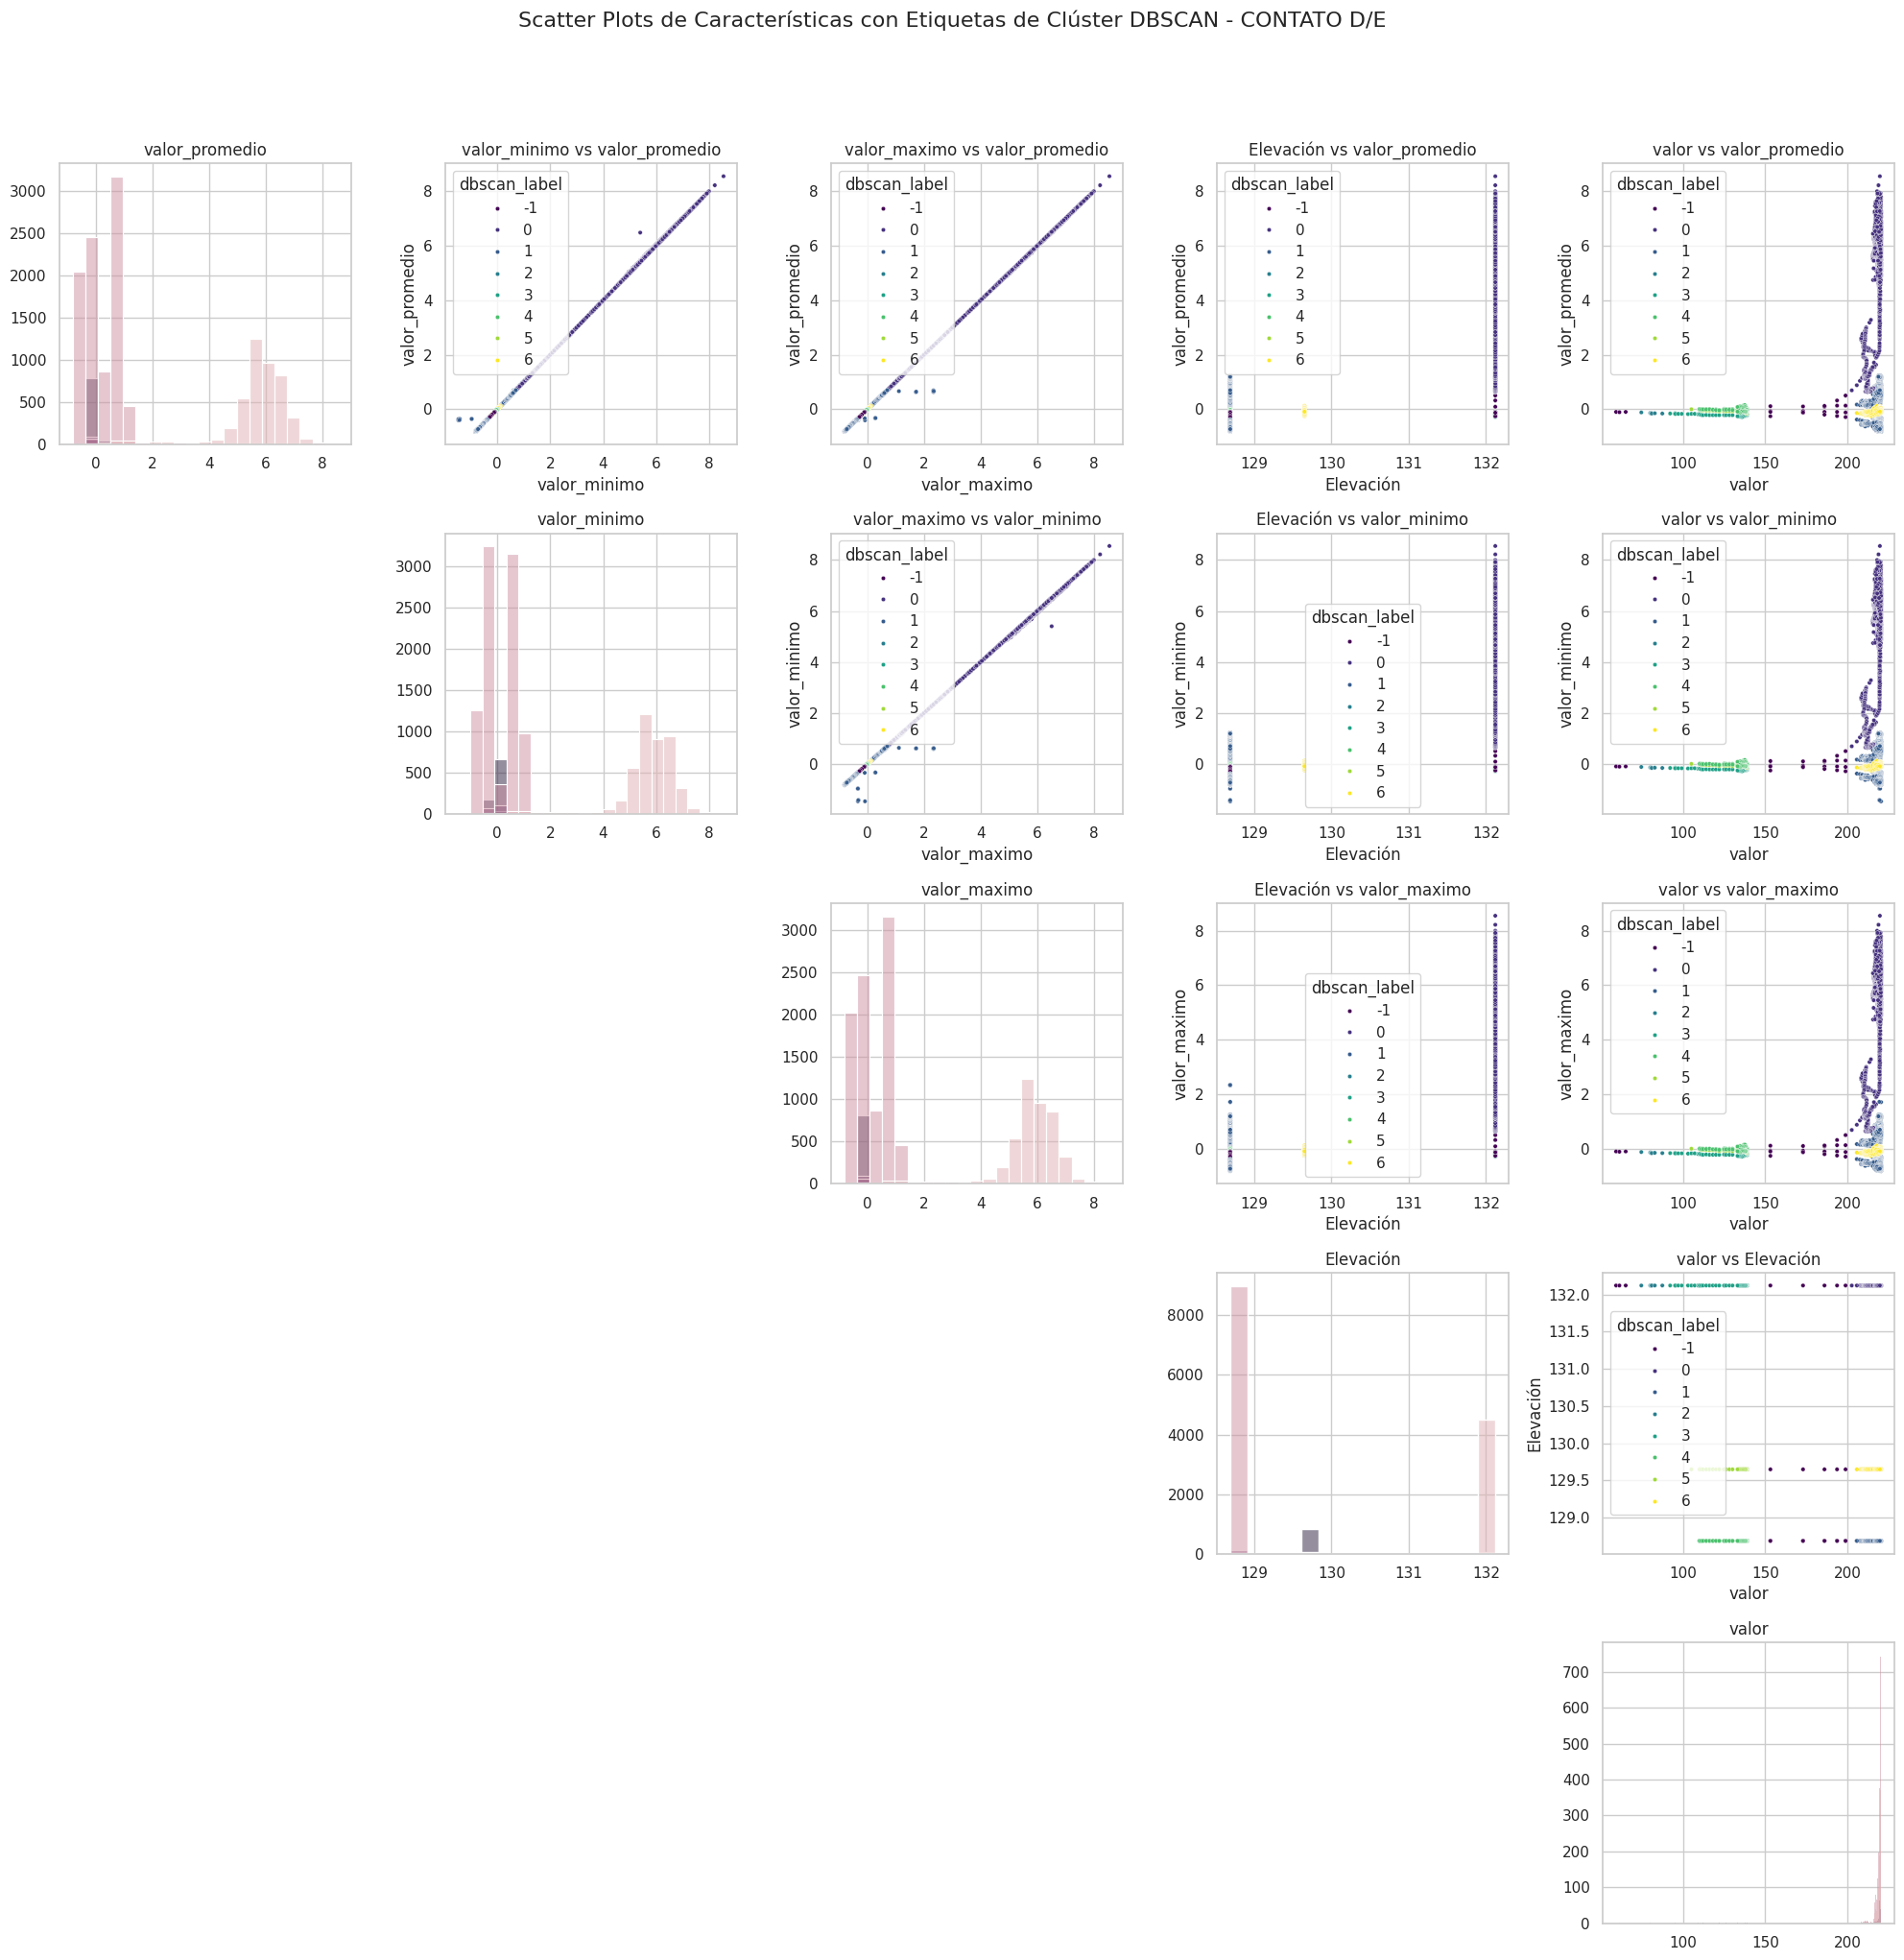


Interpretación de los gráficos de dispersión para 'CONTATO D/E':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.

--- Visualización de Clustering DBSCAN para: ROCHA FRATURADA ---


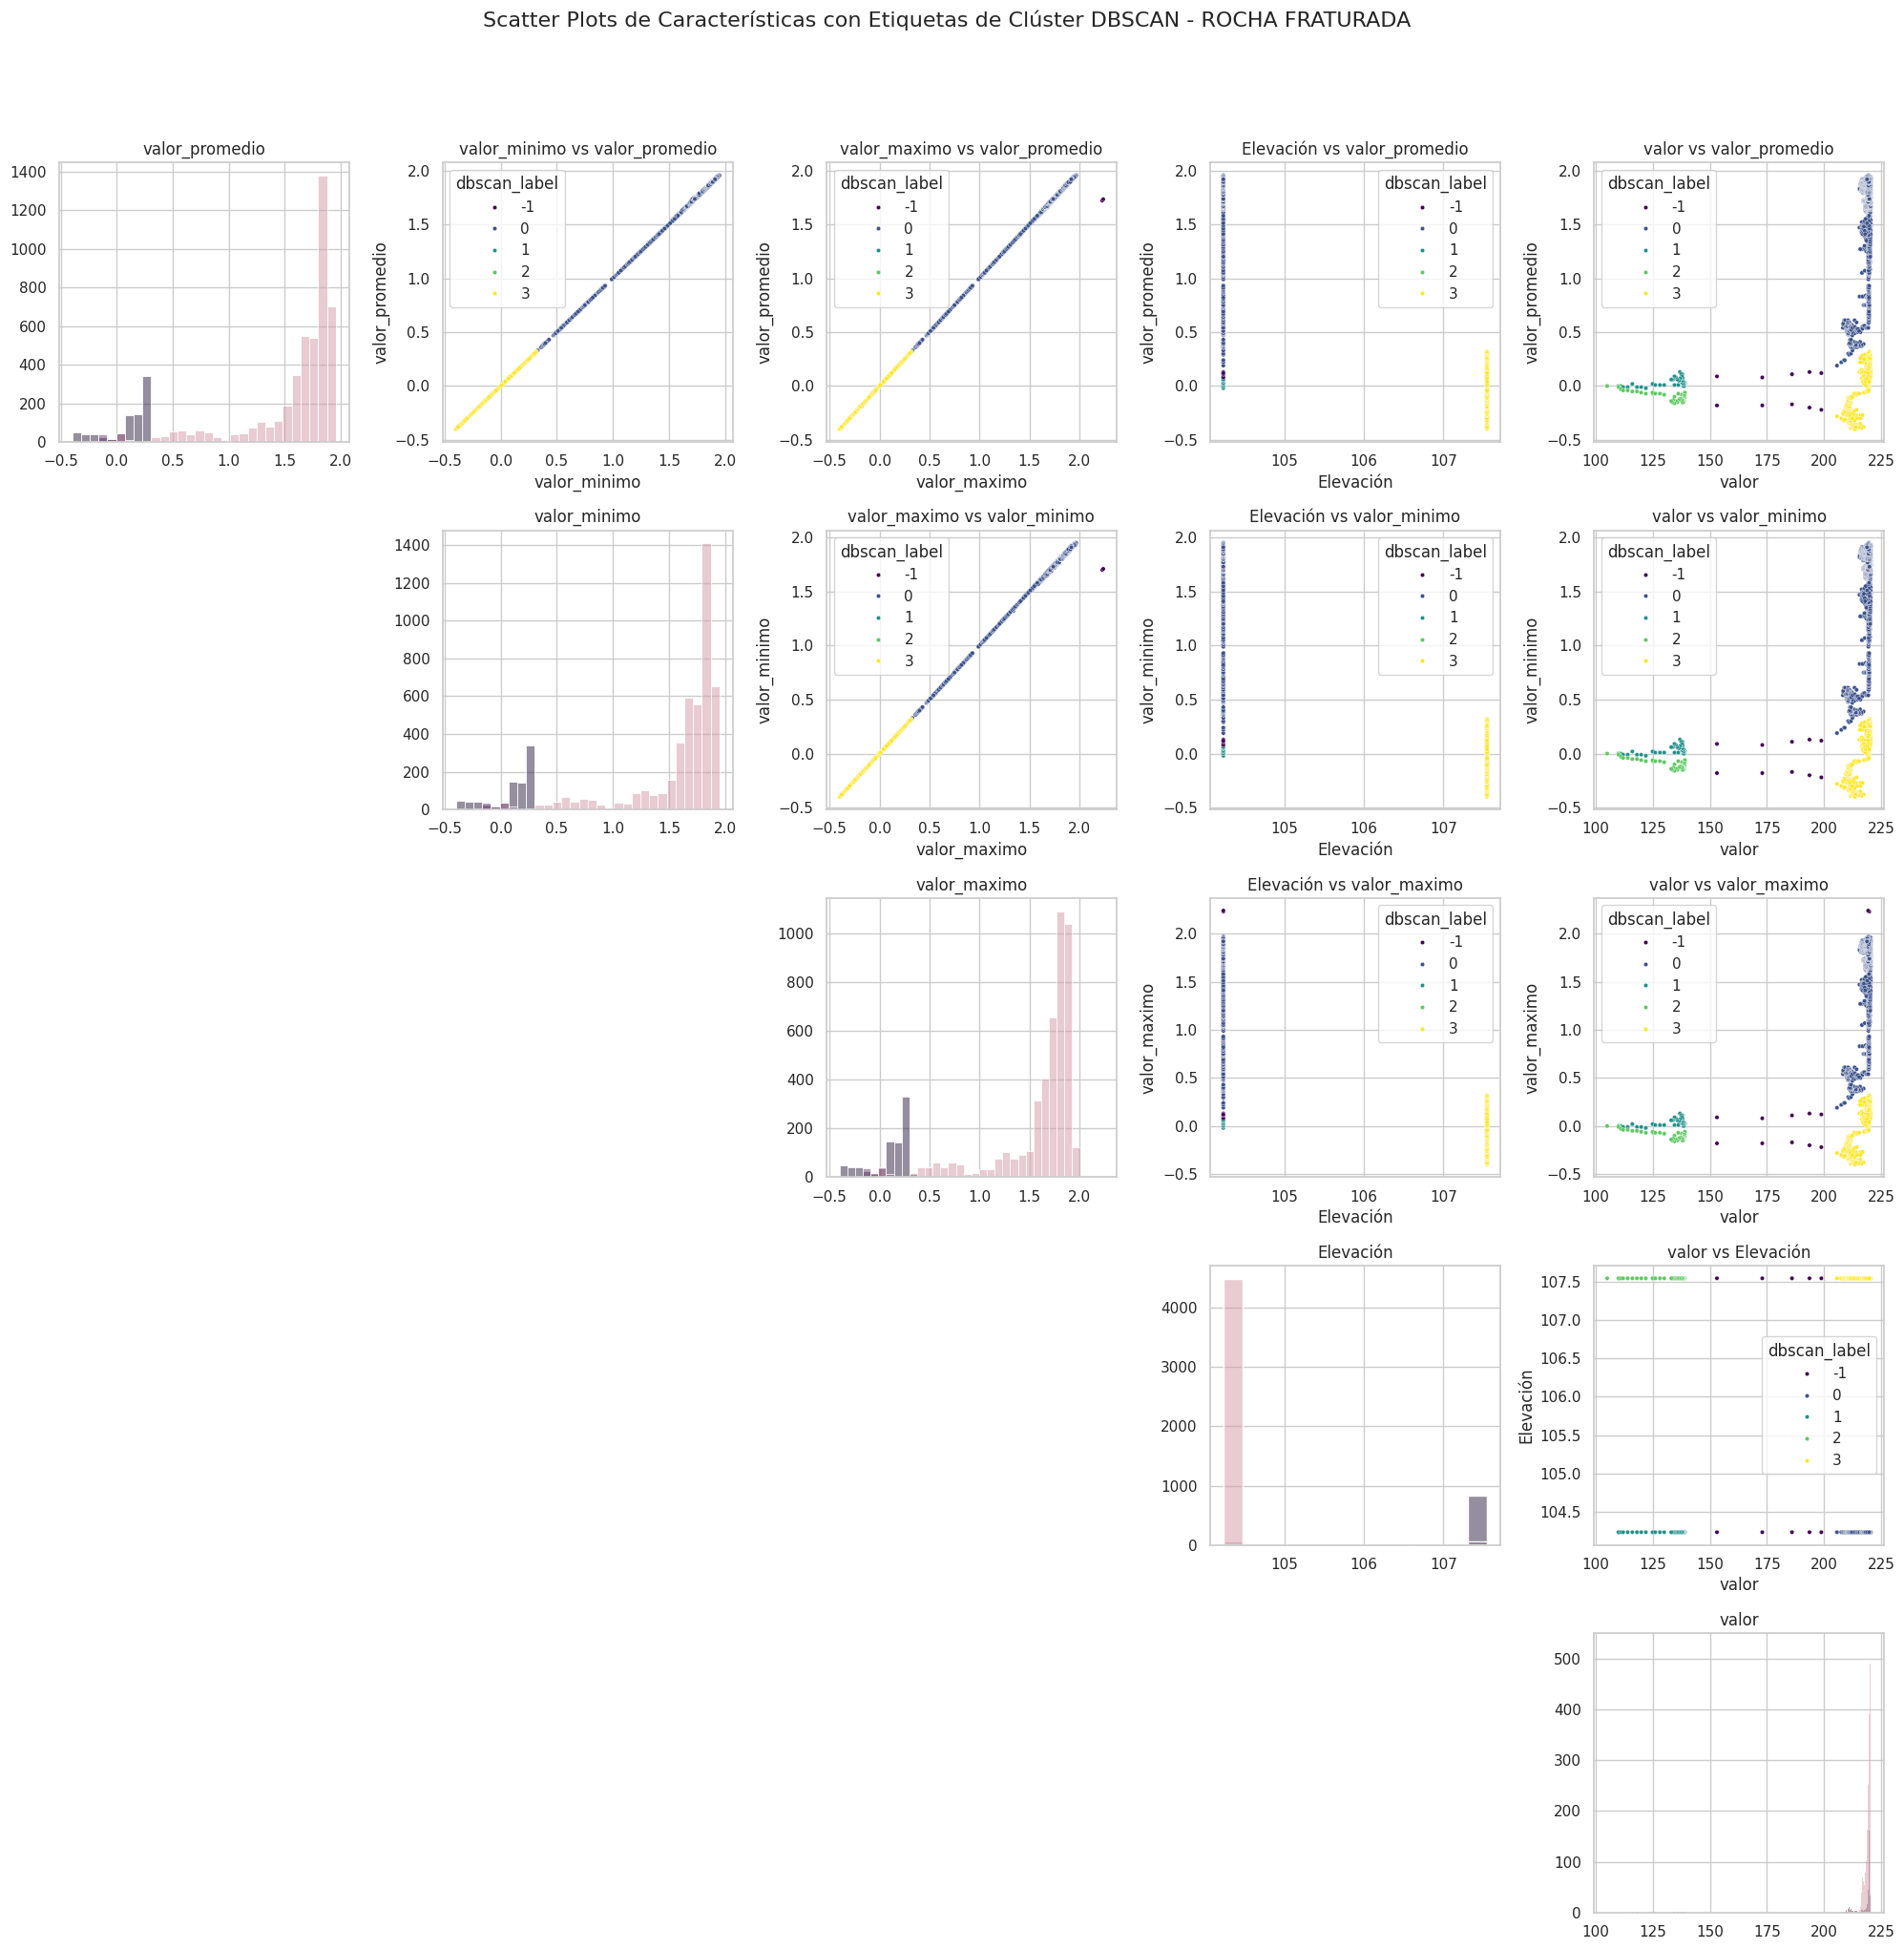


Interpretación de los gráficos de dispersión para 'ROCHA FRATURADA':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.

--- Visualización de Clustering DBSCAN para: JUNTA D ---


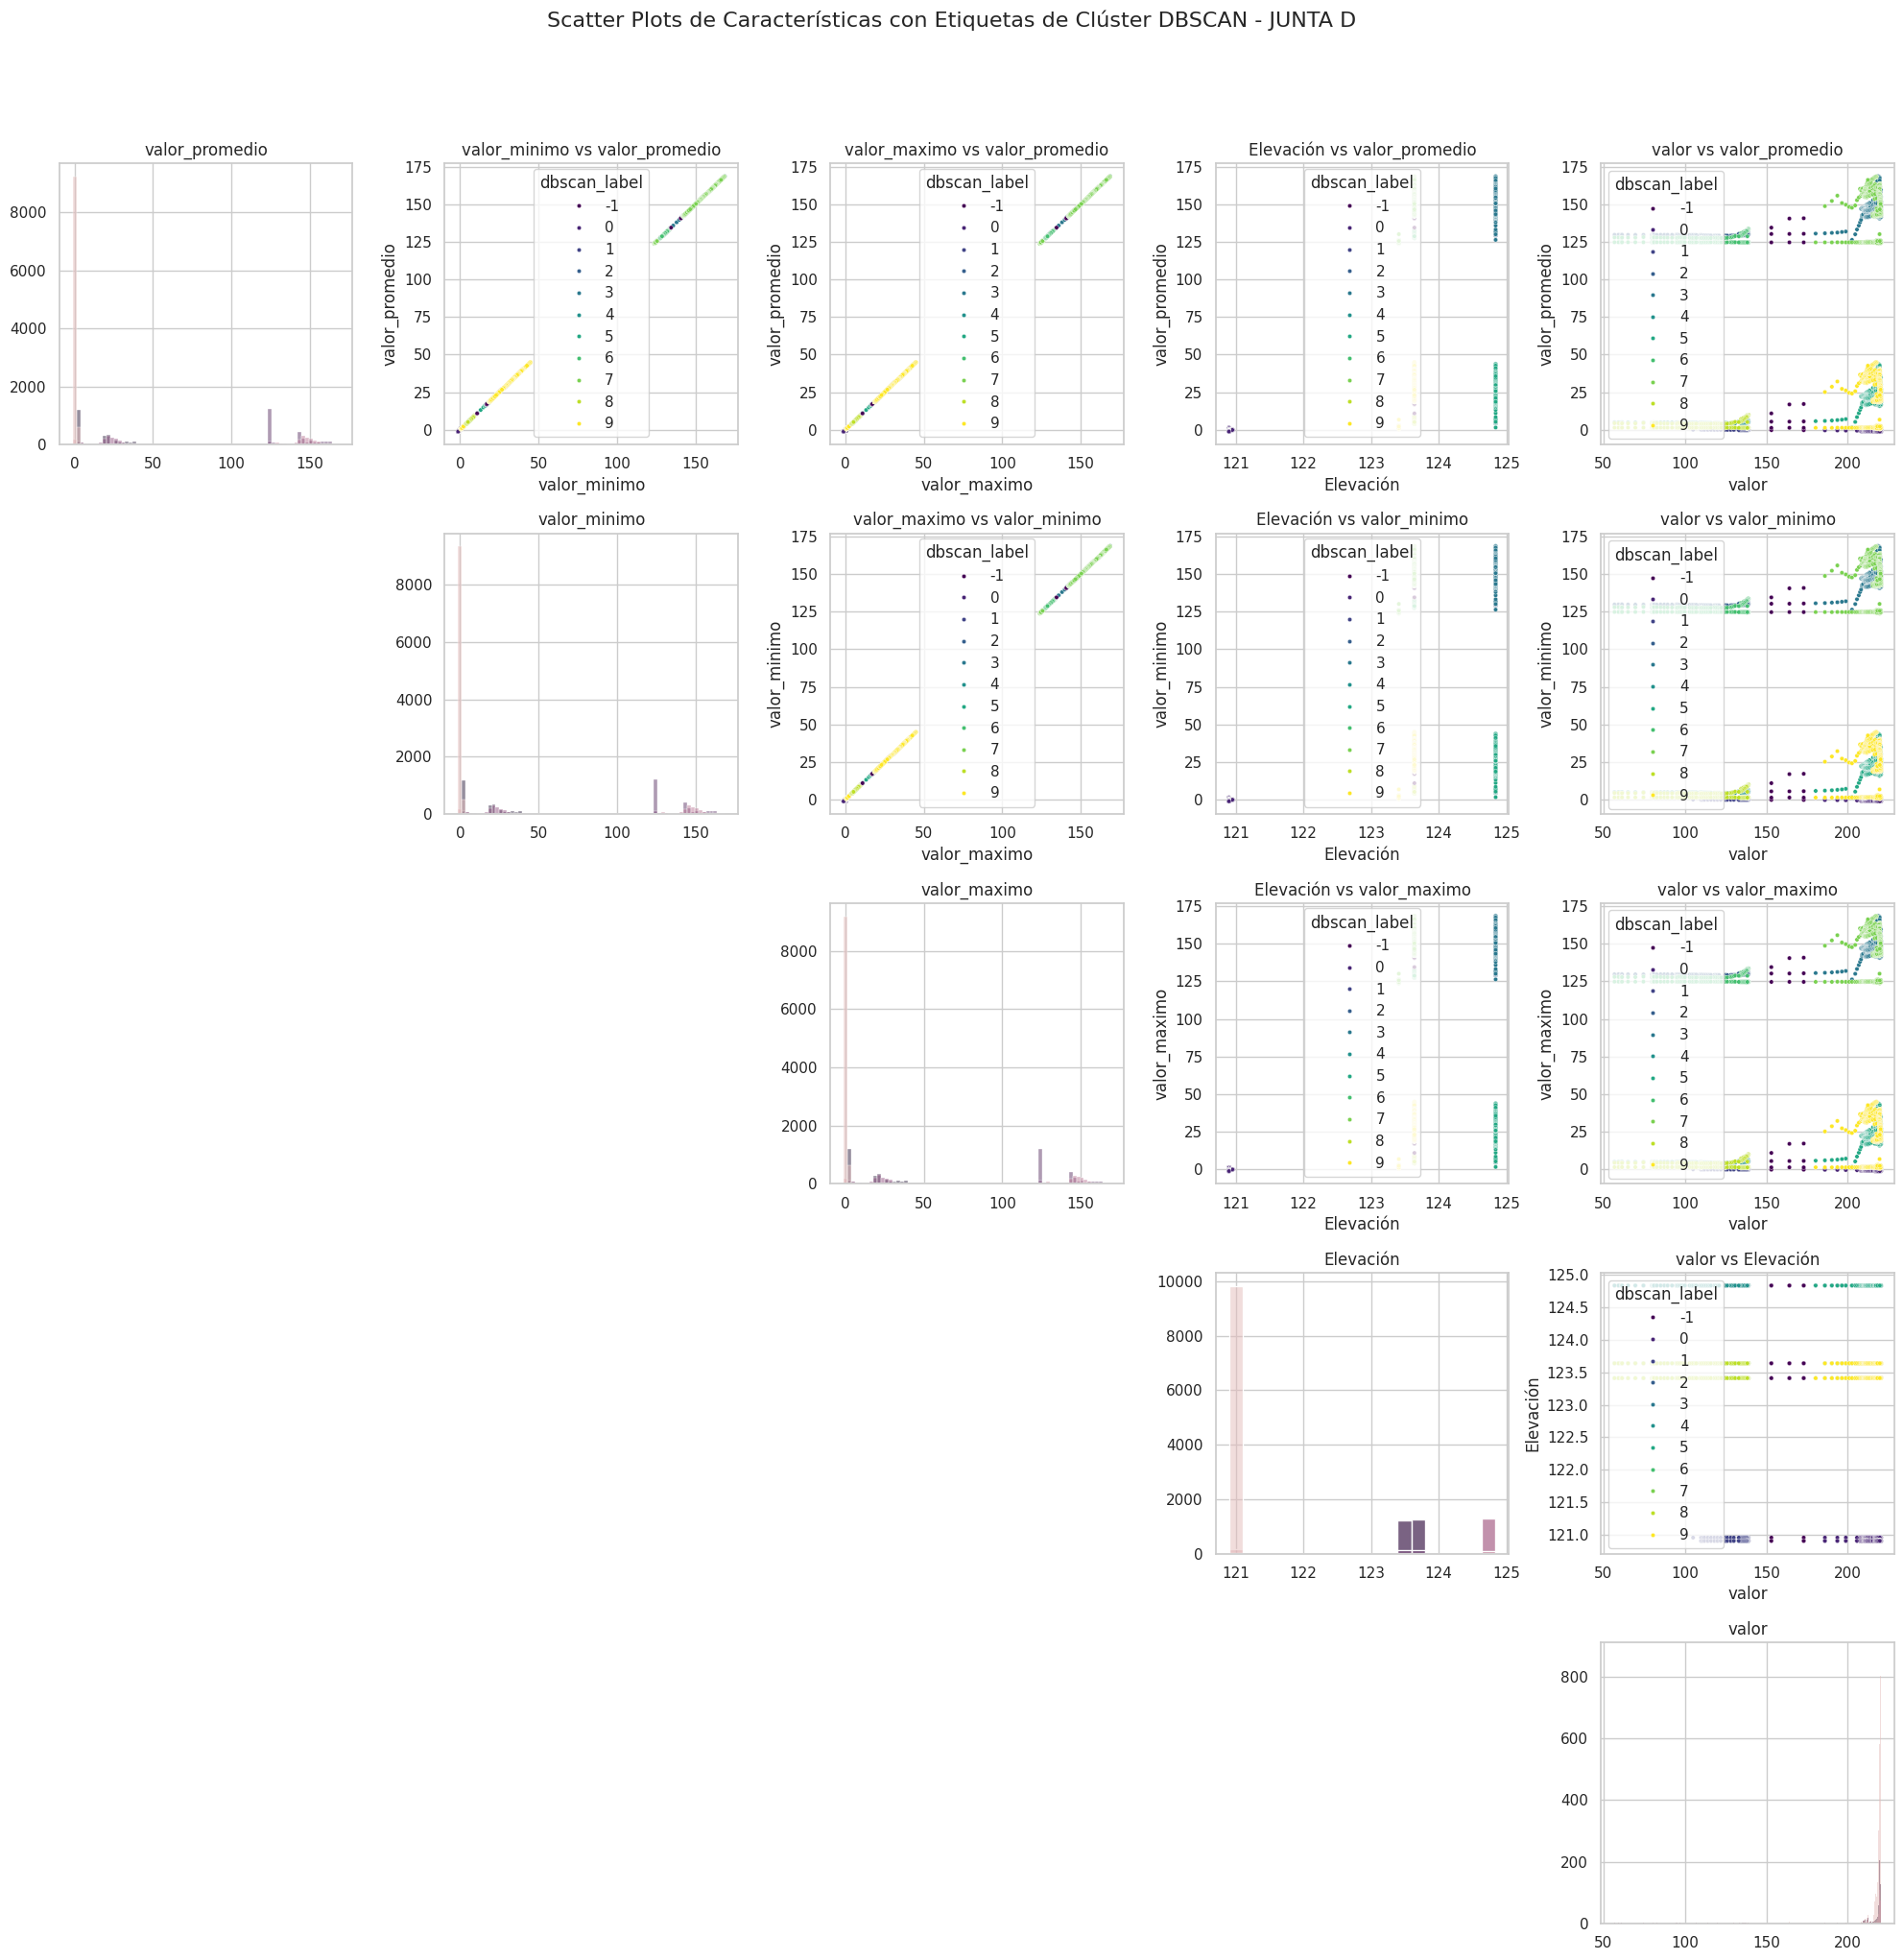


Interpretación de los gráficos de dispersión para 'JUNTA D':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.

--- Visualización de Clustering DBSCAN para: CONTATO C/D ---


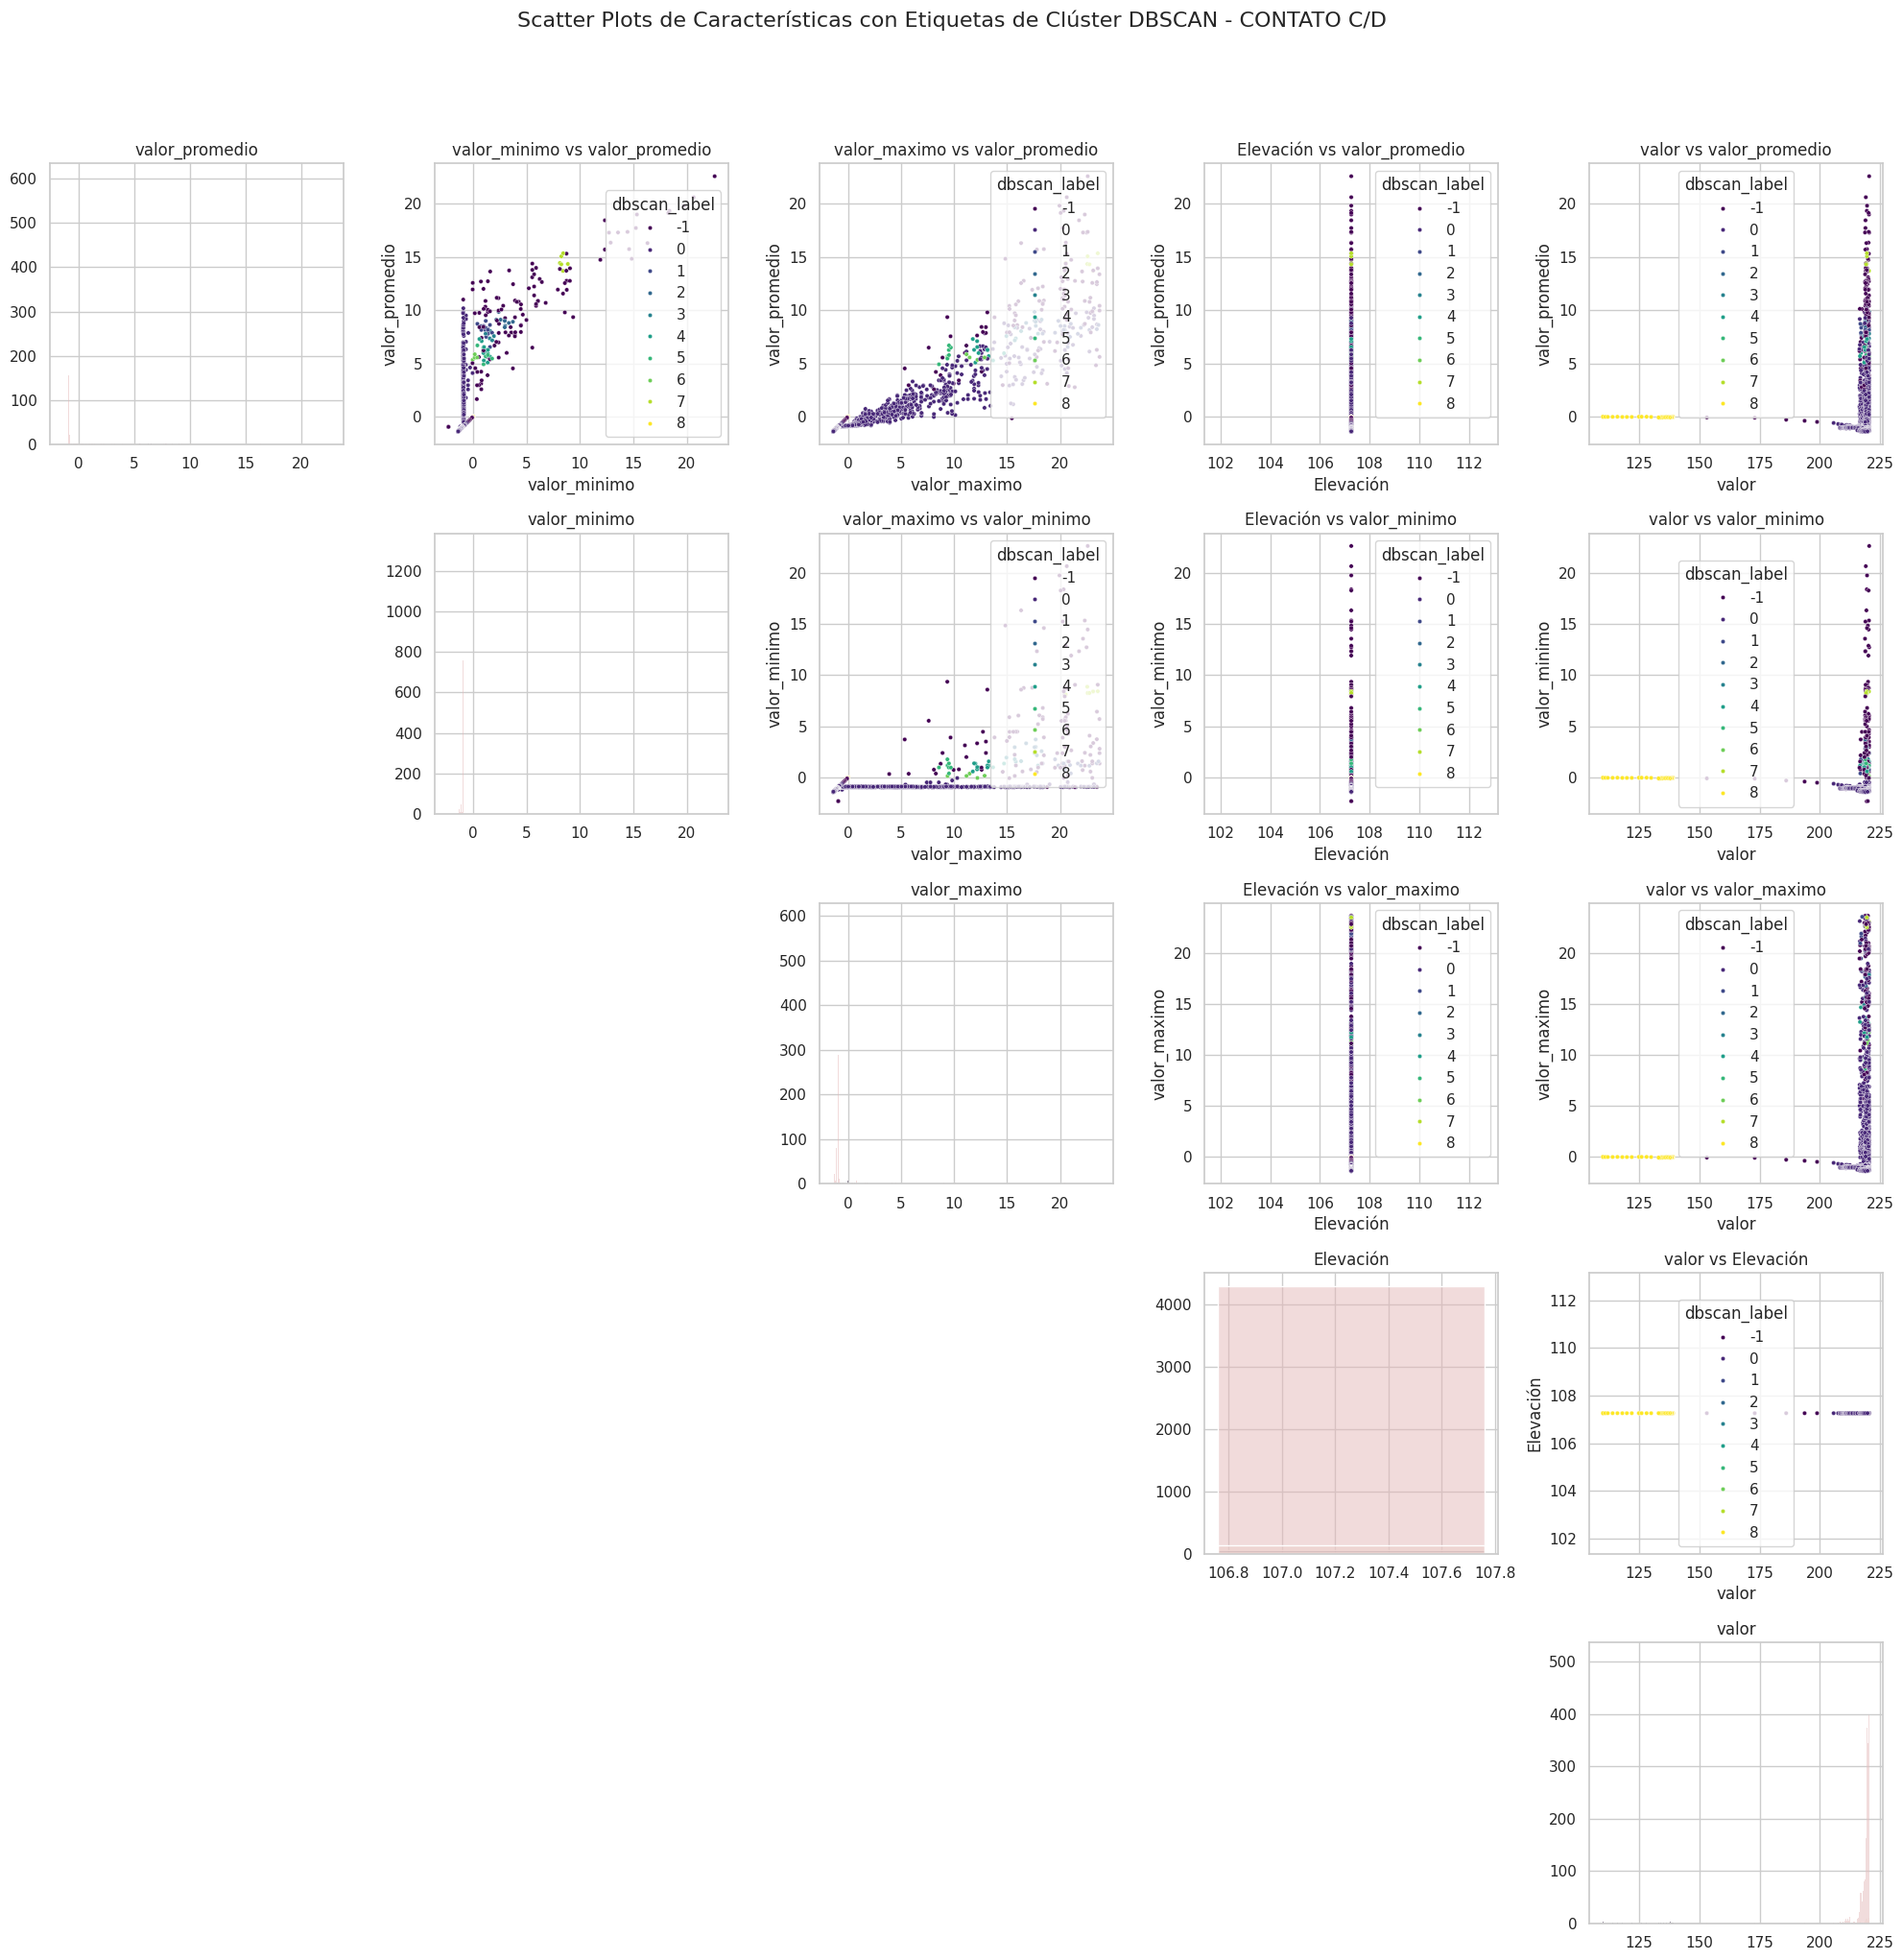


Interpretación de los gráficos de dispersión para 'CONTATO C/D':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.

--- Visualización de Clustering DBSCAN para: SIN ASIGNAR ---


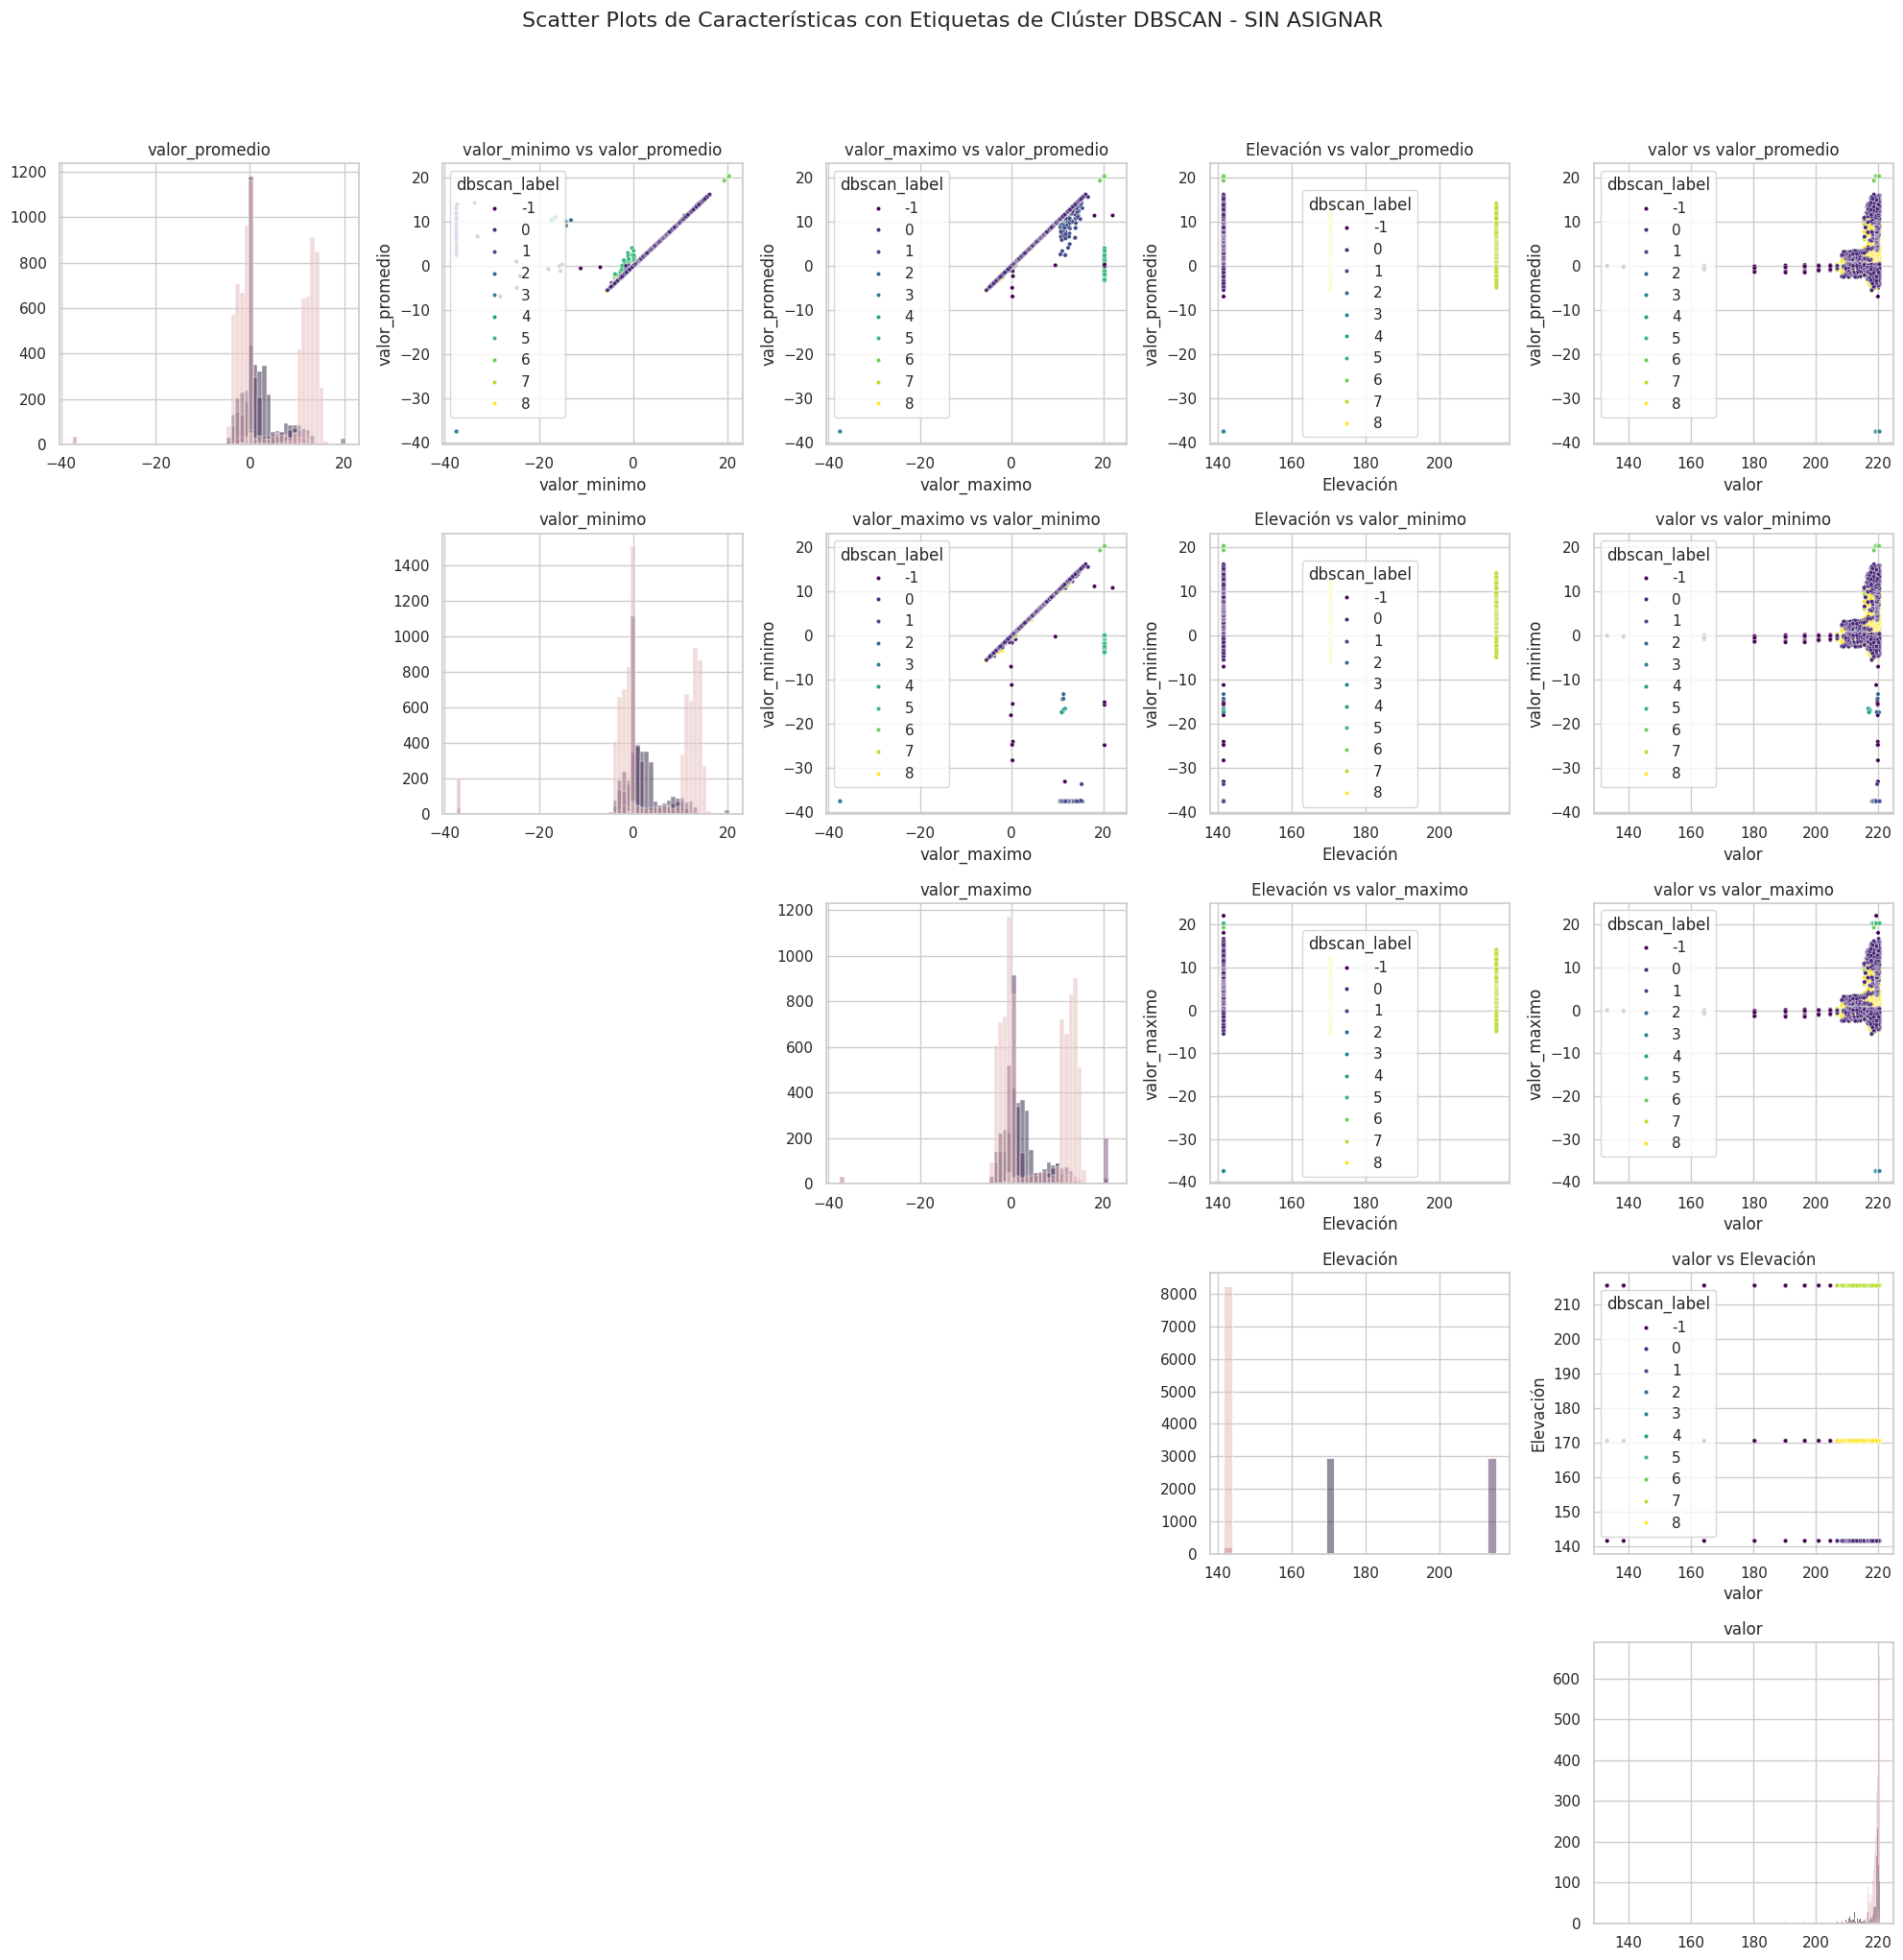


Interpretación de los gráficos de dispersión para 'SIN ASIGNAR':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.

--- Visualización de Clustering DBSCAN para: CONTATO CONCRETO/ROCHA ---


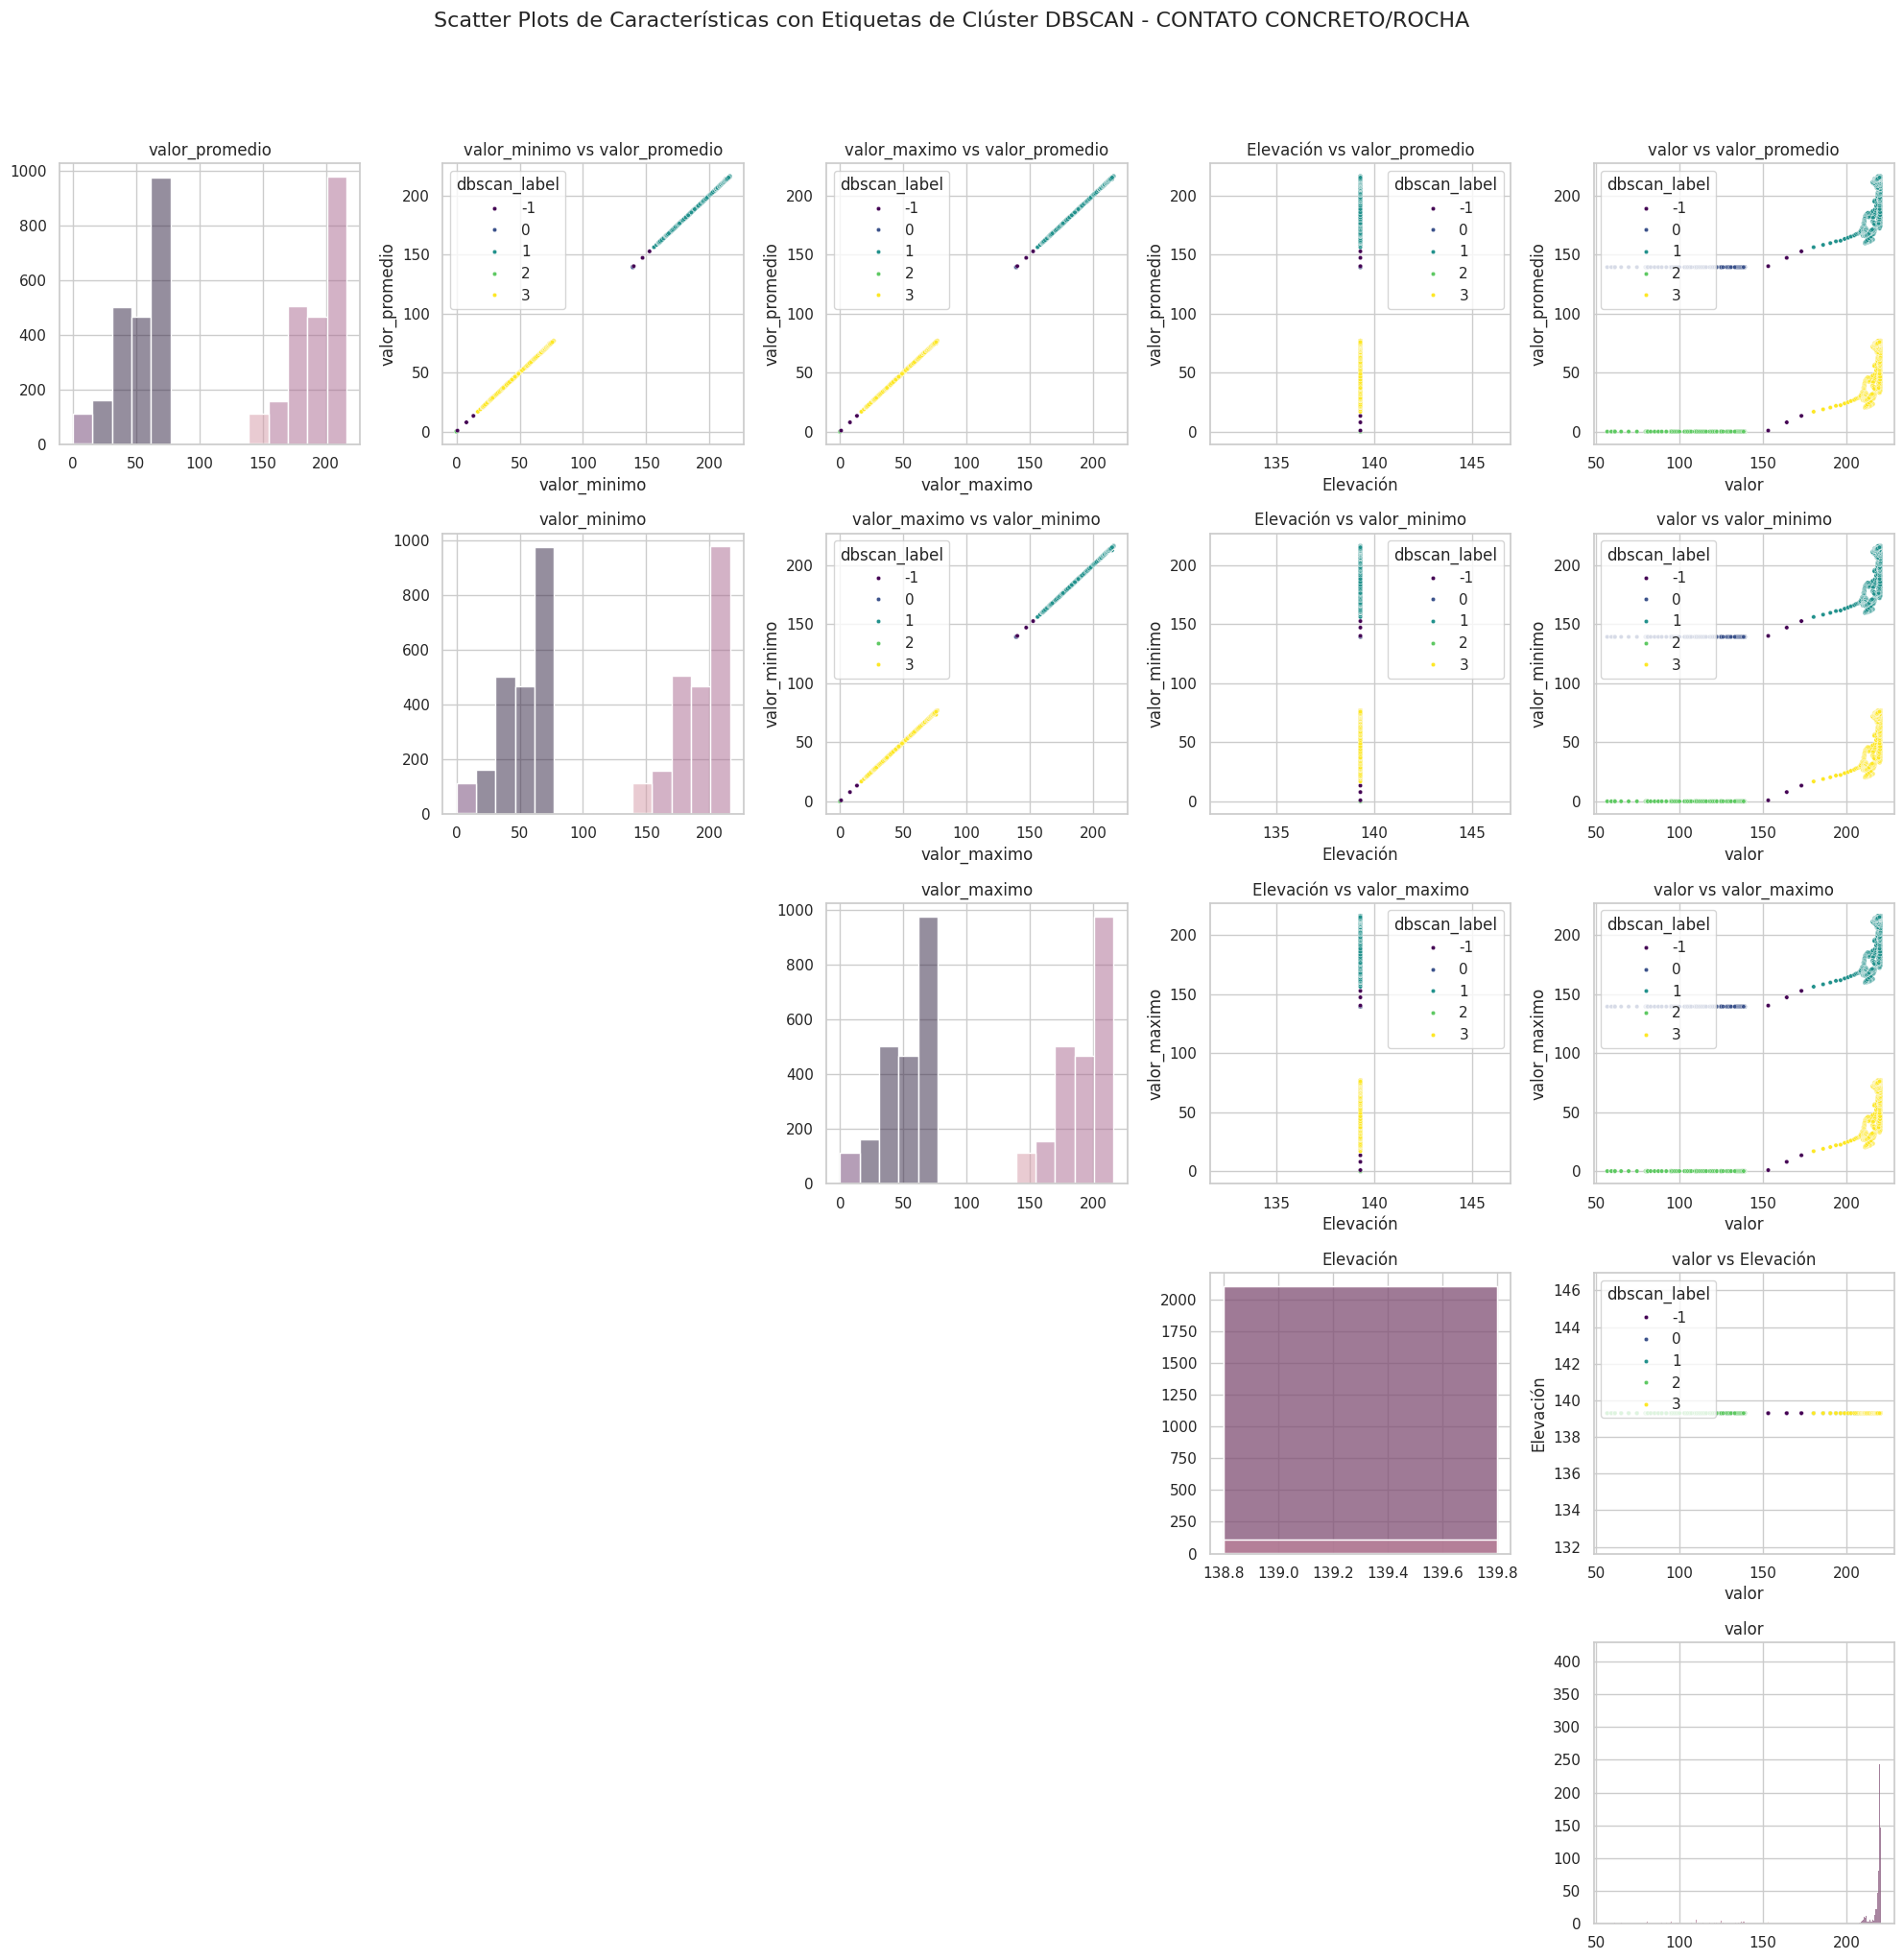


Interpretación de los gráficos de dispersión para 'CONTATO CONCRETO/ROCHA':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.

--- Visualización de Clustering DBSCAN para: BRECHA D ---


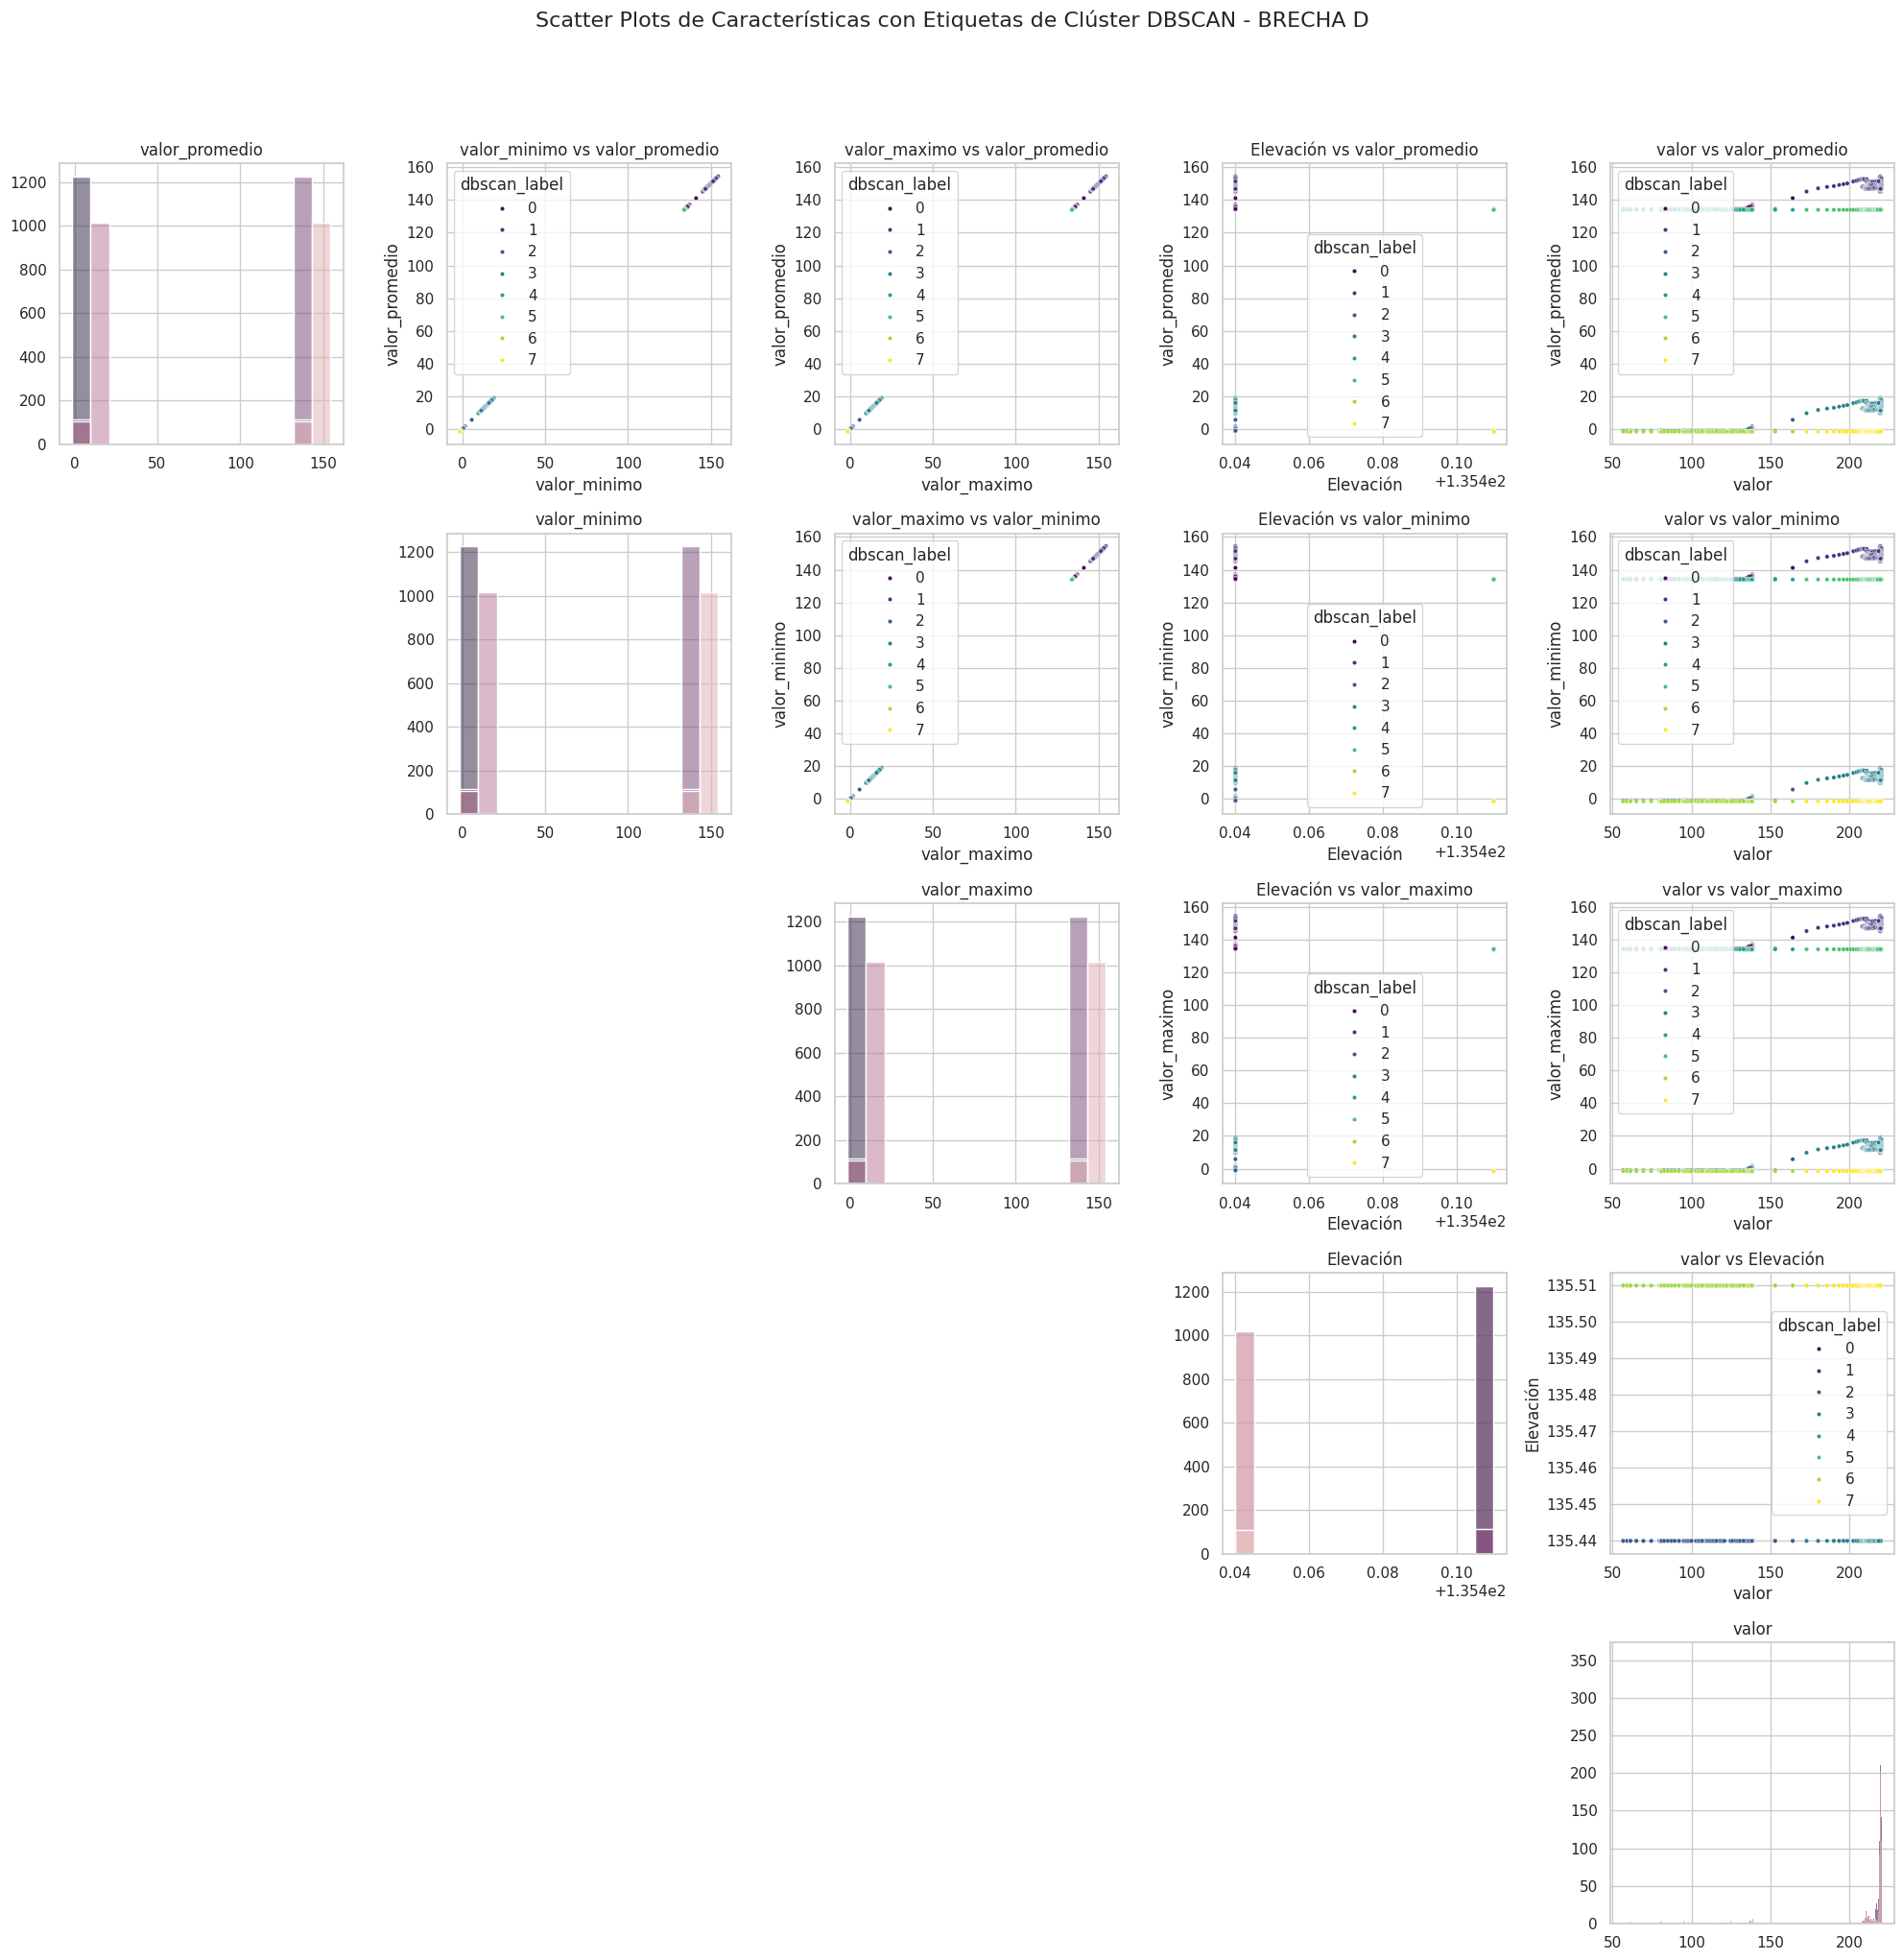


Interpretación de los gráficos de dispersión para 'BRECHA D':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.

--- Visualización de Clustering DBSCAN para: BRECHA C ---


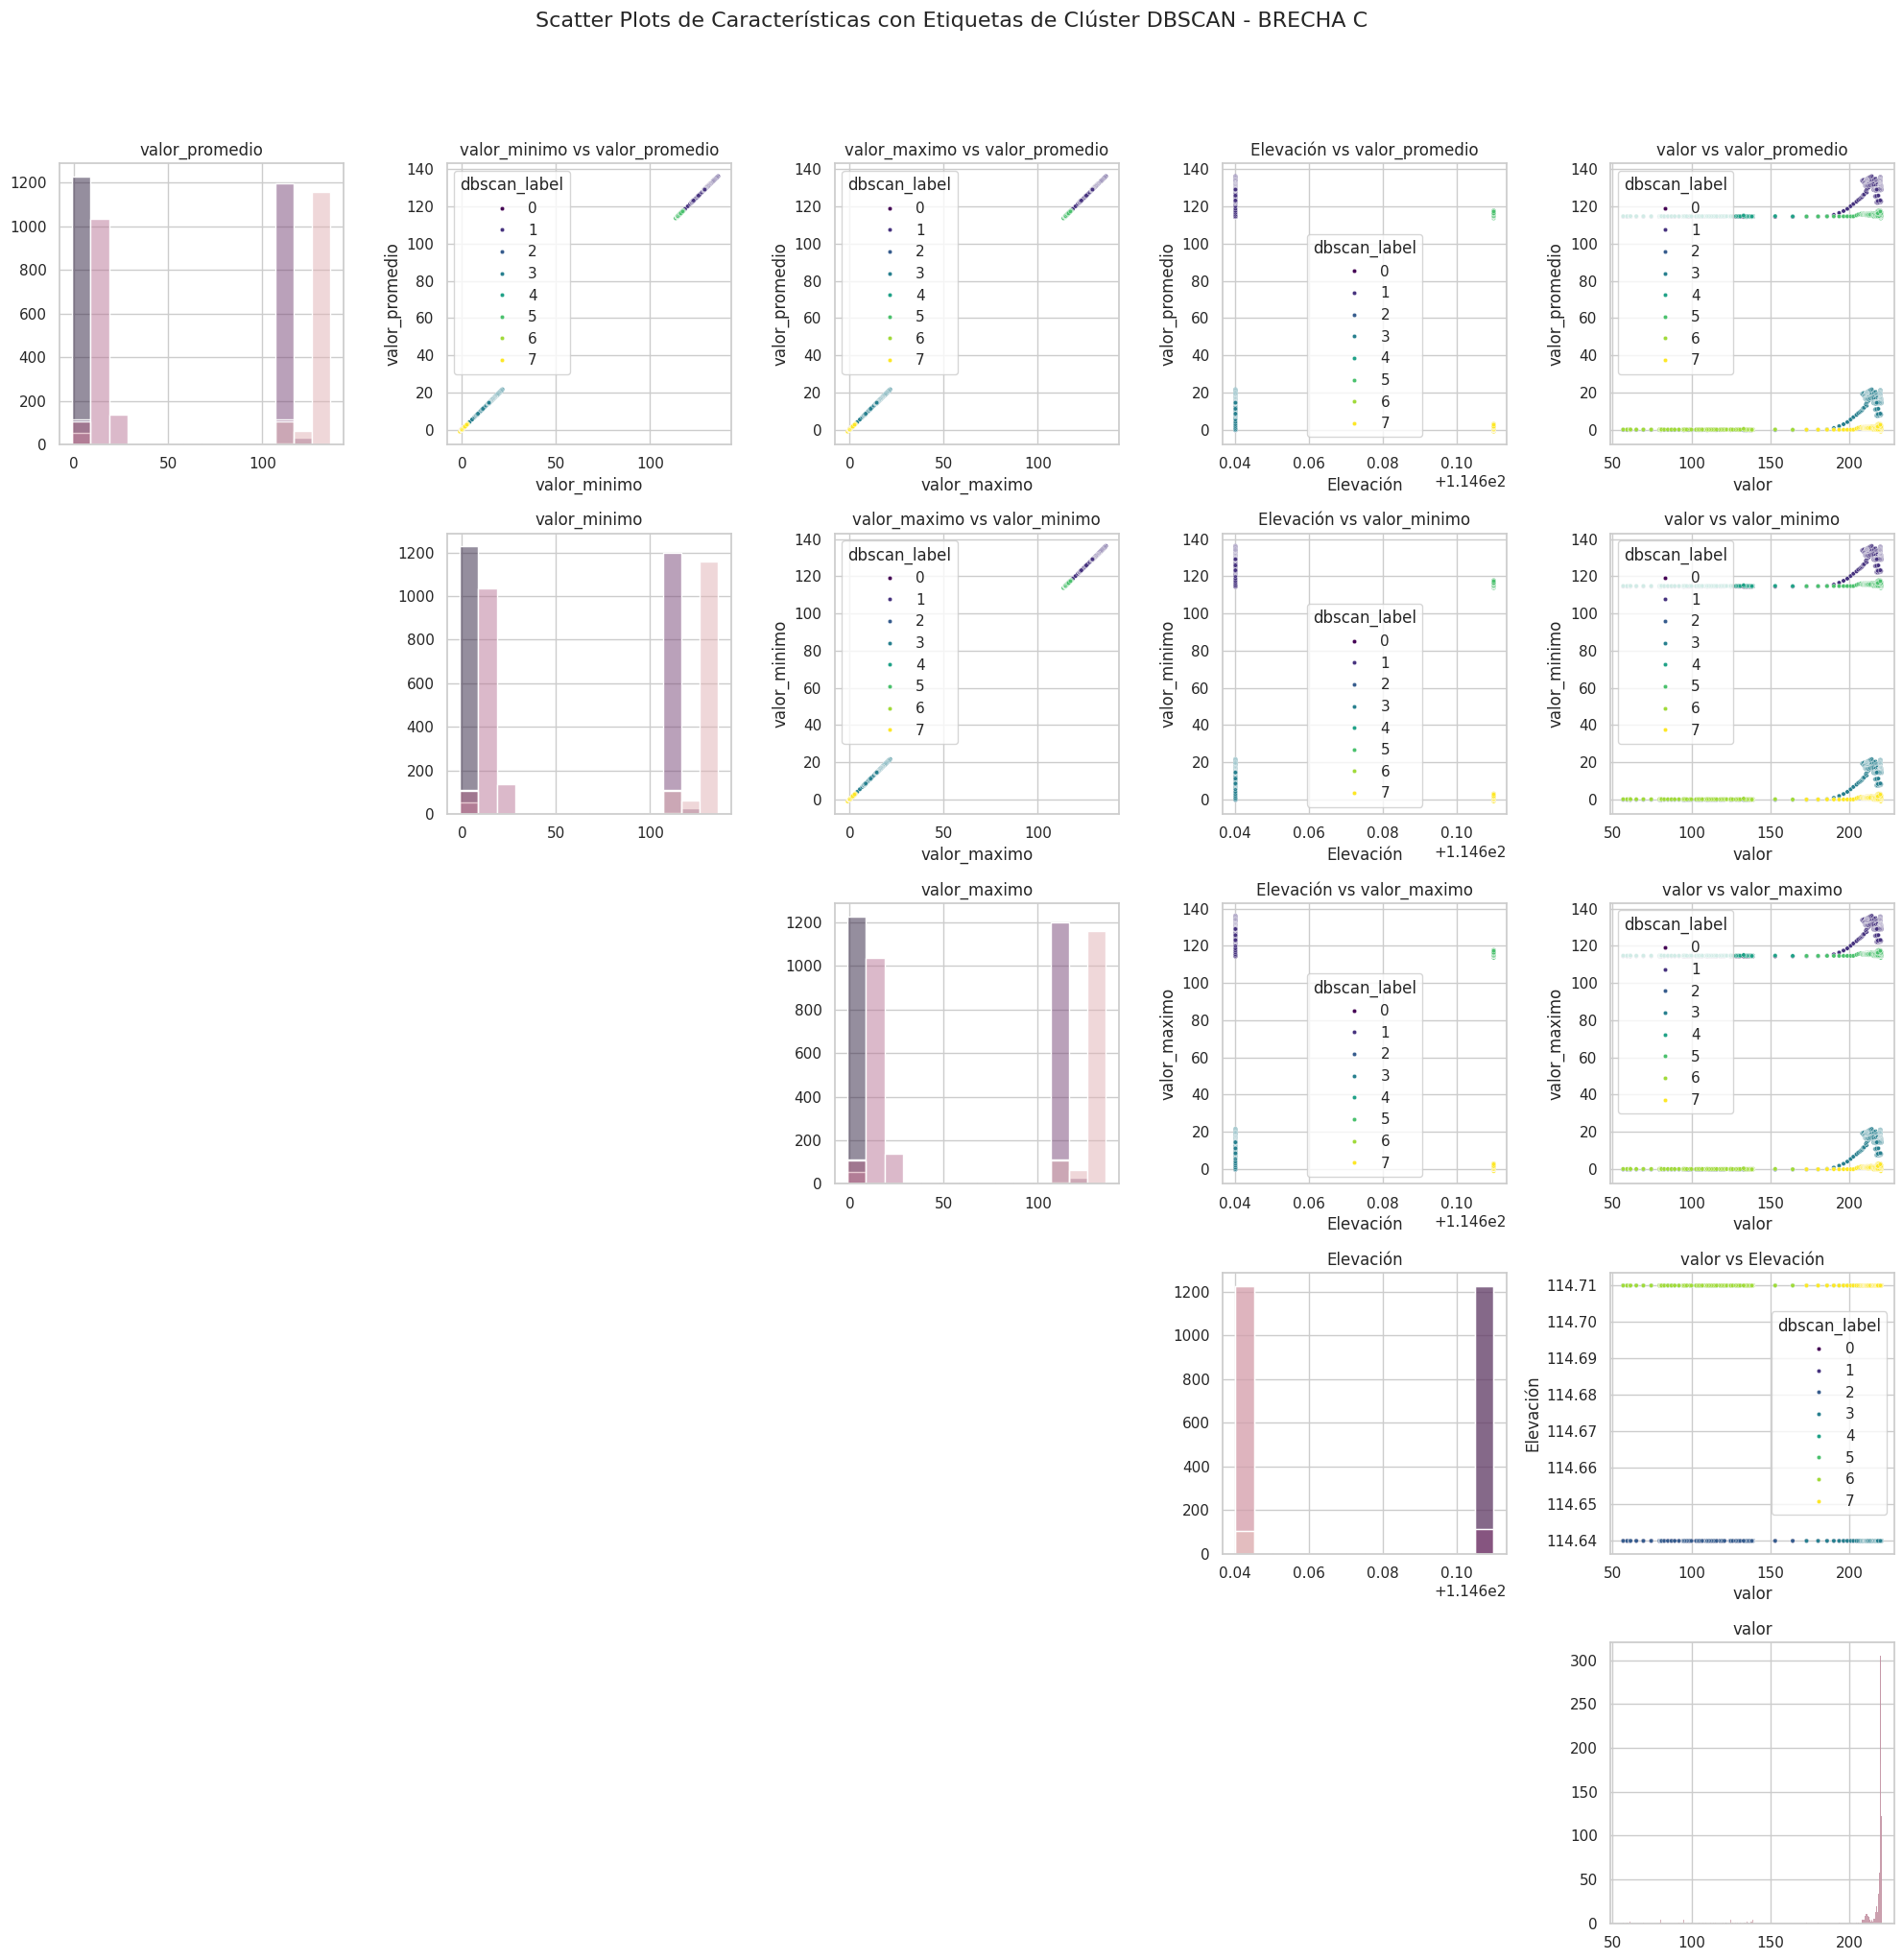


Interpretación de los gráficos de dispersión para 'BRECHA C':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.

--- Visualización de Clustering DBSCAN para: DERRAME D ---


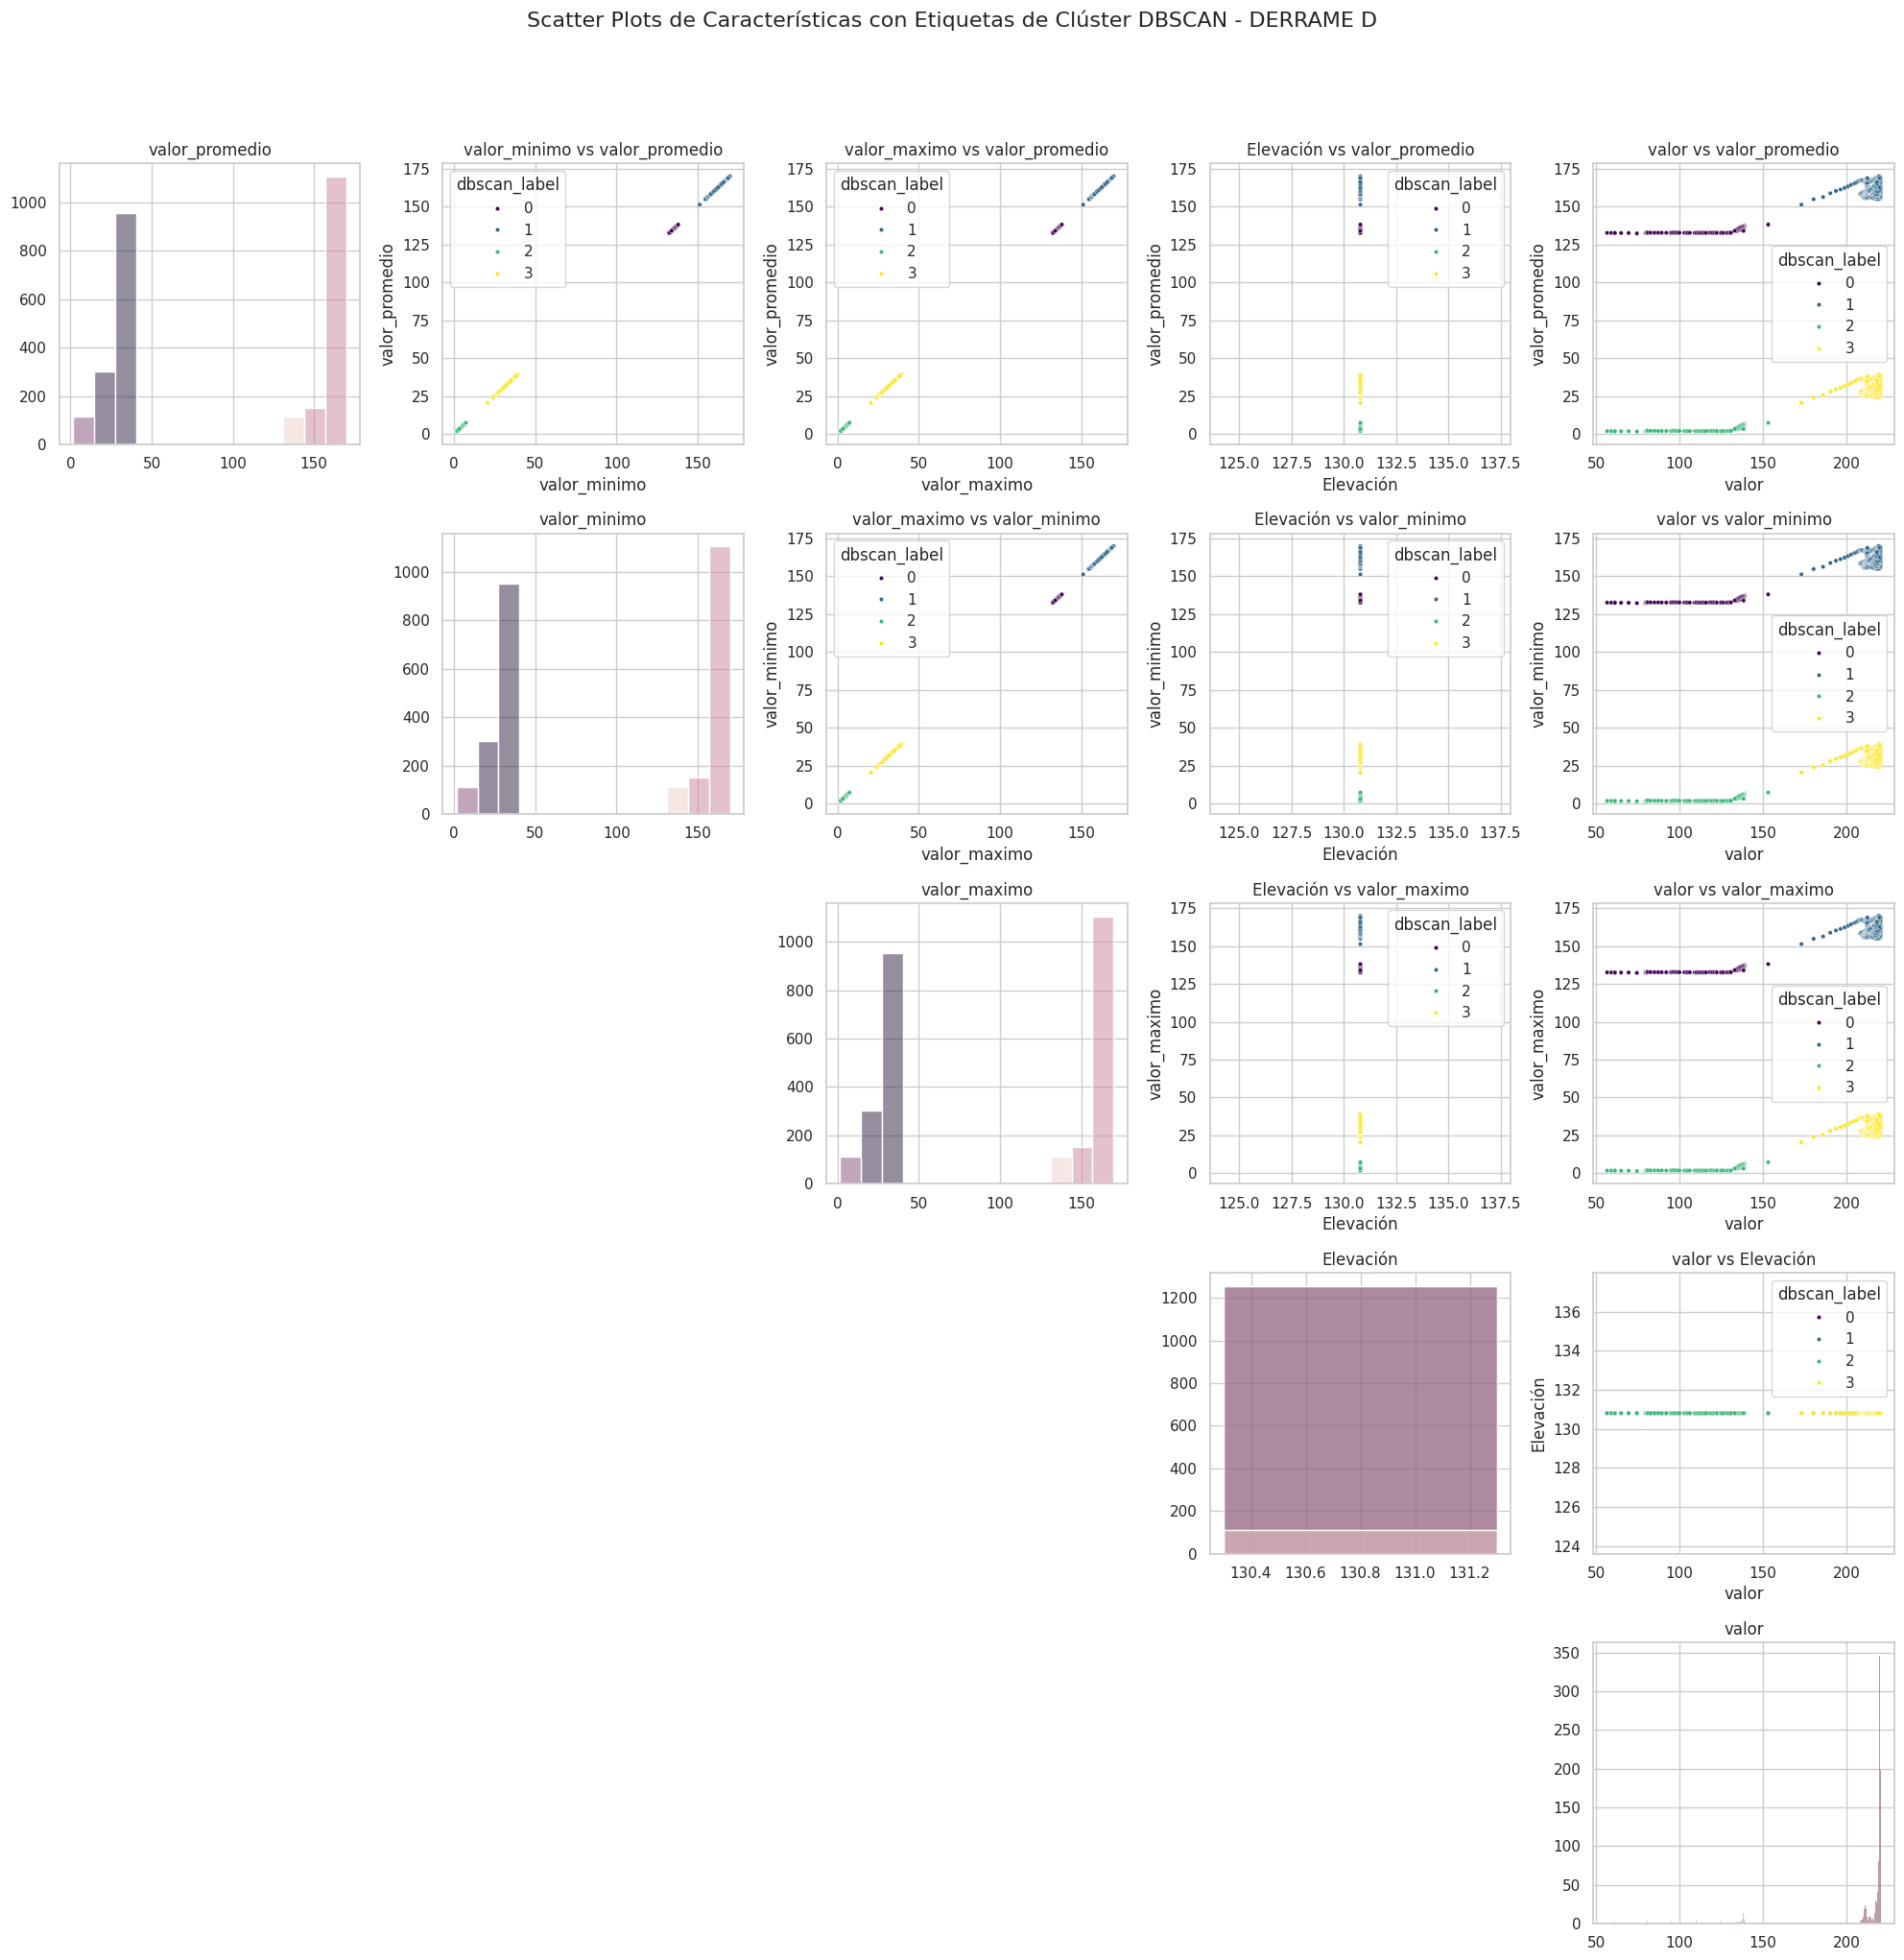


Interpretación de los gráficos de dispersión para 'DERRAME D':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.
Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.
Los puntos con etiqueta -1 (ruido) son posibles anomalías y deberían destacar,
a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.
Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.
Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.


In [38]:
# Iterate through the dbscan_results_by_location dictionary
for location, df_result in dbscan_results_by_location.items():
    print(f"\n--- Visualización de Clustering DBSCAN para: {location} ---")

    # Prepare the data for visualization
    # Select the features that were used for DBSCAN clustering
    # We will use the same features as defined in the previous subtask: features_for_dbscan
    features_for_dbscan_plotting = features_for_dbscan # Assuming features_for_dbscan is still available

    # Create scatter plots for pairs of the selected features
    # We'll create a matrix of scatter plots for all pairs of features.
    n_features = len(features_for_dbscan_plotting)
    fig, axes = plt.subplots(n_features, n_features, figsize=(4 * n_features, 4 * n_features))
    plt.suptitle(f"Scatter Plots de Características con Etiquetas de Clúster DBSCAN - {location}", y=1.02, fontsize=16)

    for i in range(n_features):
        for j in range(n_features):
            if i == j:
                # On the diagonal, plot a histogram of the feature
                sns.histplot(data=df_result, x=features_for_dbscan_plotting[i], hue='dbscan_label', ax=axes[i, j], legend=False) # Removed kde=True
                axes[i, j].set_xlabel("")
                axes[i, j].set_ylabel("")
                axes[i, j].set_title(features_for_dbscan_plotting[i])
            elif i < j:
                # For off-diagonal plots, create scatter plots
                sns.scatterplot(
                    data=df_result,
                    x=features_for_dbscan_plotting[j],
                    y=features_for_dbscan_plotting[i],
                    hue='dbscan_label',
                    palette='viridis', # Use a distinct color palette
                    legend='full',
                    ax=axes[i, j],
                    s=10 # Adjust point size for clarity
                )
                axes[i, j].set_title(f'{features_for_dbscan_plotting[j]} vs {features_for_dbscan_plotting[i]}')
                axes[i, j].set_xlabel(features_for_dbscan_plotting[j])
                axes[i, j].set_ylabel(features_for_dbscan_plotting[i])
            else:
                # Hide the redundant lower triangle of the matrix
                fig.delaxes(axes[i, j])

    # Improve layout and display plots
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap
    plt.show()

    # Add interpretation guidance
    print(f"\nInterpretación de los gráficos de dispersión para '{location}':")
    print("Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.")
print("Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.")
print("Los puntos con etiqueta -1 (ruido) son posibles anomalías y deberían destacar,")
print("a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.")
print("Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.")
print("Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.")


--- Visualización de Clustering DBSCAN para: CONTATO D/E ---


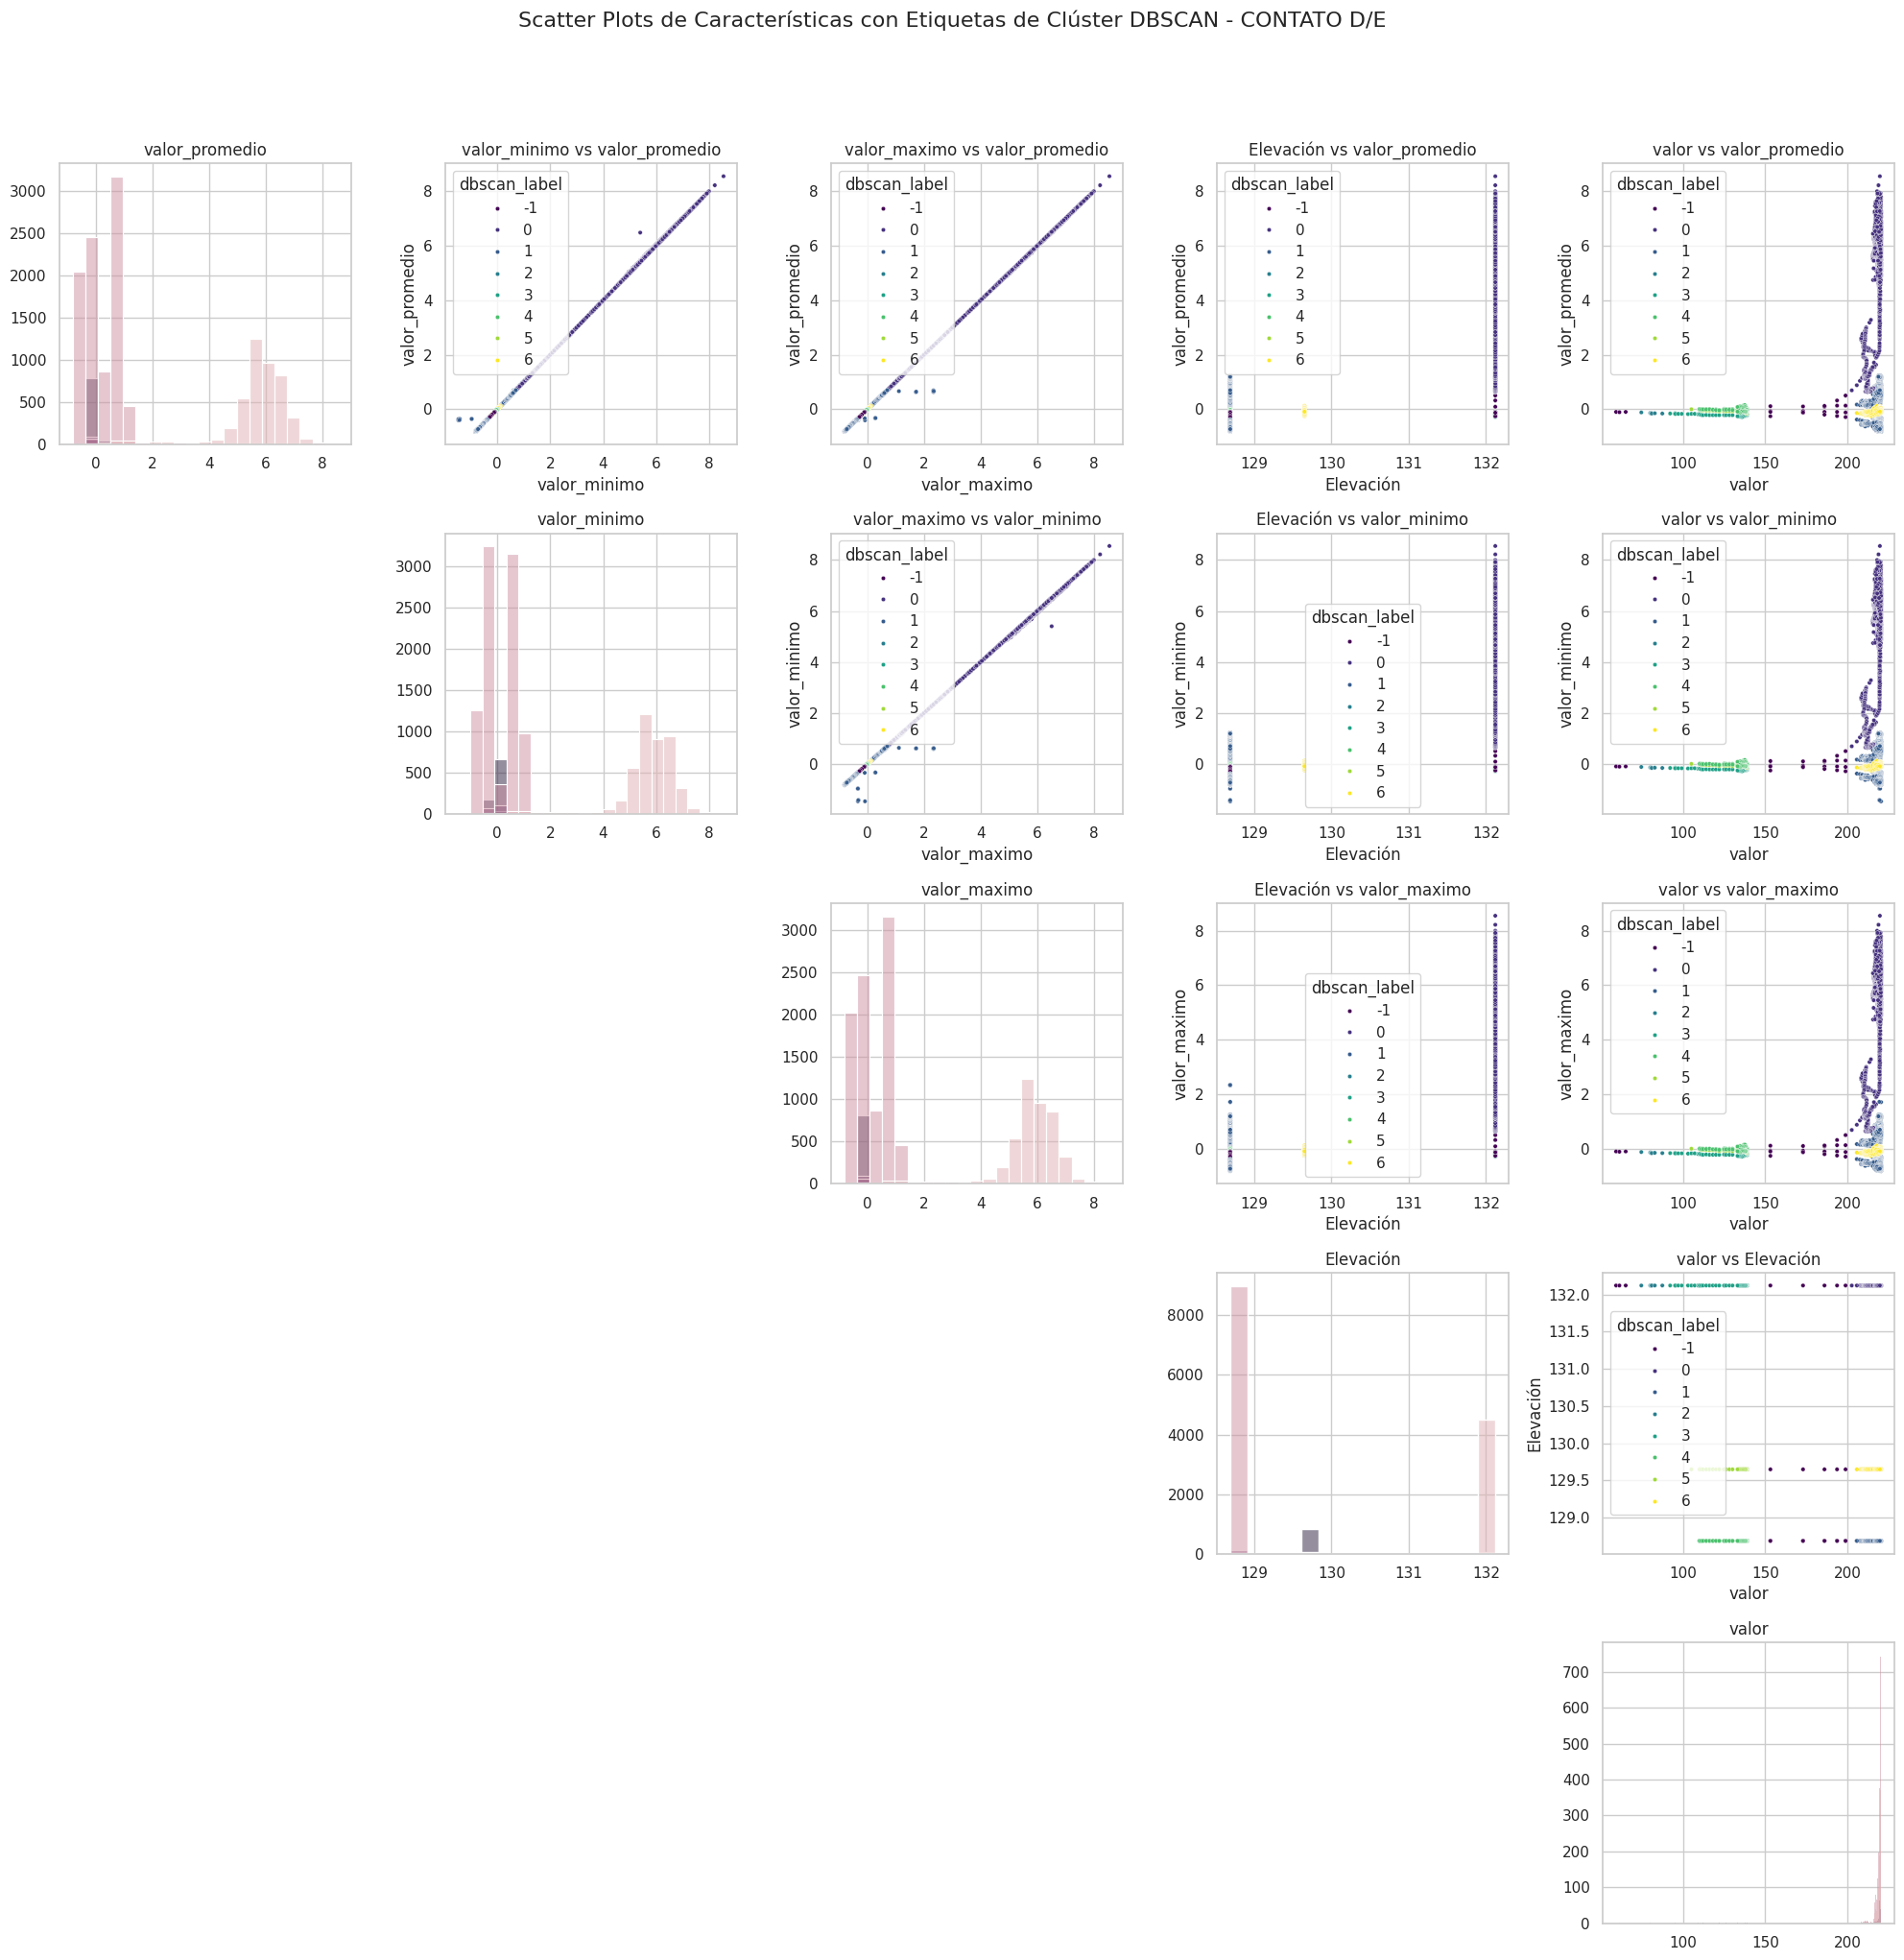


Interpretación de los gráficos de dispersión para 'CONTATO D/E':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.
Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.
Los puntos con etiqueta -1 (ruido) son posibles anomalías y deberían destacar,
a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.
Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.
Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.

--- Visualización de Clustering DBSCAN para: ROCHA FRATURADA ---


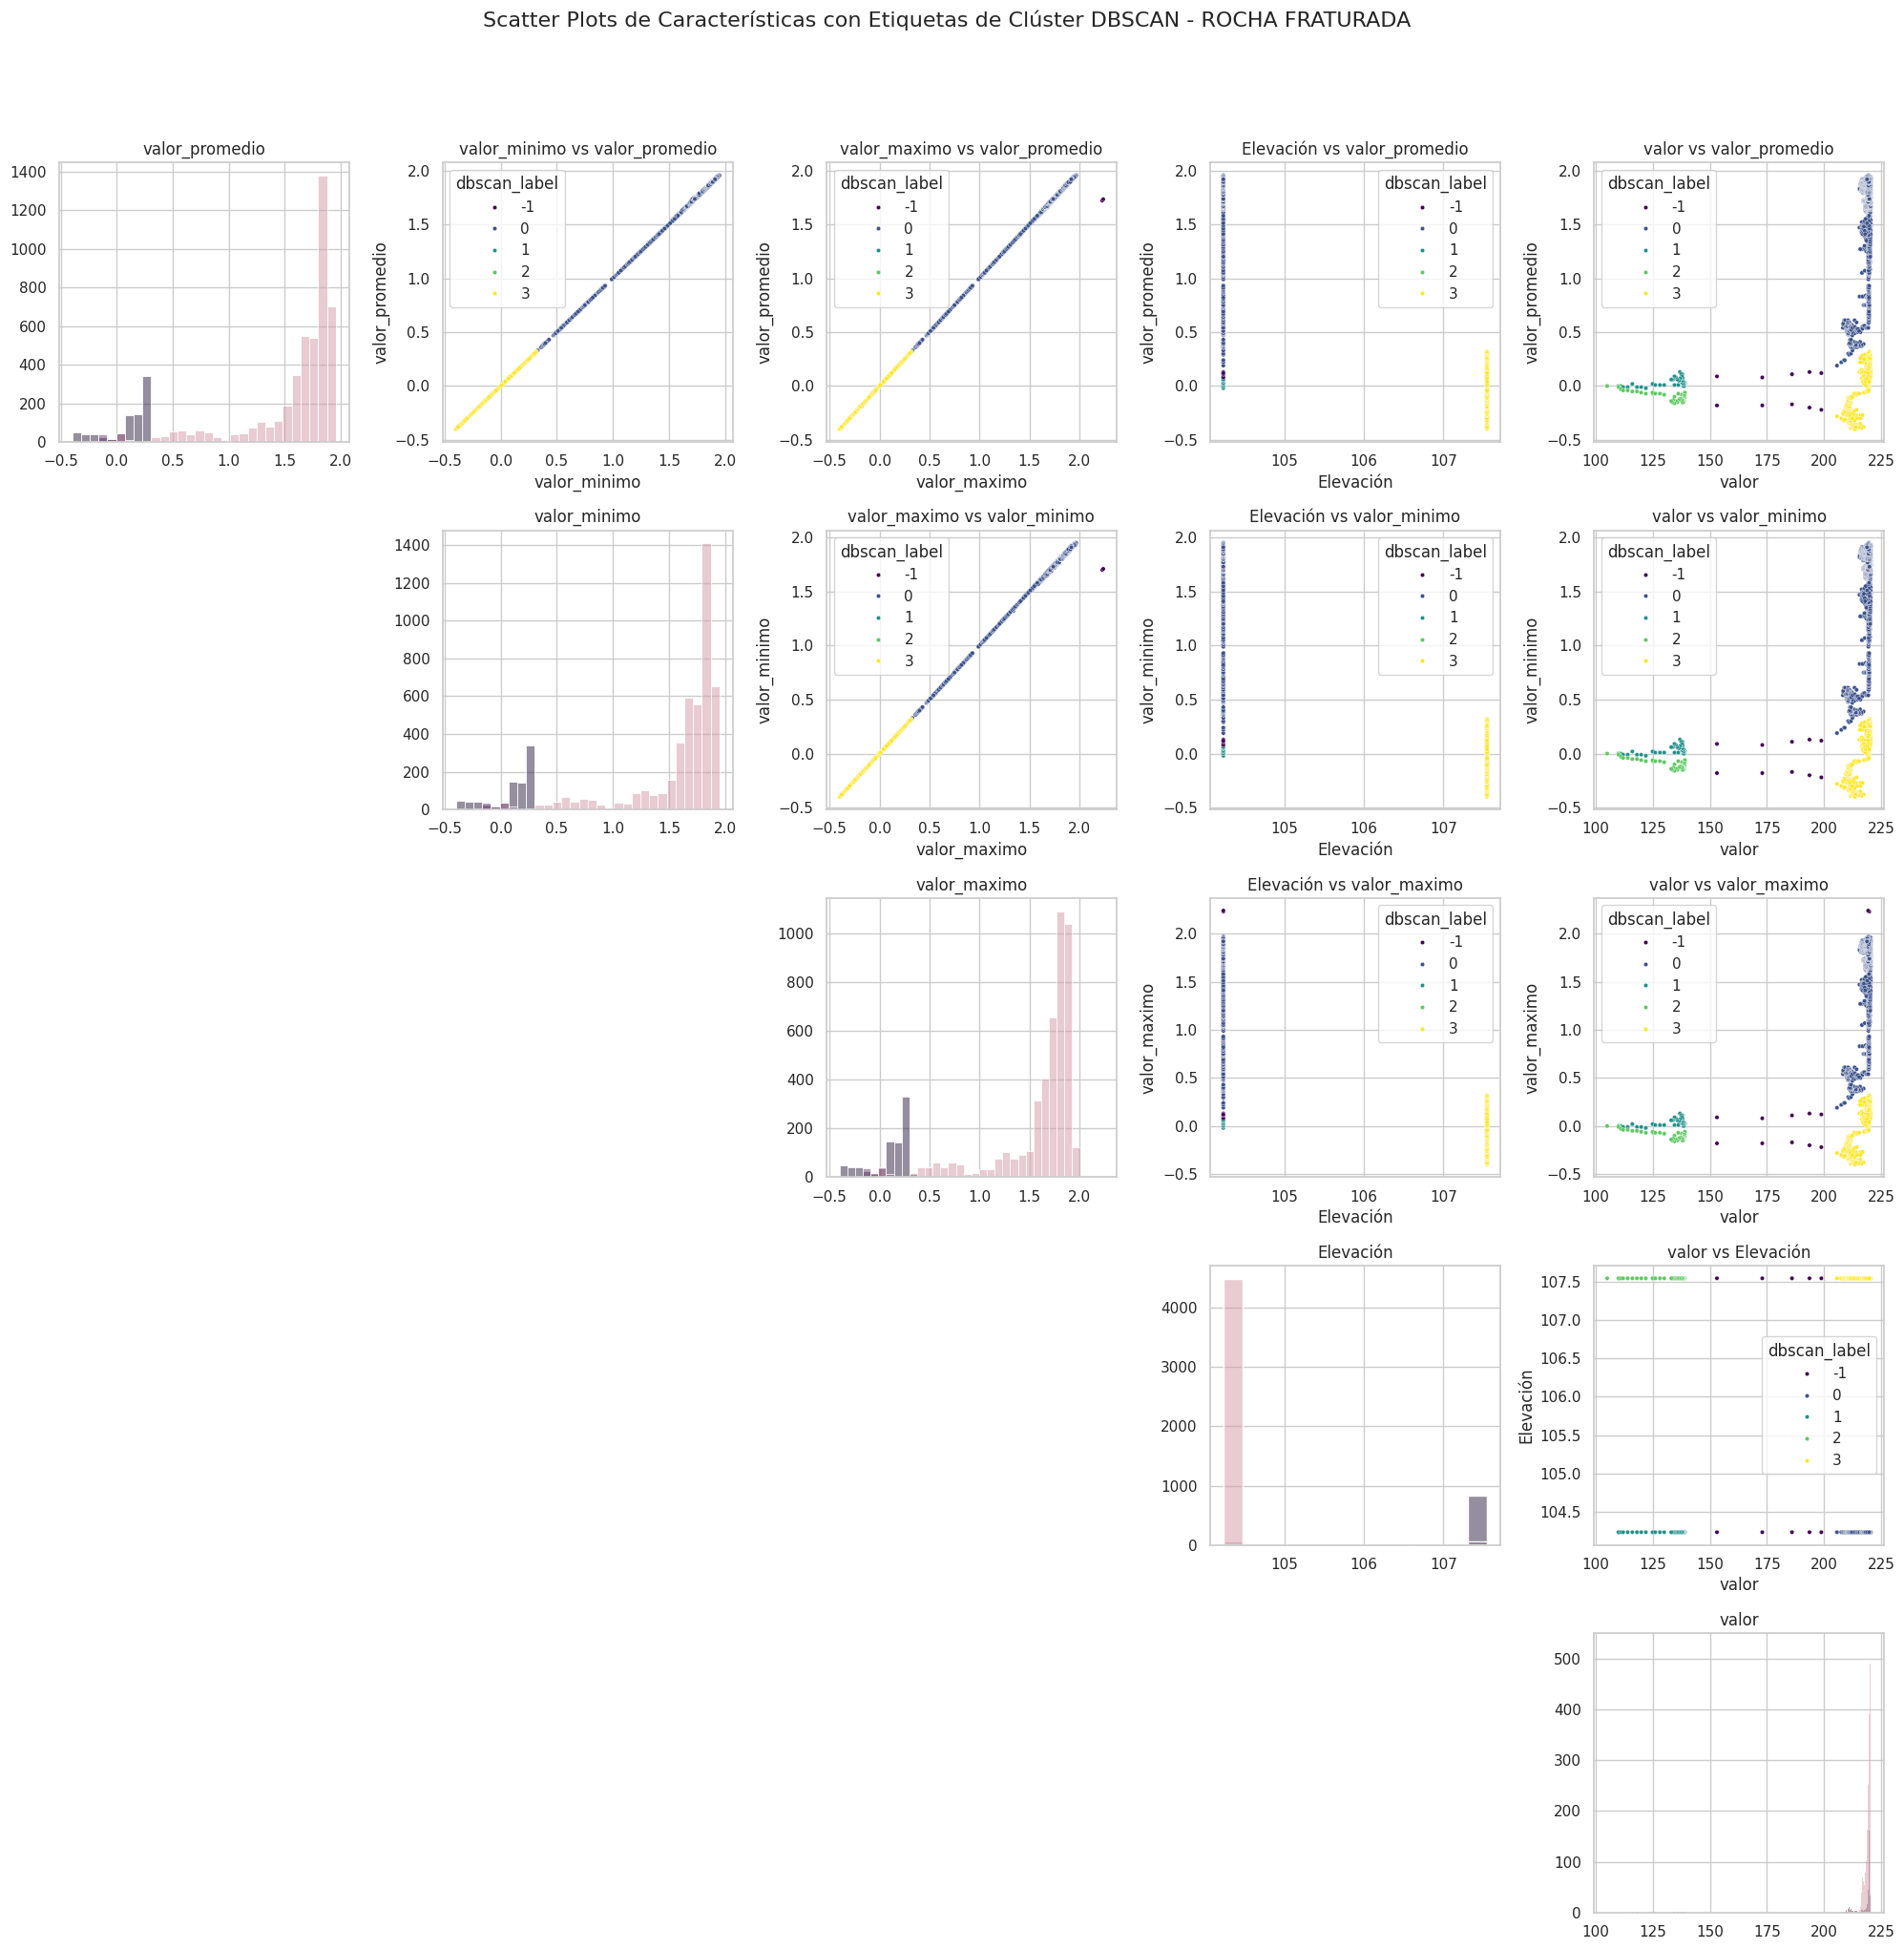


Interpretación de los gráficos de dispersión para 'ROCHA FRATURADA':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.
Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.
Los puntos con etiqueta -1 (ruido) son posibles anomalías y deberían destacar,
a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.
Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.
Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.

--- Visualización de Clustering DBSCAN para: JUNTA D ---


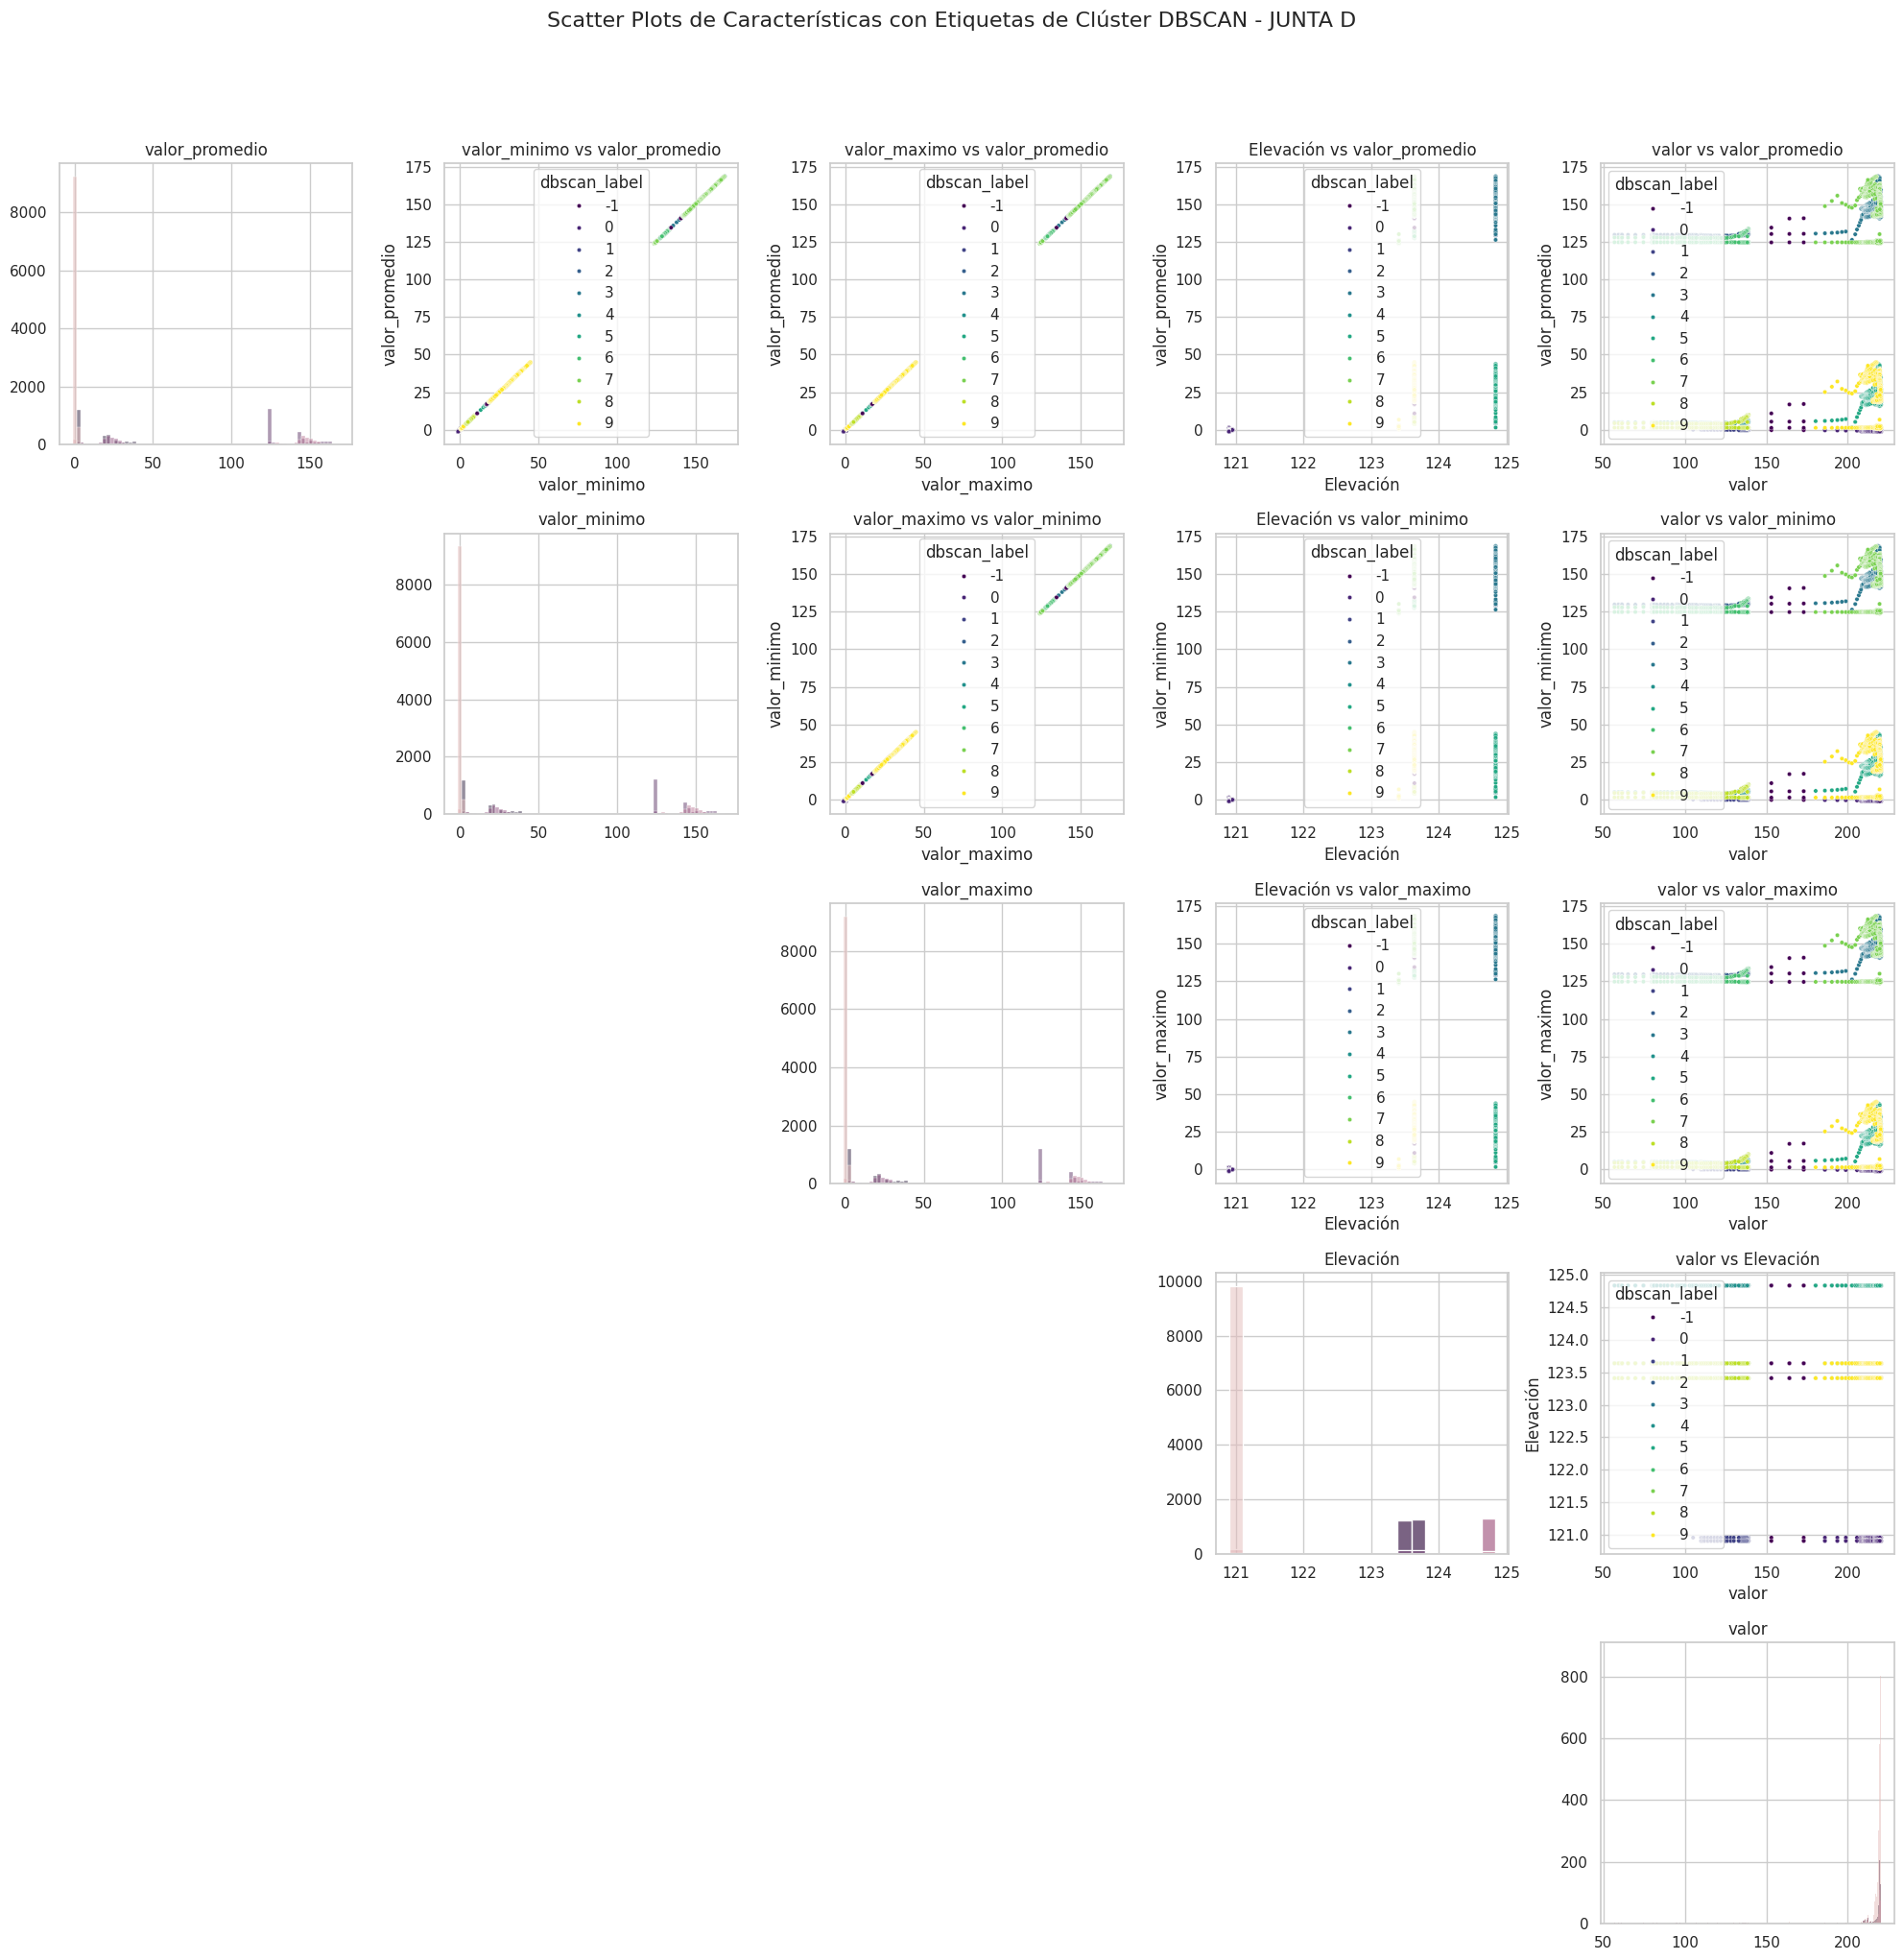


Interpretación de los gráficos de dispersión para 'JUNTA D':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.
Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.
Los puntos con etiqueta -1 (ruido) son posibles anomalías y deberían destacar,
a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.
Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.
Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.

--- Visualización de Clustering DBSCAN para: CONTATO C/D ---


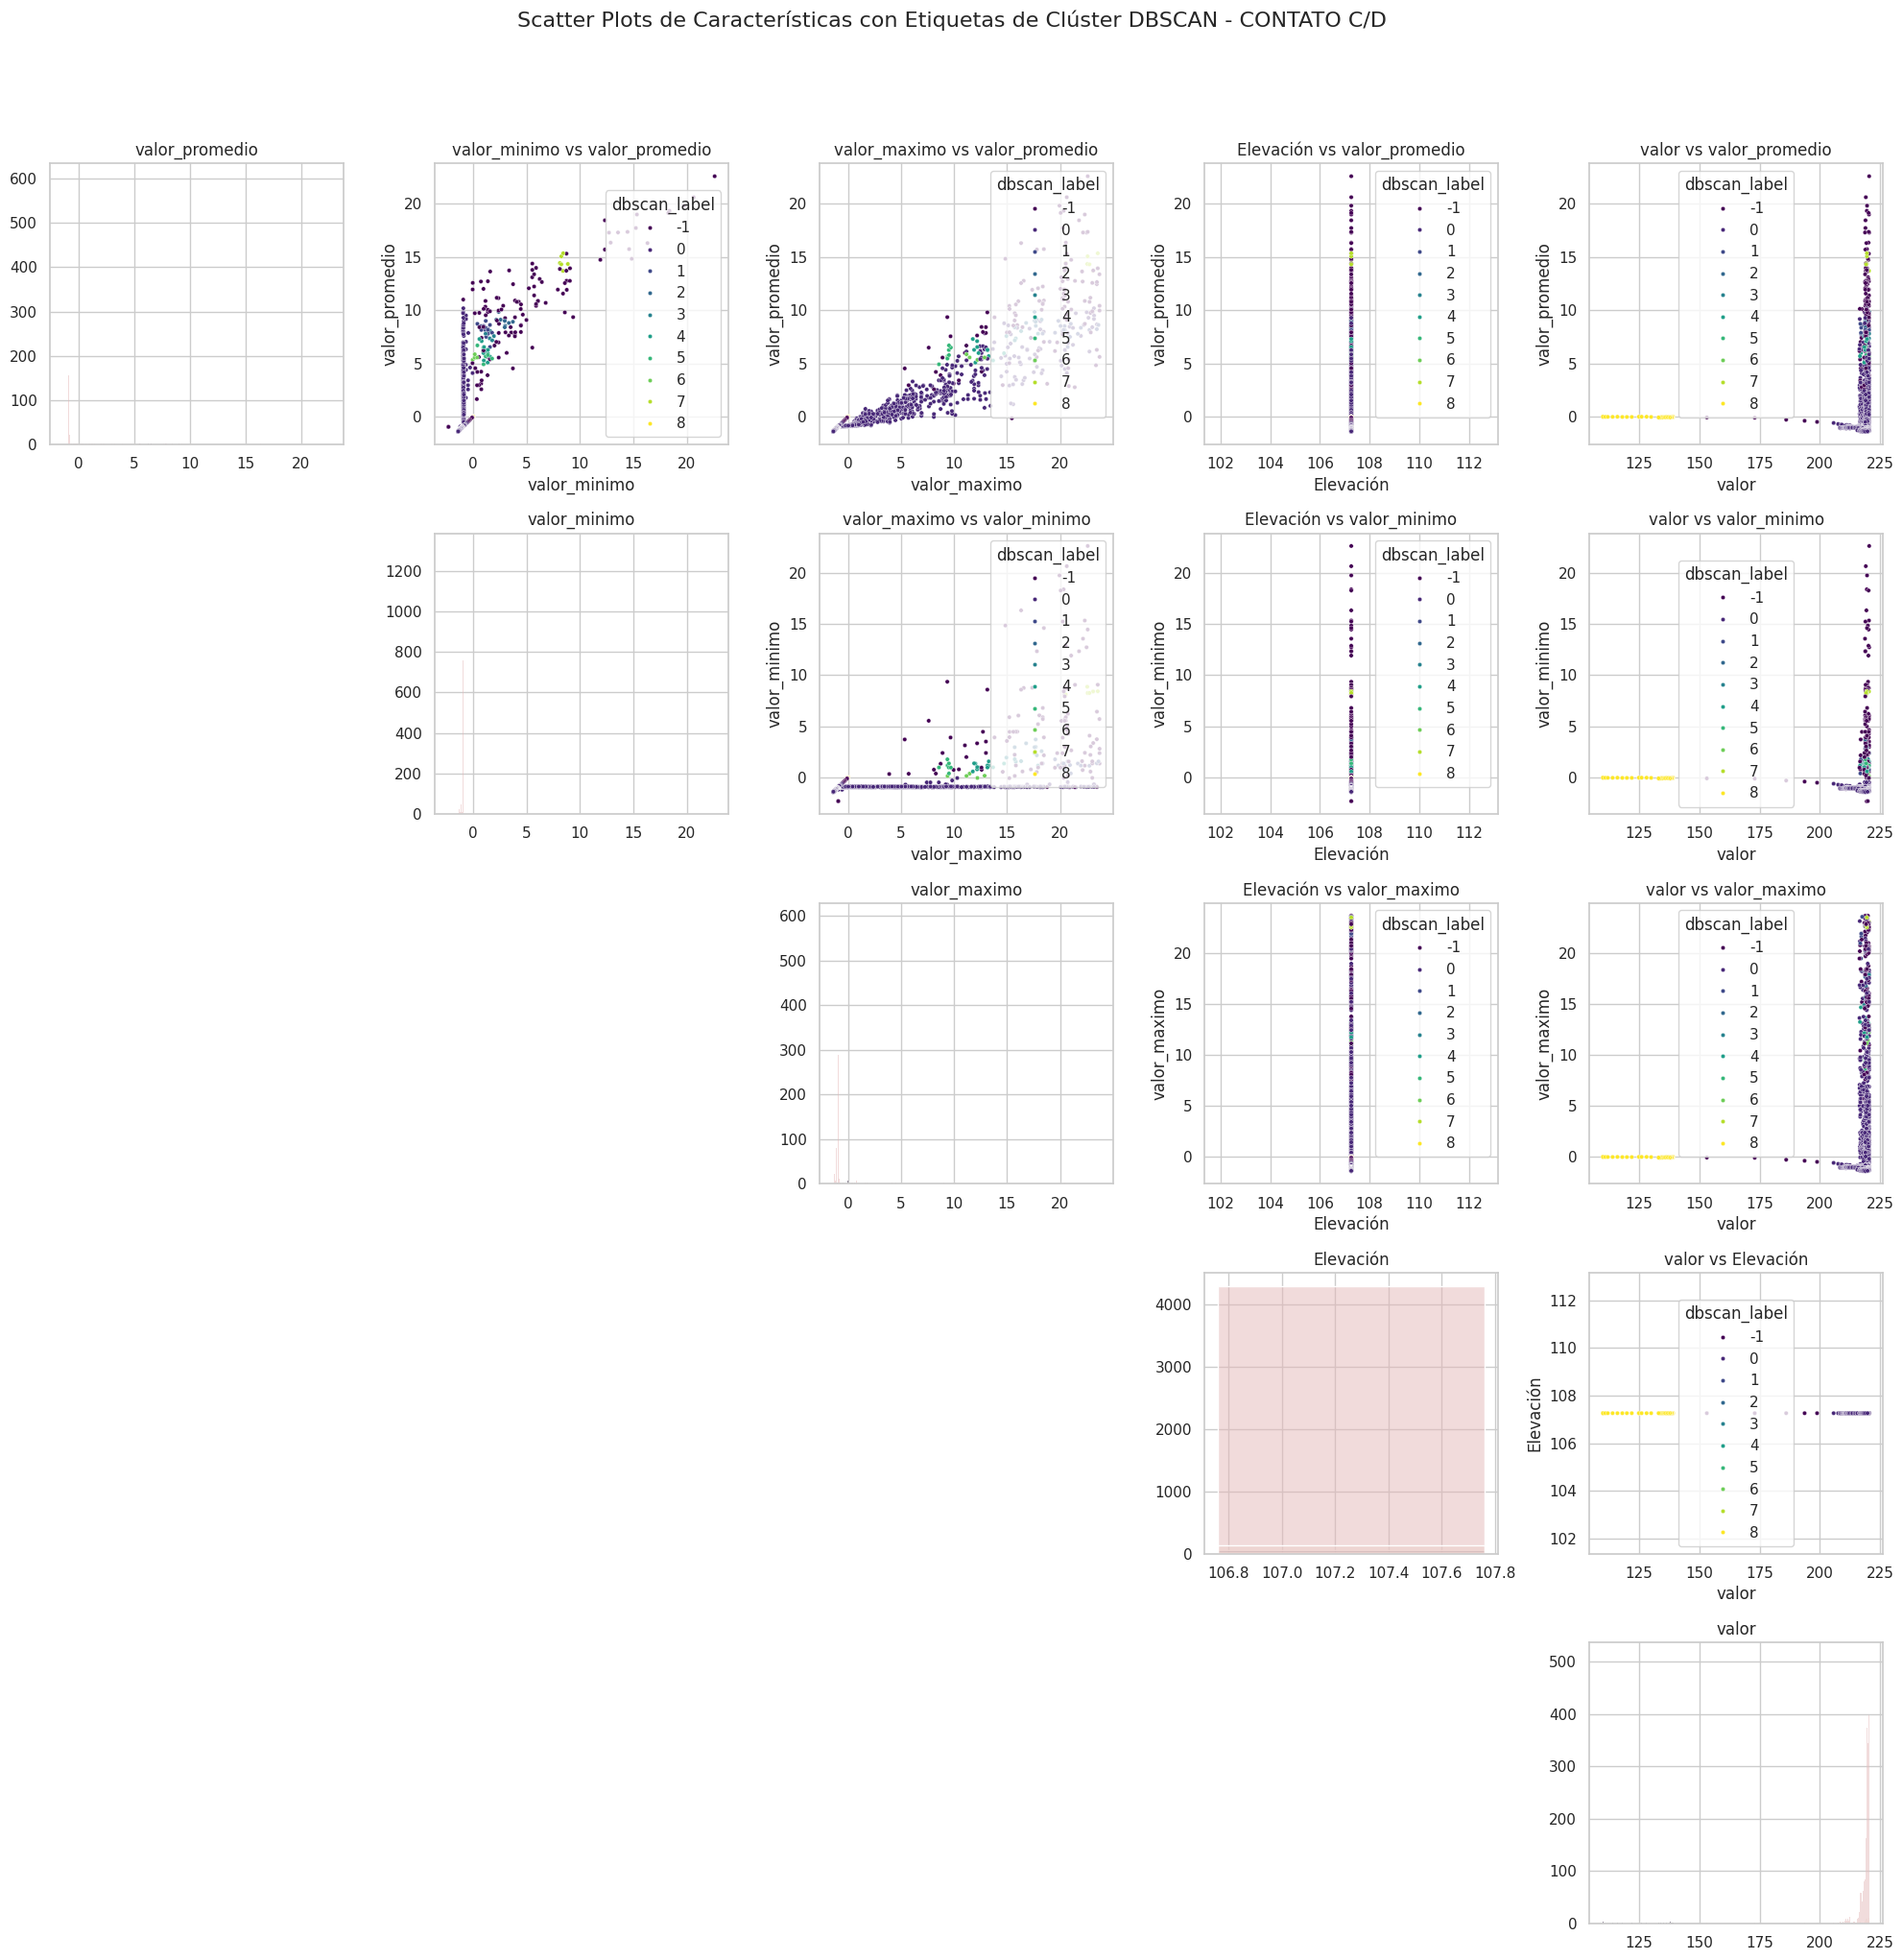


Interpretación de los gráficos de dispersión para 'CONTATO C/D':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.
Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.
Los puntos con etiqueta -1 (ruido) son posibles anomalías y deberían destacar,
a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.
Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.
Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.

--- Visualización de Clustering DBSCAN para: SIN ASIGNAR ---


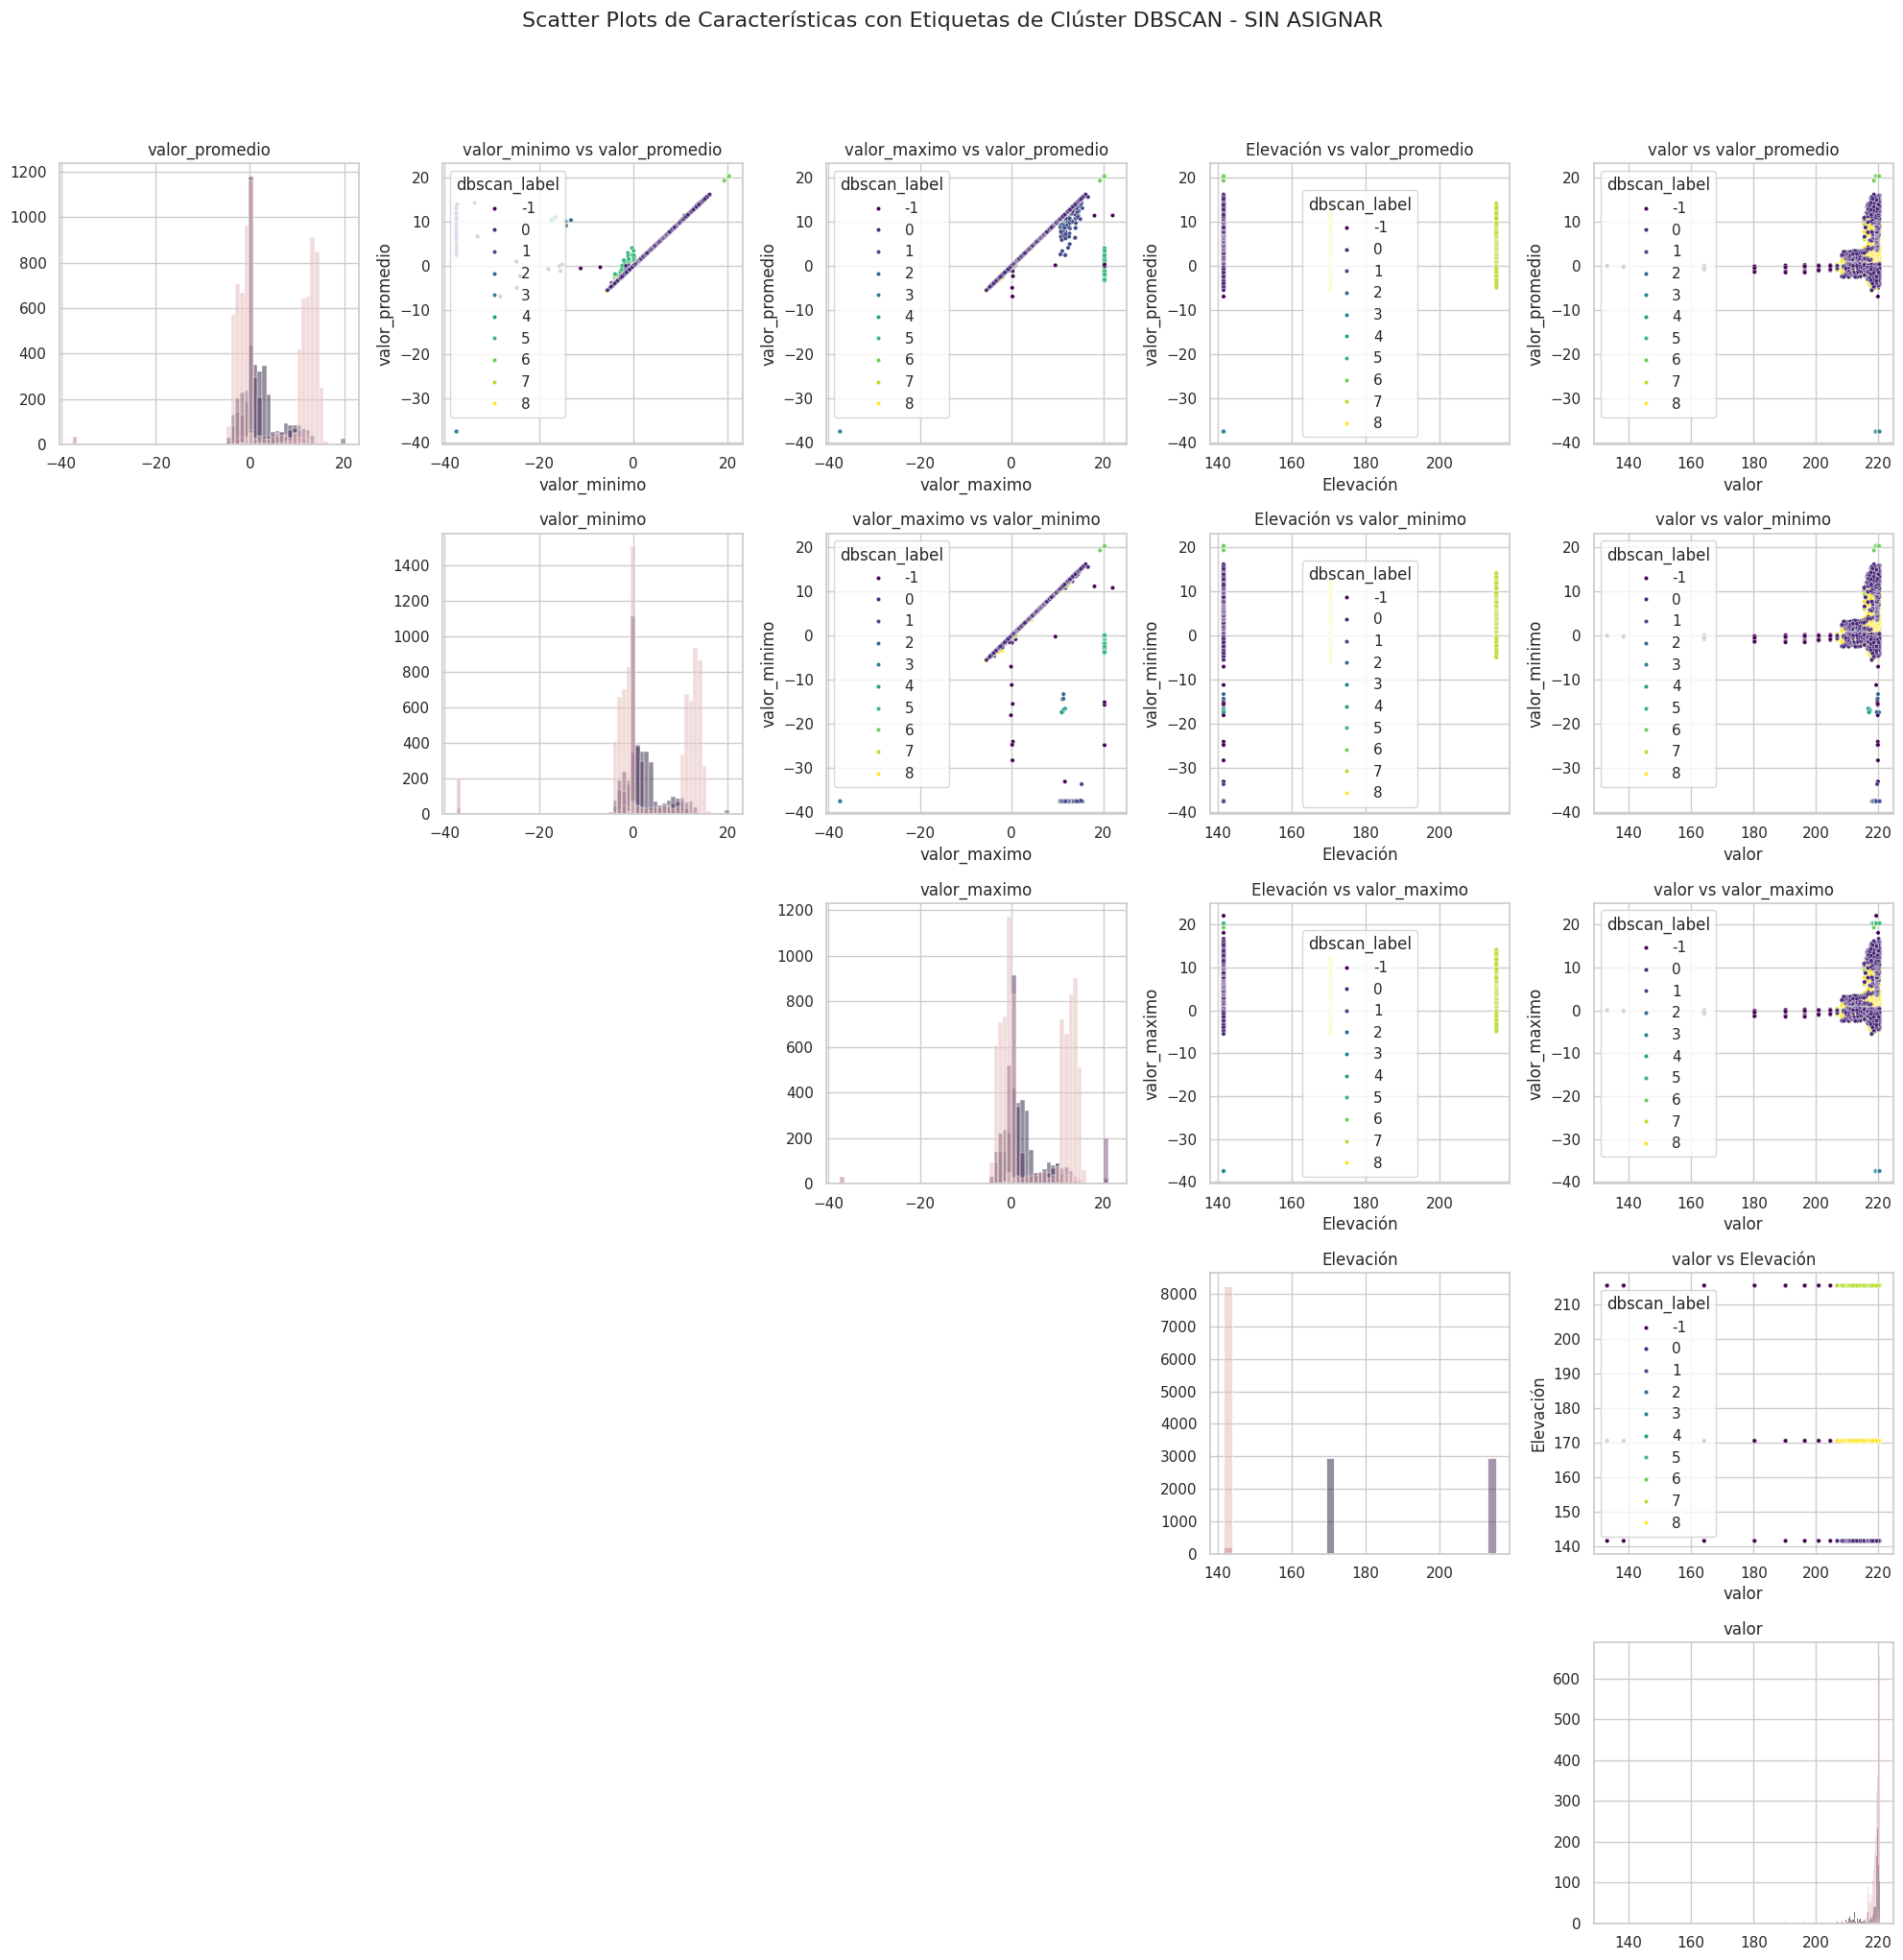


Interpretación de los gráficos de dispersión para 'SIN ASIGNAR':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.
Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.
Los puntos con etiqueta -1 (ruido) son posibles anomalías y deberían destacar,
a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.
Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.
Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.

--- Visualización de Clustering DBSCAN para: CONTATO CONCRETO/ROCHA ---


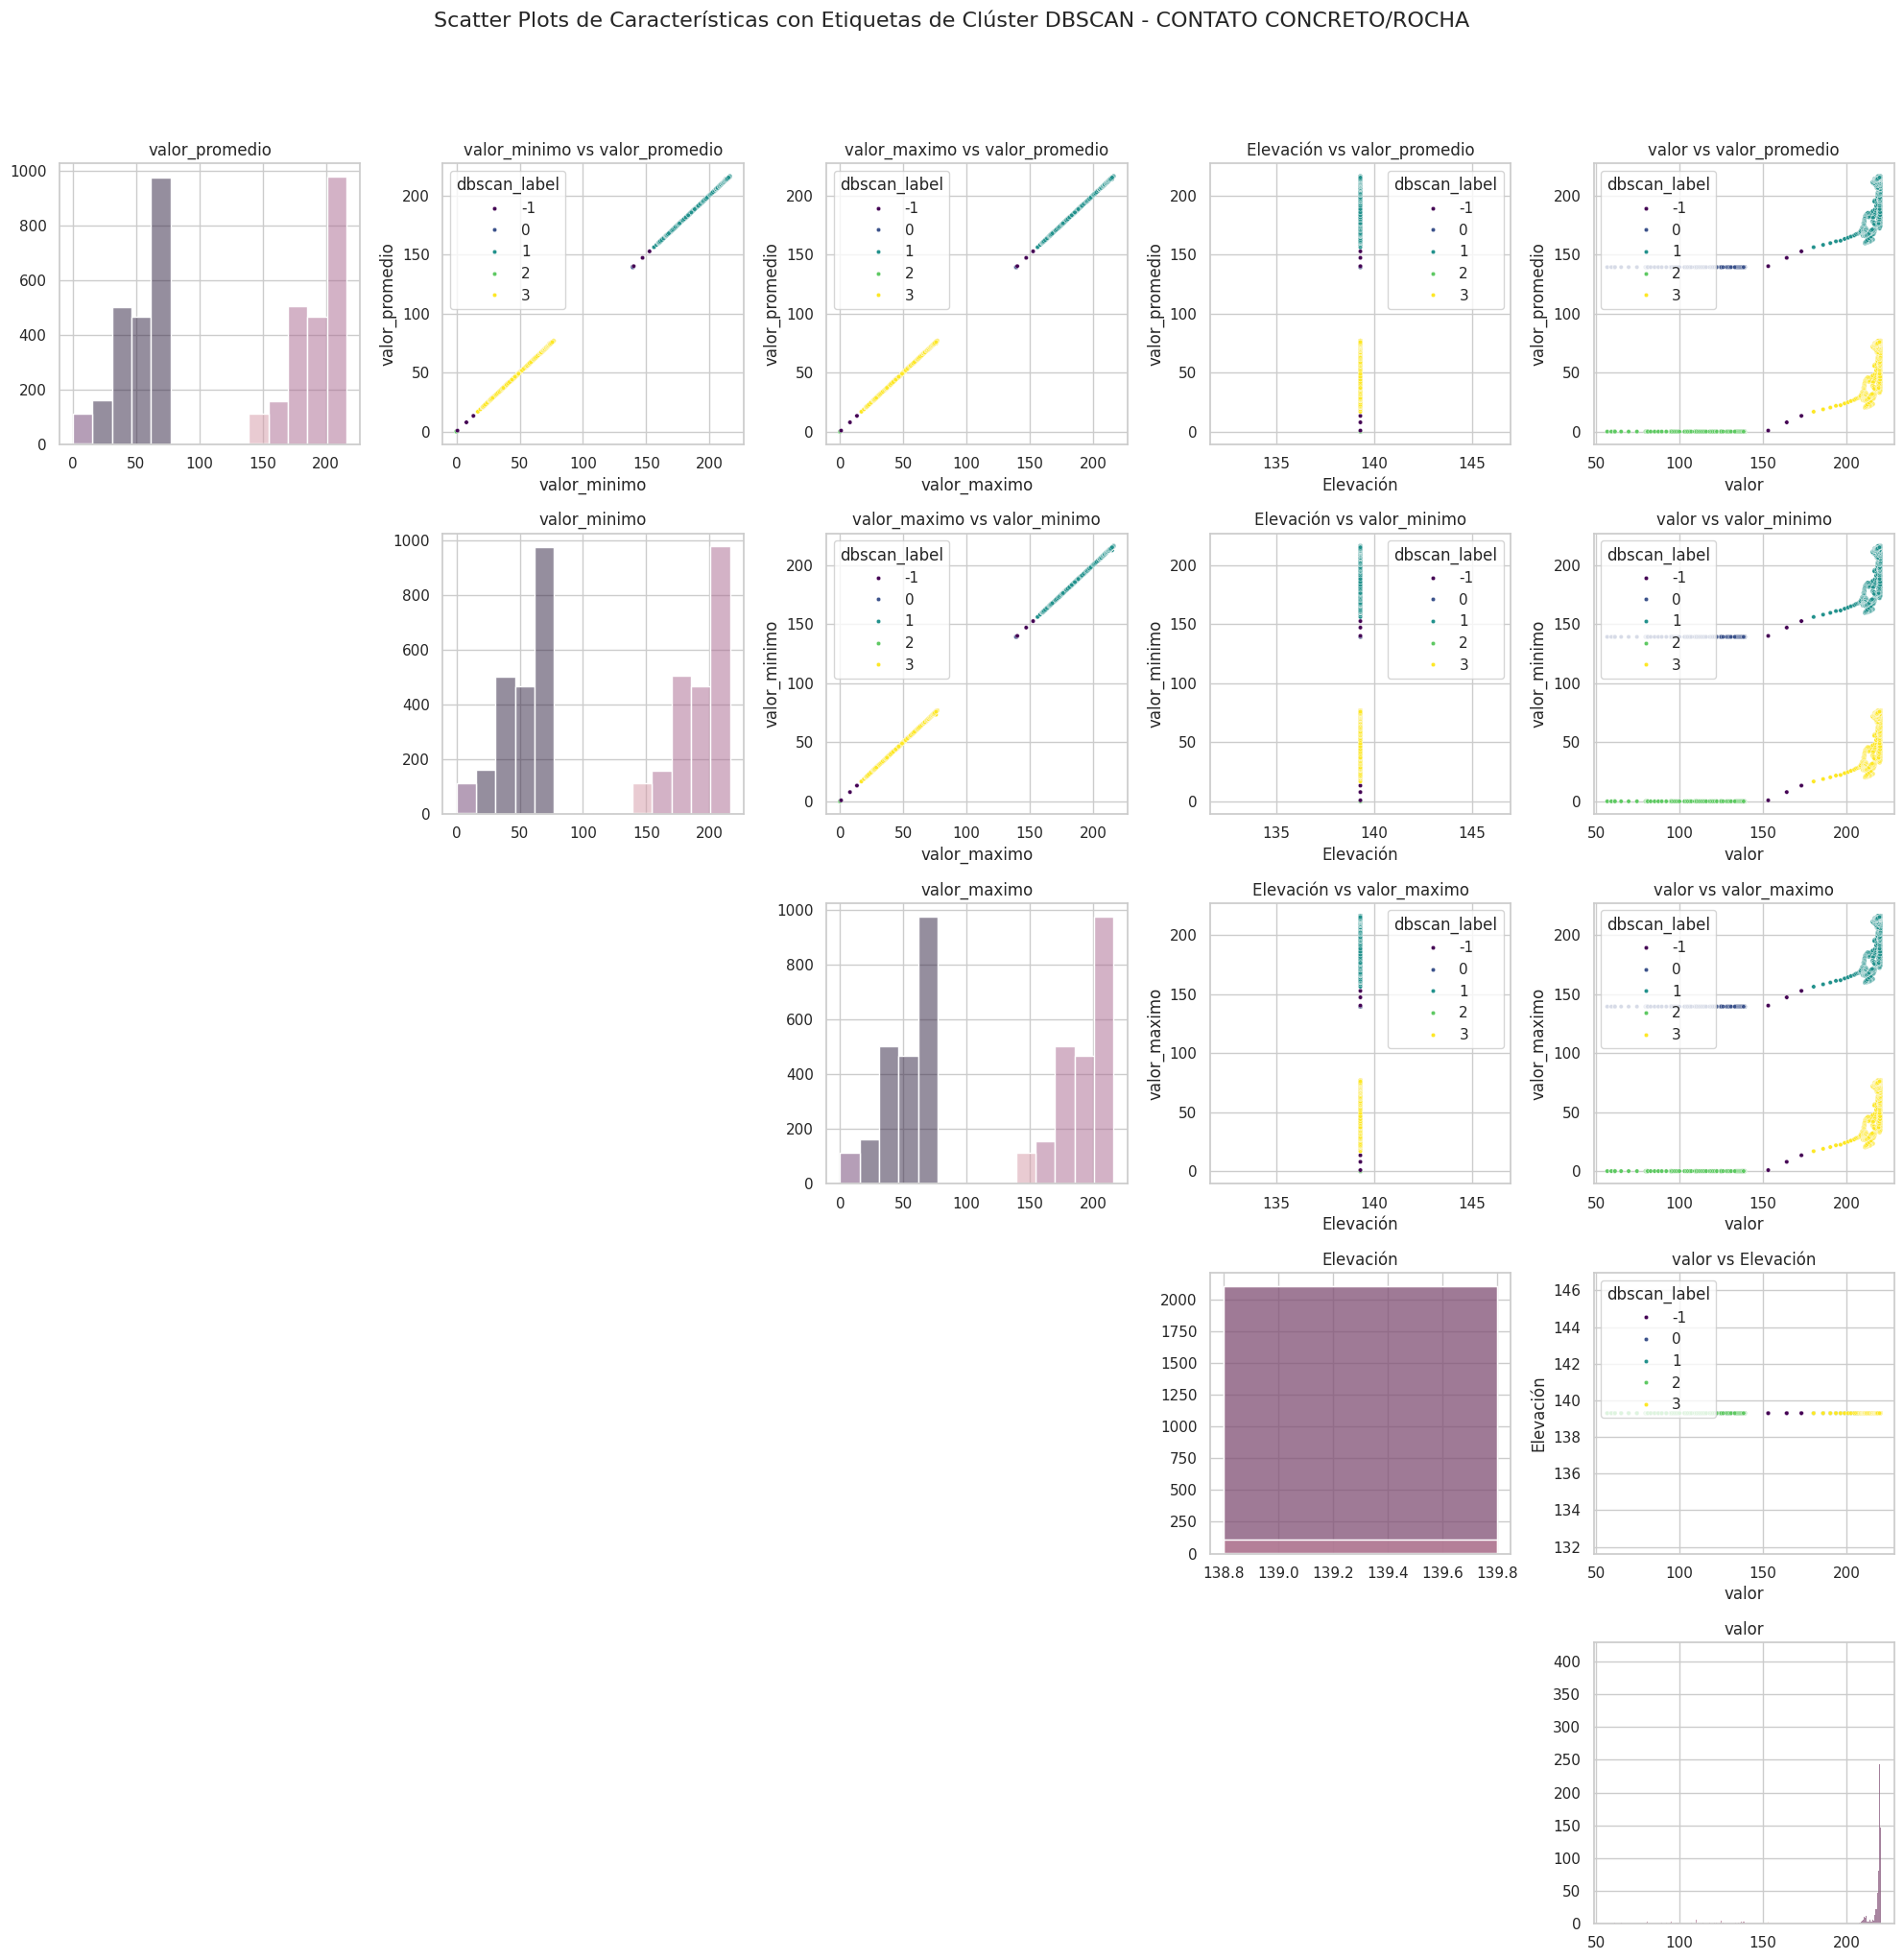


Interpretación de los gráficos de dispersión para 'CONTATO CONCRETO/ROCHA':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.
Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.
Los puntos con etiqueta -1 (ruido) son posibles anomalías y deberían destacar,
a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.
Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.
Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.

--- Visualización de Clustering DBSCAN para: BRECHA D ---


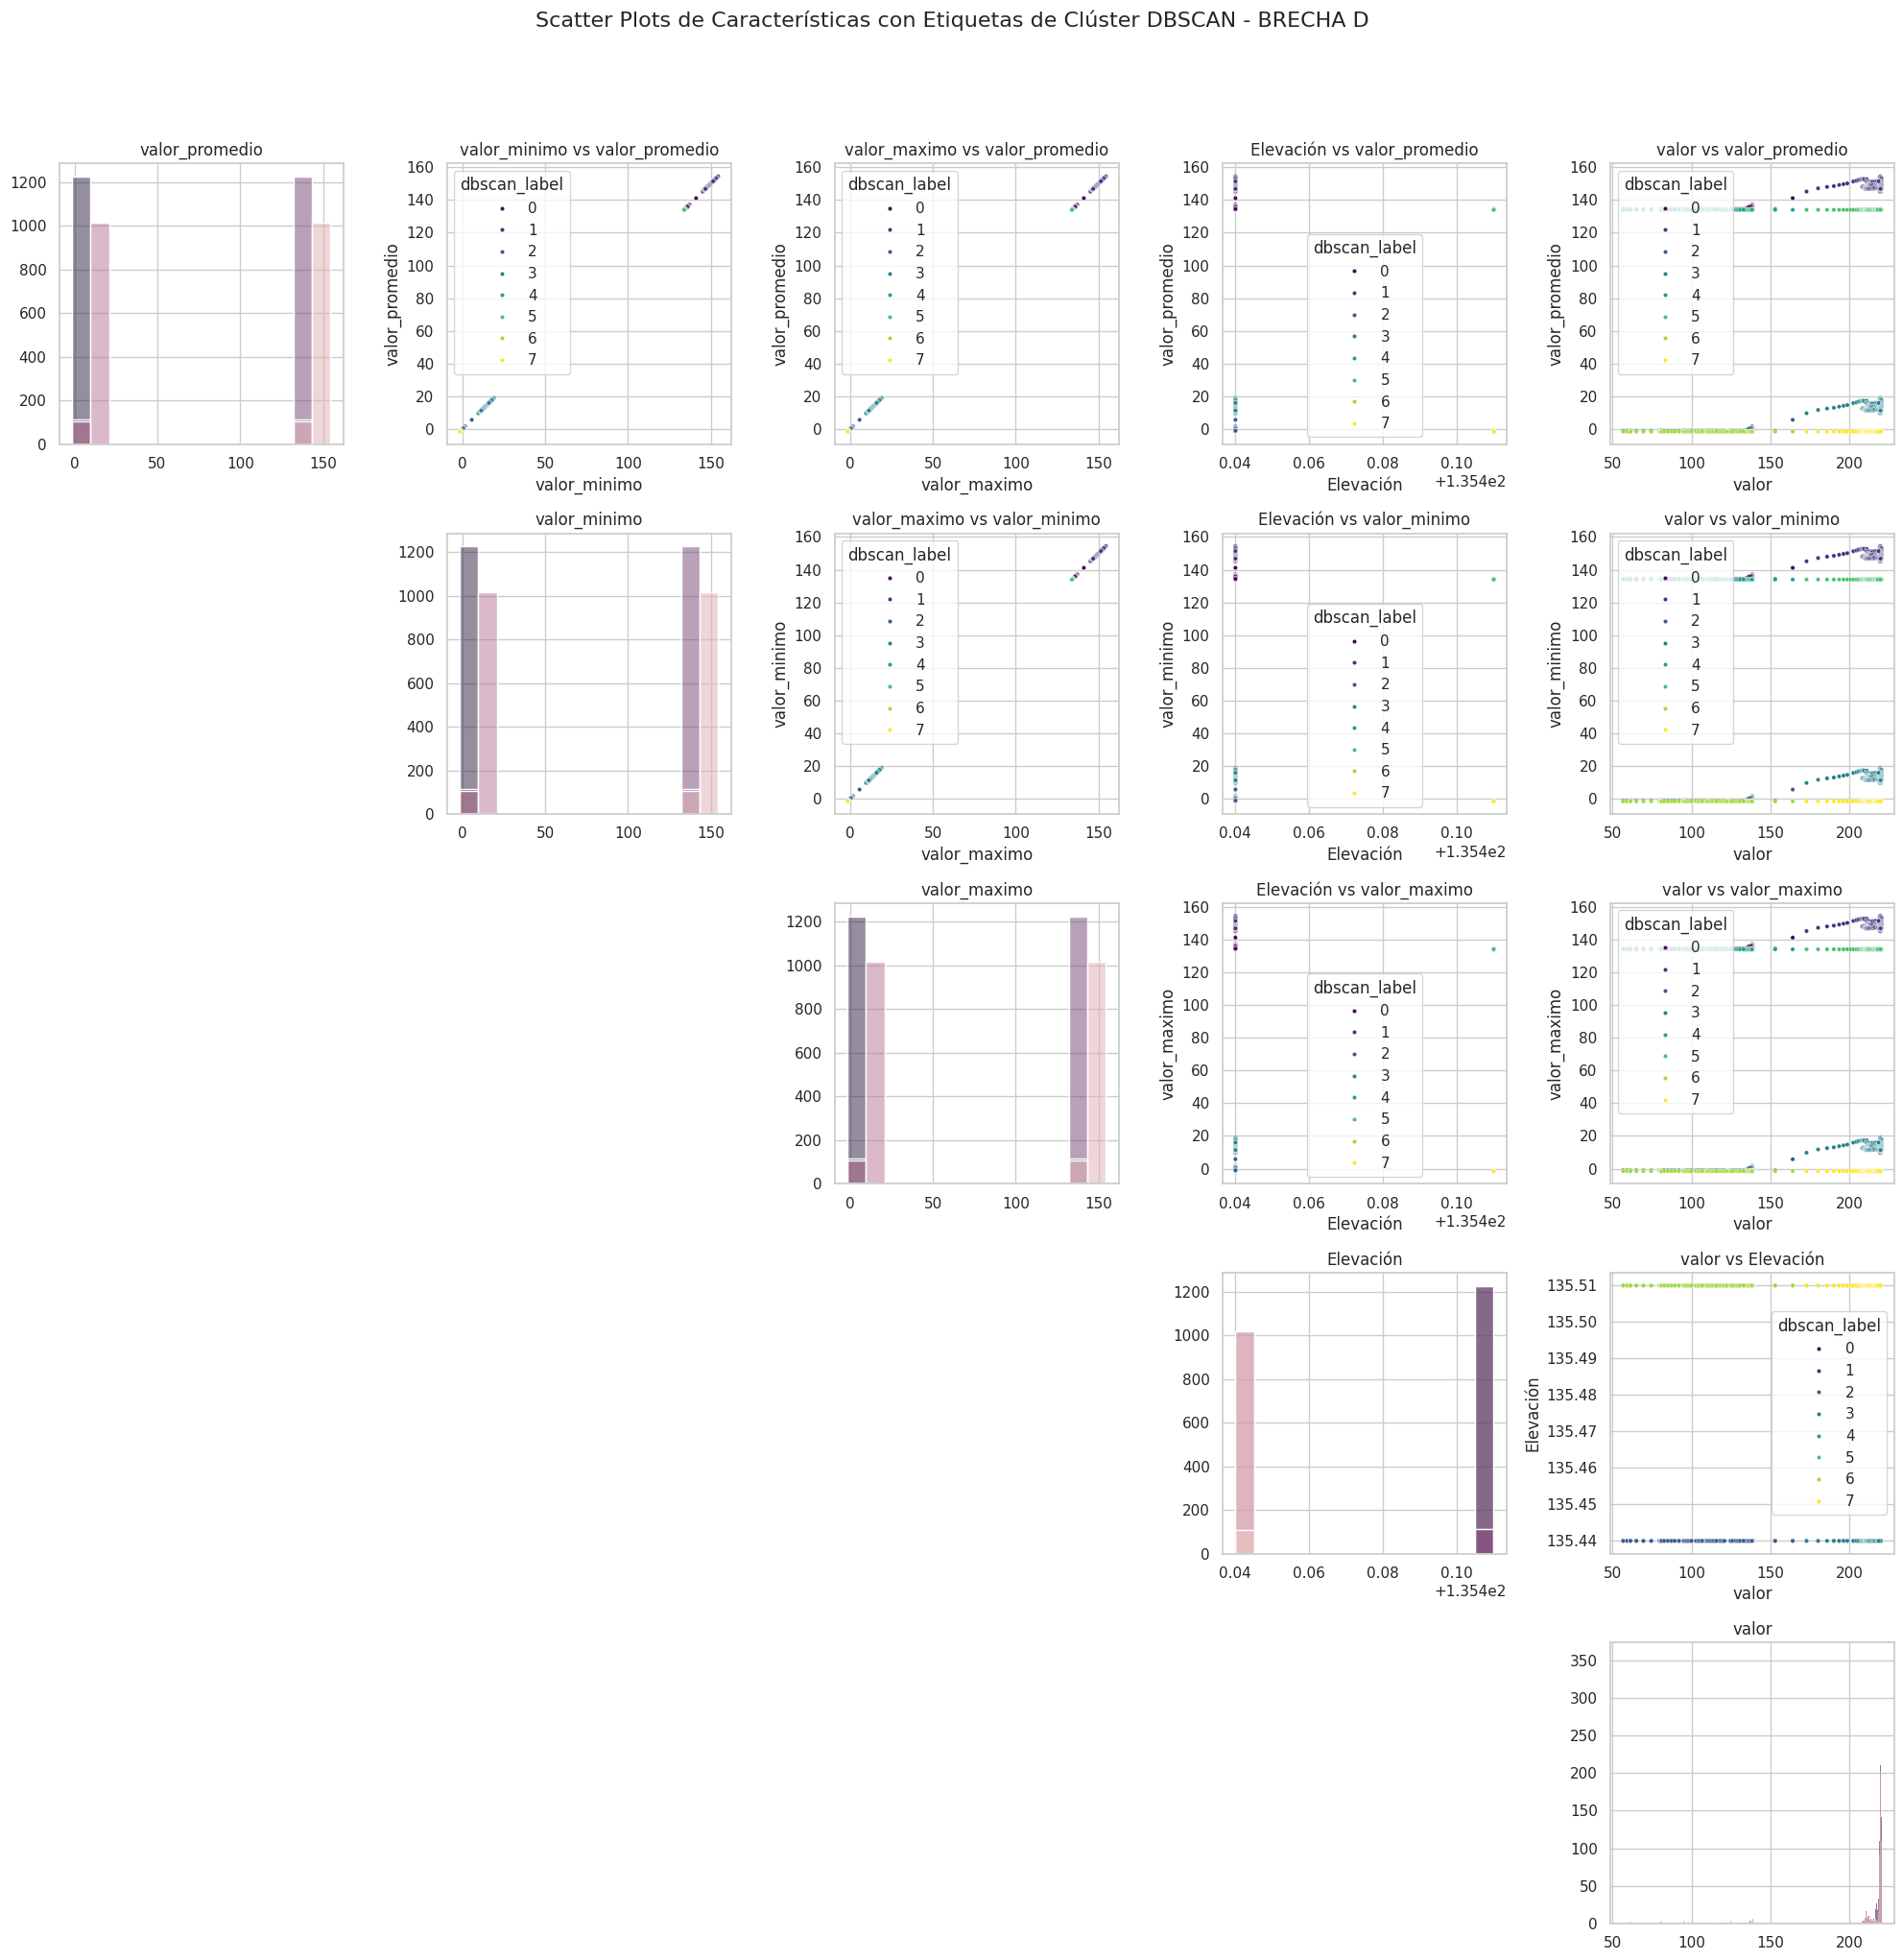


Interpretación de los gráficos de dispersión para 'BRECHA D':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.
Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.
Los puntos con etiqueta -1 (ruido) son posibles anomalías y deberían destacar,
a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.
Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.
Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.

--- Visualización de Clustering DBSCAN para: BRECHA C ---


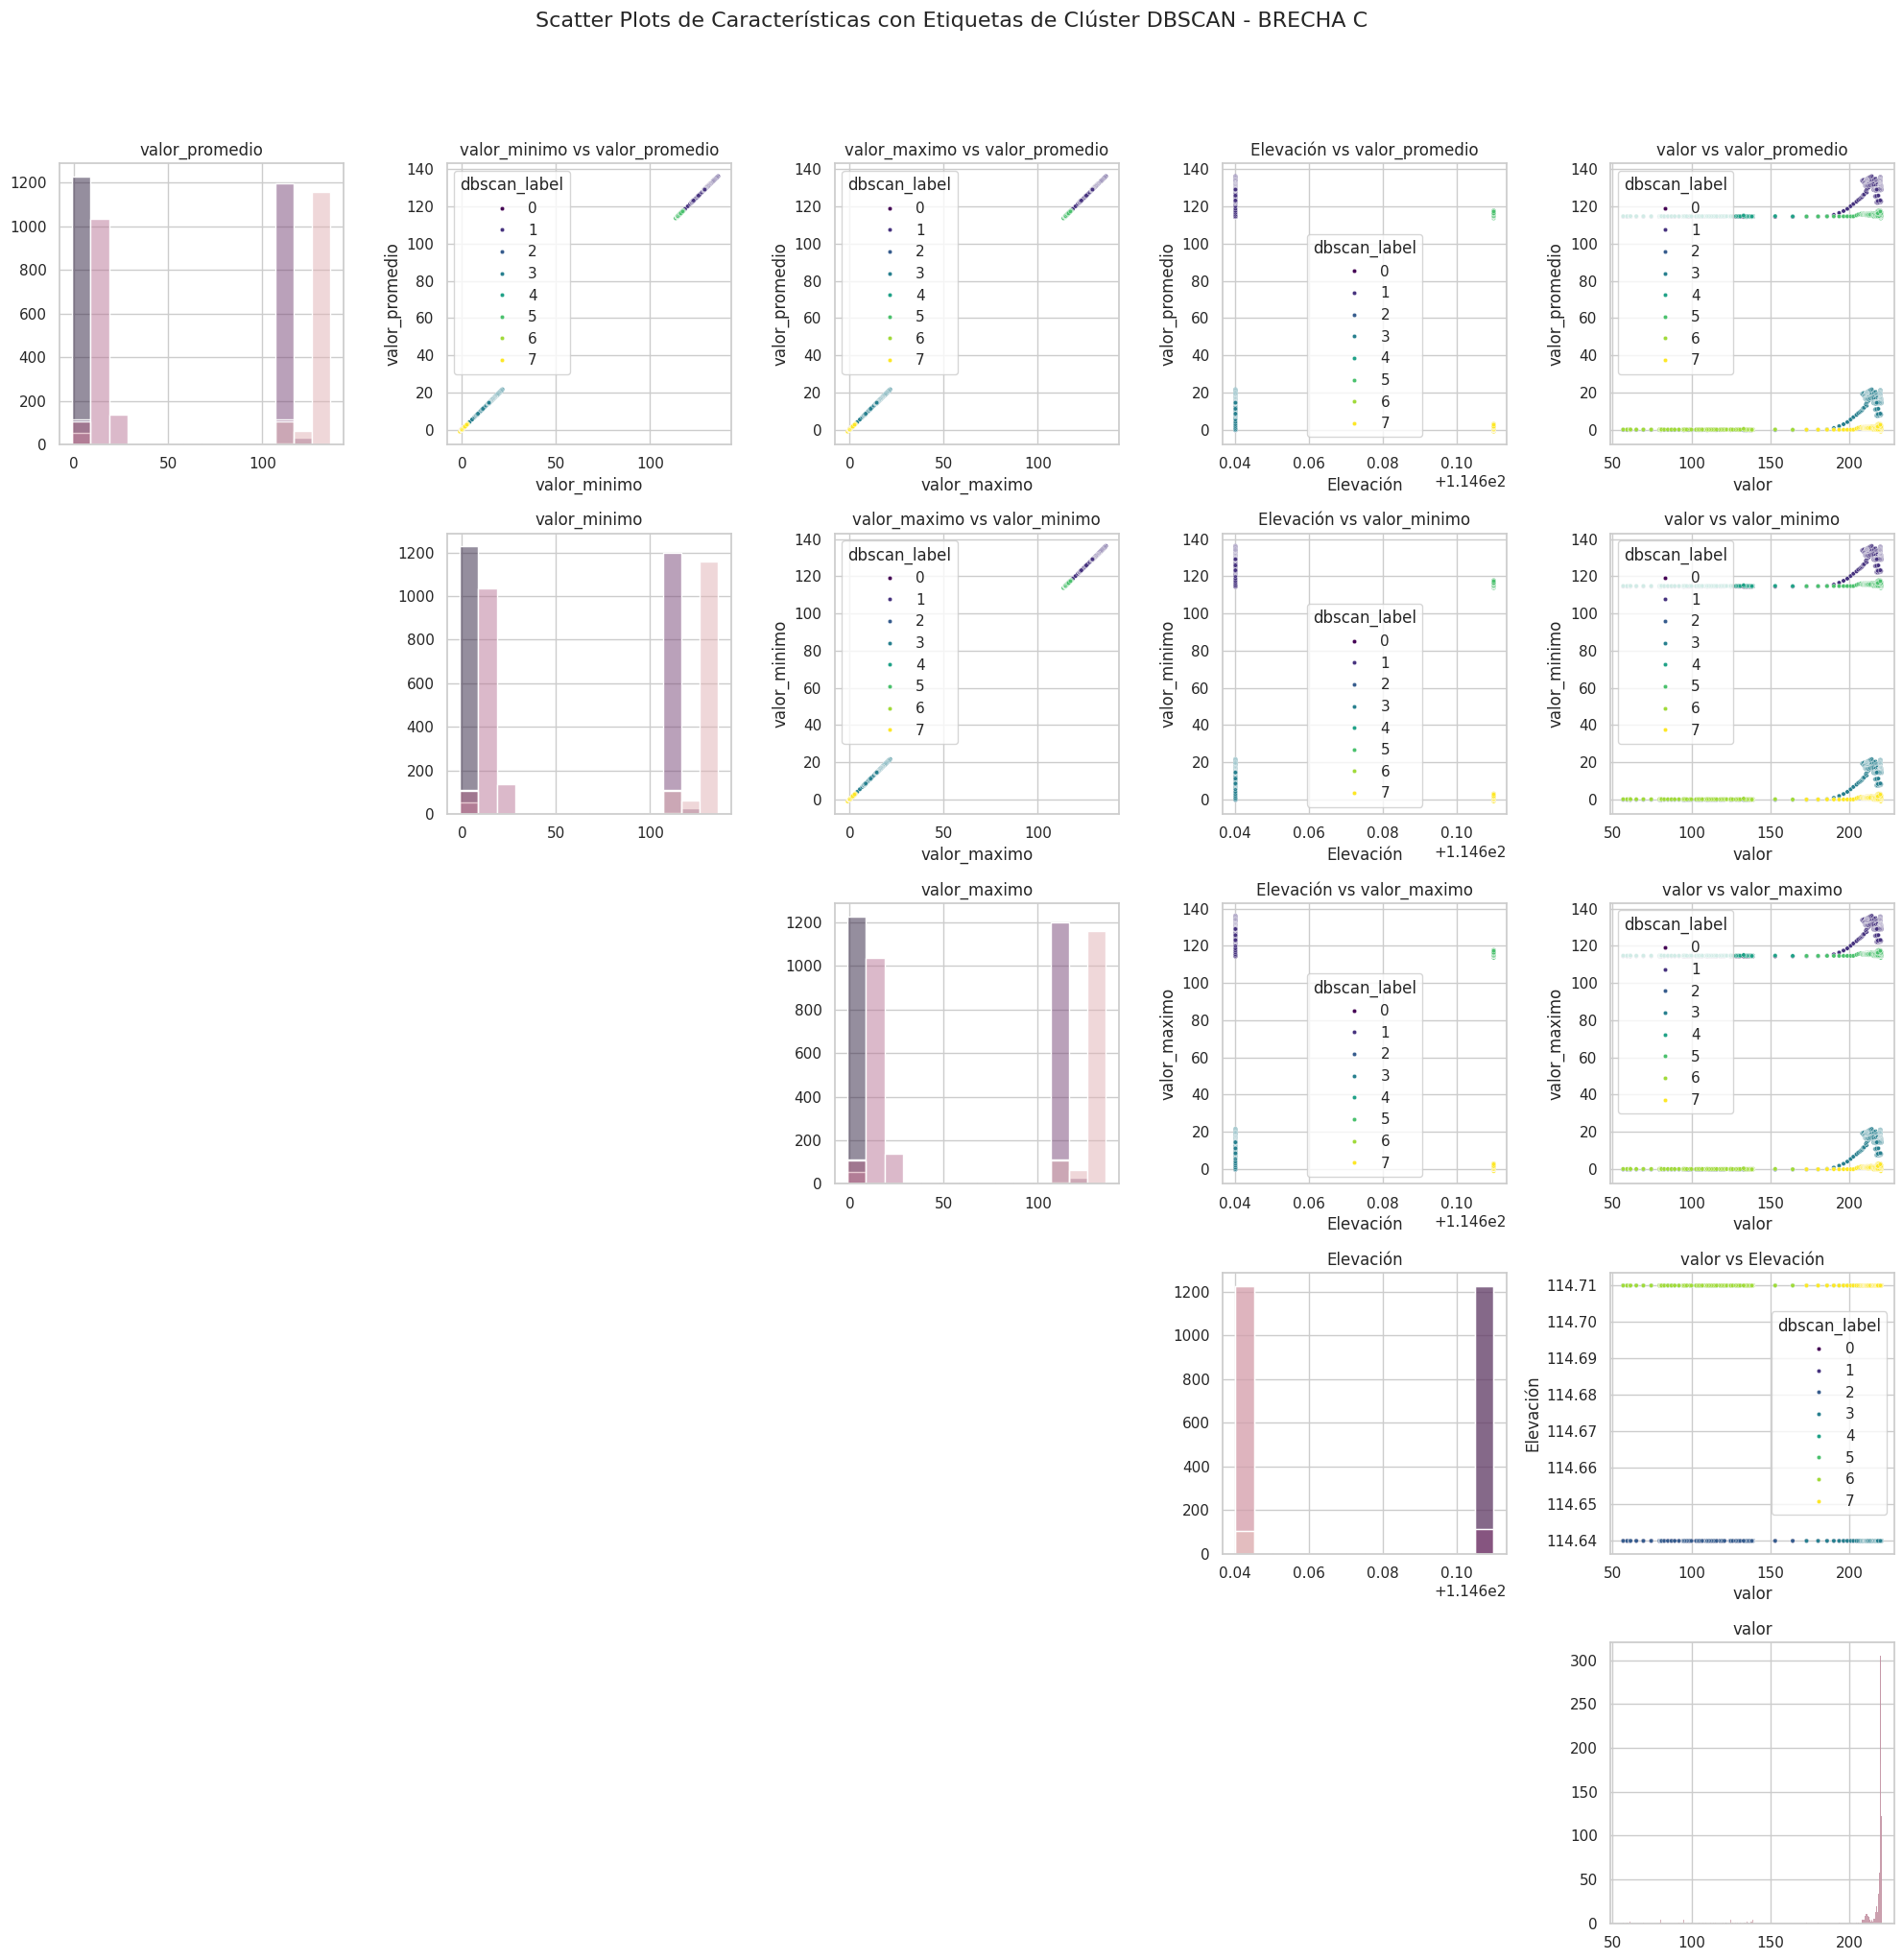


Interpretación de los gráficos de dispersión para 'BRECHA C':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.
Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.
Los puntos con etiqueta -1 (ruido) son posibles anomalías y deberían destacar,
a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.
Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.
Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.

--- Visualización de Clustering DBSCAN para: DERRAME D ---


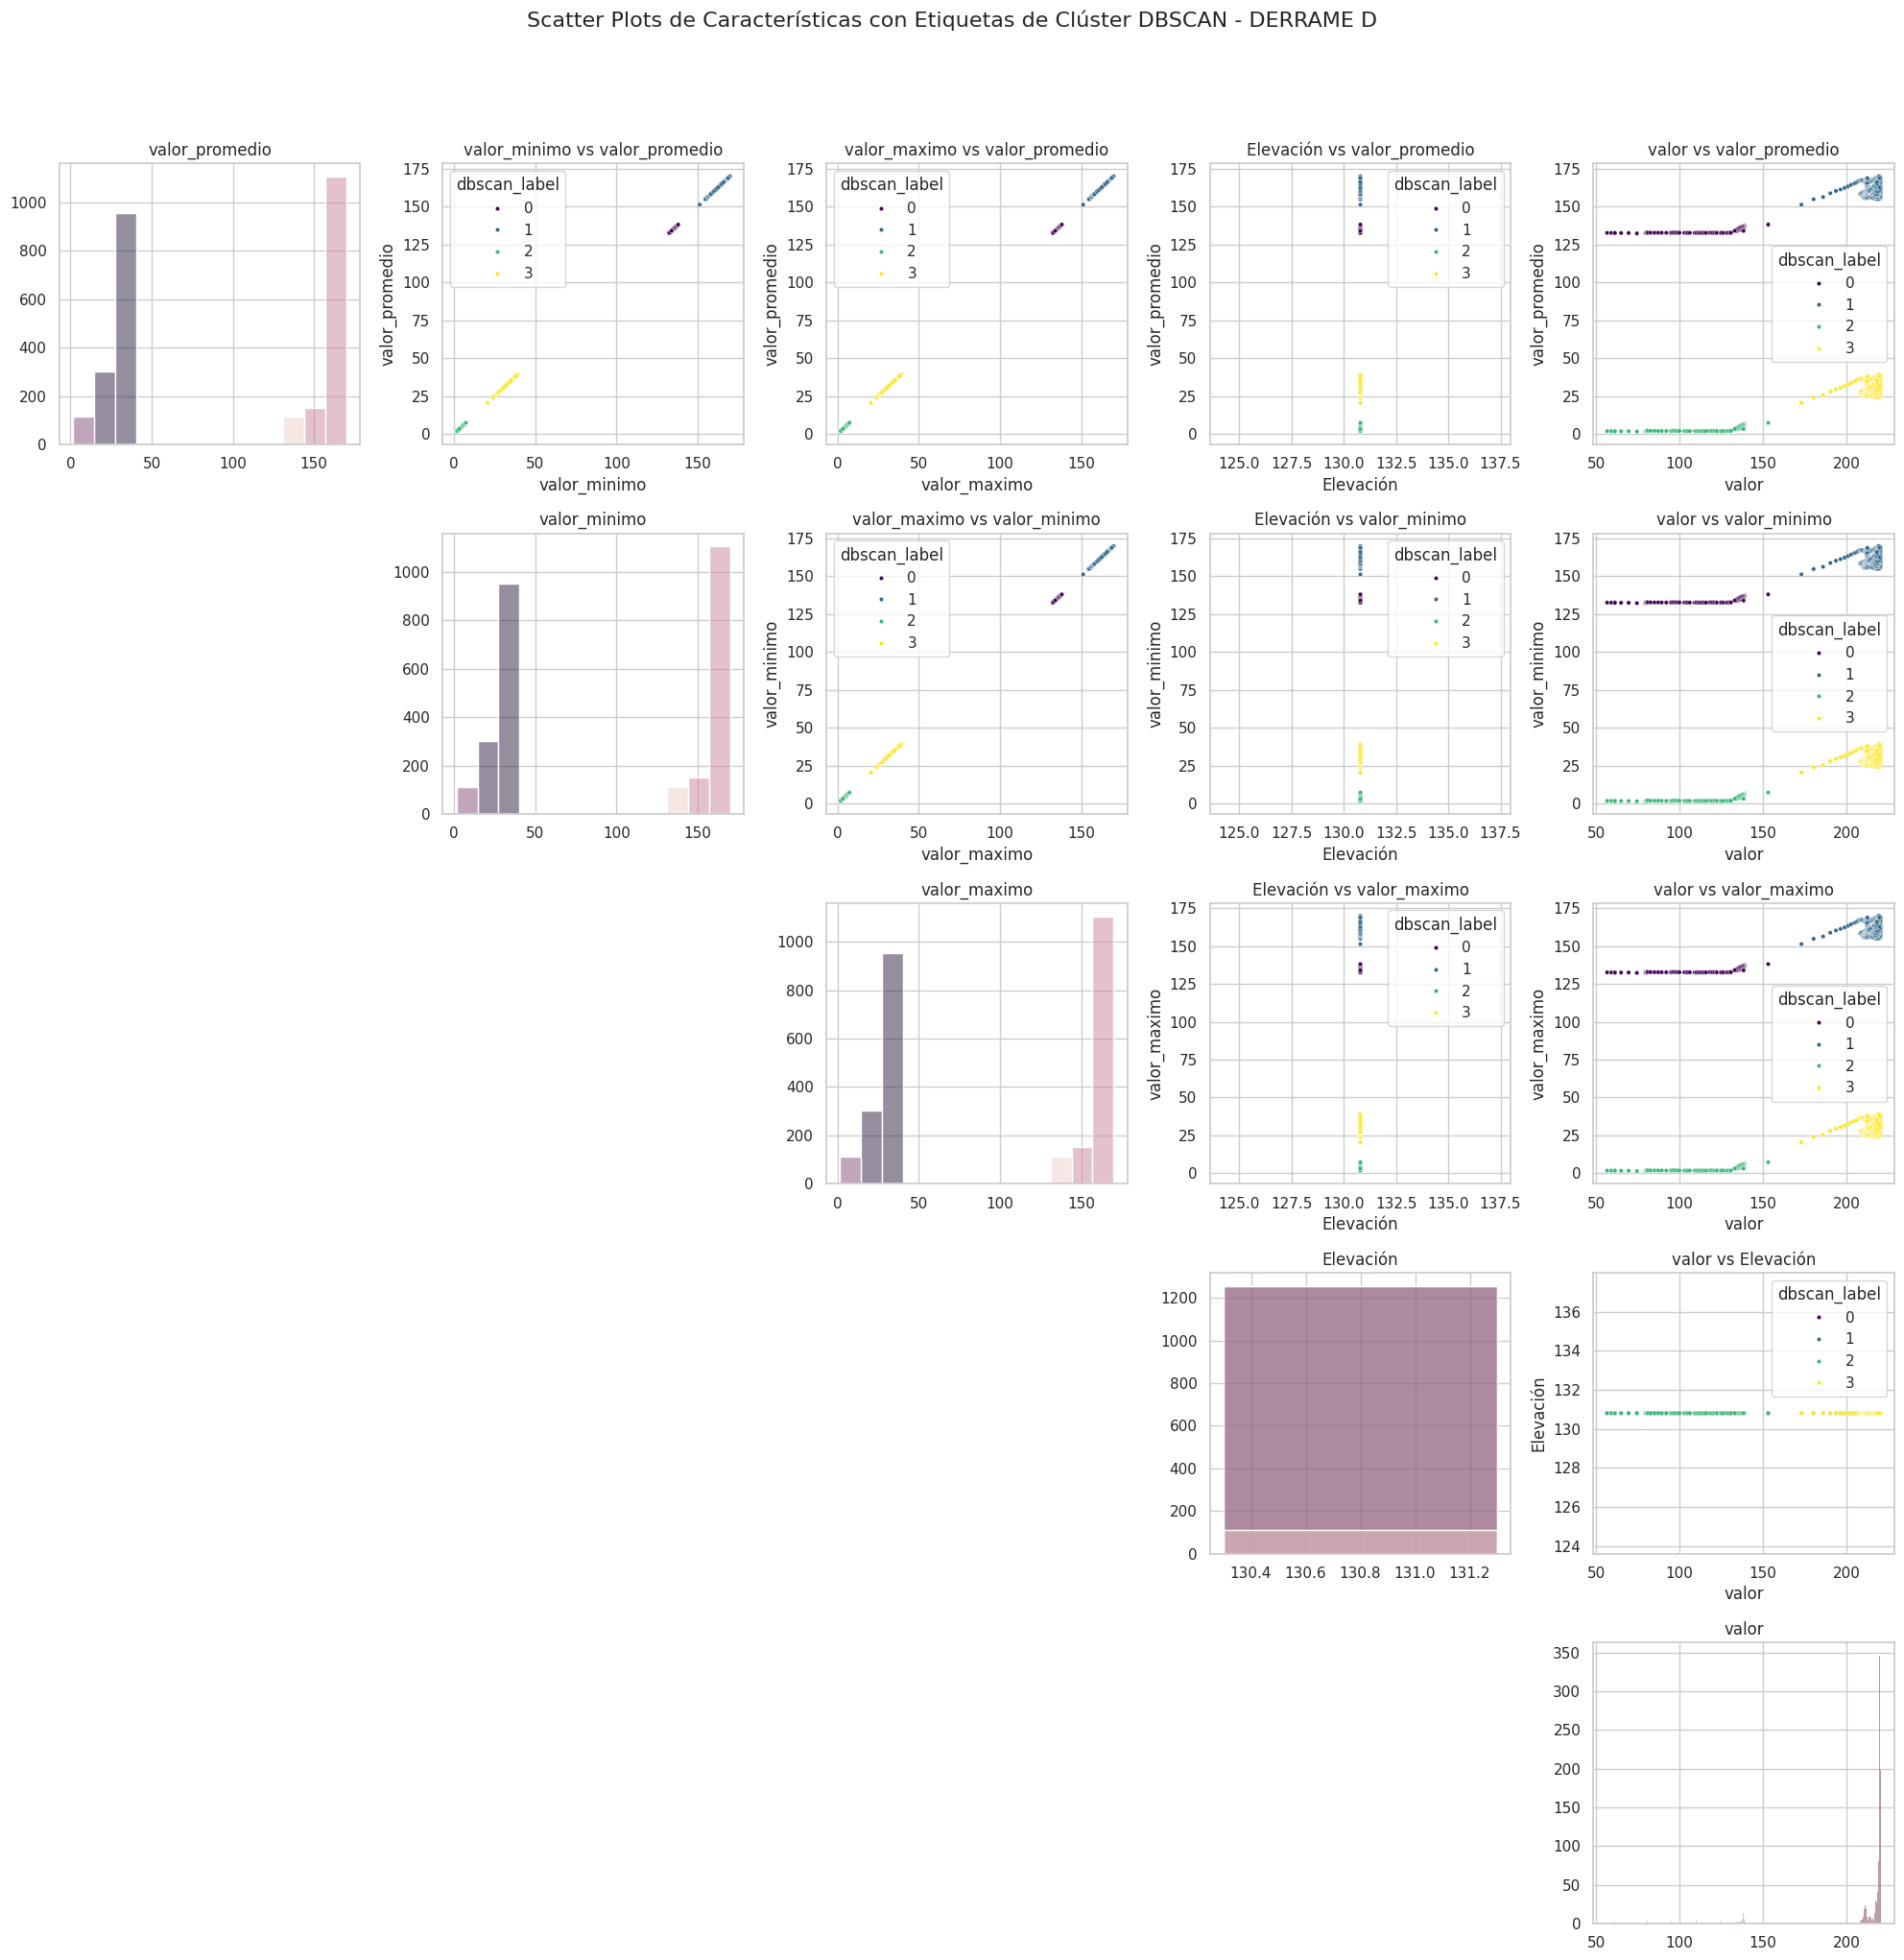


Interpretación de los gráficos de dispersión para 'DERRAME D':
Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.
Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.
Los puntos con etiqueta -1 (ruido) son posibles anomalías y deberían destacar,
a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.
Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.
Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.


In [33]:
# Iterate through the dbscan_results_by_location dictionary
for location, df_result in dbscan_results_by_location.items():
    print(f"\n--- Visualización de Clustering DBSCAN para: {location} ---")

    # Prepare the data for visualization
    # Select the features that were used for DBSCAN clustering
    # We will use the same features as defined in the previous subtask: features_for_dbscan
    features_for_dbscan_plotting = features_for_dbscan # Assuming features_for_dbscan is still available

    # Create scatter plots for pairs of the selected features
    # We'll create a matrix of scatter plots for all pairs of features.
    n_features = len(features_for_dbscan_plotting)
    fig, axes = plt.subplots(n_features, n_features, figsize=(4 * n_features, 4 * n_features))
    plt.suptitle(f"Scatter Plots de Características con Etiquetas de Clúster DBSCAN - {location}", y=1.02, fontsize=16)

    for i in range(n_features):
        for j in range(n_features):
            if i == j:
                # On the diagonal, plot a histogram of the feature
                sns.histplot(data=df_result, x=features_for_dbscan_plotting[i], hue='dbscan_label', ax=axes[i, j], legend=False) # Removed kde=True
                axes[i, j].set_xlabel("")
                axes[i, j].set_ylabel("")
                axes[i, j].set_title(features_for_dbscan_plotting[i])
            elif i < j:
                # For off-diagonal plots, create scatter plots
                sns.scatterplot(
                    data=df_result,
                    x=features_for_dbscan_plotting[j],
                    y=features_for_dbscan_plotting[i],
                    hue='dbscan_label',
                    palette='viridis', # Use a distinct color palette
                    legend='full',
                    ax=axes[i, j],
                    s=10 # Adjust point size for clarity
                )
                axes[i, j].set_title(f'{features_for_dbscan_plotting[j]} vs {features_for_dbscan_plotting[i]}')
                axes[i, j].set_xlabel(features_for_dbscan_plotting[j])
                axes[i, j].set_ylabel(features_for_dbscan_plotting[i])
            else:
                # Hide the redundant lower triangle of the matrix
                fig.delaxes(axes[i, j])

    # Improve layout and display plots
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap
    plt.show()

    # Add interpretation guidance
    print(f"\nInterpretación de los gráficos de dispersión para '{location}':")
    print("Cada gráfico muestra la relación entre pares de características utilizadas para el clustering DBSCAN.")
    print("Los puntos están coloreados según la etiqueta de clúster asignada por DBSCAN.")
    print("Los puntos con etiqueta -1 (ruido) son posibles anomalías y deberían destacar,")
    print("a menudo apareciendo aislados o en regiones de baja densidad en el espacio de características.")
    print("Los clústeres (etiquetas 0, 1, 2, etc.) representan grupos densos de puntos de datos similares.")
    print("Observar estos gráficos ayuda a visualizar cómo DBSCAN agrupó los puntos y por qué ciertos puntos fueron etiquetados como ruido.")

## Consolidar y interpretar los hallazgos

### Subtask:
Consolidar los resultados del análisis de DBSCAN de todos los grupos geológicos e interpretar los hallazgos en el contexto de la verificación espacial, identificando qué grupos o sensores presentan anomalías según DBSCAN.


**Reasoning**:
Initialize a dictionary to store the consolidated findings from the DBSCAN analysis for each geological location.



In [34]:
# 1. Initialize an empty dictionary to store the consolidated findings.
consolidated_dbscan_findings = {}

print("Diccionario 'consolidated_dbscan_findings' inicializado.")

Diccionario 'consolidated_dbscan_findings' inicializado.


**Reasoning**:
Iterate through the DBSCAN results for each geological location, extract key information about the clusters and noise points, and store it in the `consolidated_dbscan_findings` dictionary.



In [35]:
# 2. Iterate through the dbscan_results_by_location dictionary.
# 3. For each geological location, extract key information.
for location, df_result in dbscan_results_by_location.items():
    print(f"\nProcesando grupo geológico: {location}")

    # Total number of data points in the group.
    total_points = len(df_result)

    # Distribution of cluster labels.
    cluster_counts = df_result['dbscan_label'].value_counts()

    # Number of identified clusters (exclude noise label -1).
    n_clusters = len(cluster_counts) - (1 if -1 in cluster_counts else 0)

    # Number and percentage of noise points (label -1).
    noise_count = cluster_counts.get(-1, 0)
    noise_percentage = (noise_count / total_points) * 100 if total_points > 0 else 0

    # Summary of the characteristics of the noise points.
    noise_summary = None
    noise_points = df_result[df_result['dbscan_label'] == -1]
    if not noise_points.empty:
        noise_summary = noise_points[features_for_dbscan].describe().to_dict()

    # Summary of the characteristics of the identified clusters.
    cluster_summary = None
    clusters = df_result[df_result['dbscan_label'] != -1]
    if not clusters.empty:
        # Calculate mean for each cluster and store as a dictionary
        cluster_summary_df = clusters.groupby('dbscan_label')[features_for_dbscan].mean()
        cluster_summary = cluster_summary_df.apply(lambda x: x.to_dict(), axis=1).to_dict()


    # 4. Store the extracted information in the consolidated findings structure.
    consolidated_dbscan_findings[location] = {
        'total_points': total_points,
        'n_clusters': n_clusters,
        'noise_count': noise_count,
        'noise_percentage': noise_percentage,
        'noise_summary': noise_summary,
        'cluster_summary': cluster_summary
    }

print("\nExtracción de información de DBSCAN completada para todos los grupos geológicos.")
# Display the consolidated findings for review (optional, for verification)
# print("\nConsolidated DBSCAN Findings:")
# display(consolidated_dbscan_findings)


Procesando grupo geológico: CONTATO D/E

Procesando grupo geológico: ROCHA FRATURADA

Procesando grupo geológico: JUNTA D

Procesando grupo geológico: CONTATO C/D

Procesando grupo geológico: SIN ASIGNAR

Procesando grupo geológico: CONTATO CONCRETO/ROCHA

Procesando grupo geológico: BRECHA D

Procesando grupo geológico: BRECHA C

Procesando grupo geológico: DERRAME D

Extracción de información de DBSCAN completada para todos los grupos geológicos.


**Reasoning**:
Review the consolidated findings to identify patterns and significant observations across different groups and write a comprehensive interpretation of the findings in the context of spatial verification, identifying groups and sensors with anomalies and discussing potential reasons.



In [36]:
# 5. After iterating through all geological locations, review the consolidated findings.
print("\nResumen Consolidado de Hallazgos de DBSCAN por Grupo Geológico:")

# Convert the dictionary to a pandas DataFrame for easier review
consolidated_df = pd.DataFrame.from_dict(consolidated_dbscan_findings, orient='index')
display(consolidated_df[['total_points', 'n_clusters', 'noise_count', 'noise_percentage']])

# 6. Write a comprehensive interpretation of the consolidated findings in the context of spatial verification.
print("\n--- Interpretación de los Hallazgos de DBSCAN para Verificación Espacial ---")

print("\nAnálisis General:")
print("El análisis de DBSCAN se aplicó a los datos de sensores agrupados por su ubicación geológica.")
print("DBSCAN identifica grupos densos de puntos de datos (clústeres) y etiqueta los puntos que no pertenecen a ningún clúster denso como 'ruido' (etiqueta -1).")
print("Estos puntos de ruido son candidatos a ser anomalías espaciales, ya que sus características son significativamente diferentes de las de sus vecinos en la misma ubicación geológica.")

print("\nComparación entre Grupos Geológicos (Basado en Puntos de Ruido):")
# Sort locations by noise percentage to highlight those with more anomalies
consolidated_df_sorted_by_noise = consolidated_df.sort_values(by='noise_percentage', ascending=False)
display(consolidated_df_sorted_by_noise[['total_points', 'n_clusters', 'noise_count', 'noise_percentage']])

print("\nObservaciones:")
print(f"El grupo '{consolidated_df_sorted_by_noise.index[0]}' presenta el porcentaje más alto de puntos de ruido ({consolidated_df_sorted_by_noise['noise_percentage'].max():.2f}%). Esto sugiere que los sensores en esta ubicación muestran una mayor variabilidad o inconsistencia en sus mediciones en comparación con otros grupos.")
print("Los grupos con 0% de ruido ('BRECHA D', 'BRECHA C', 'DERRAME D') indican que, con los parámetros de DBSCAN utilizados, todos los puntos en estas ubicaciones forman parte de clústeres densos, lo que sugiere una mayor consistencia en los datos de los sensores en esas áreas.")

# 7. Highlight any specific sensors or features that appear to contribute more to the identification of anomalies across multiple groups.
print("\nCaracterísticas que Contribuyen a la Identificación de Anomalías:")
print("Para identificar qué características contribuyen más a que un punto sea ruido, podemos examinar las estadísticas descriptivas de los puntos de ruido ('noise_summary') para cada grupo.")
print("Generalmente, los puntos de ruido tendrán valores para una o más de las características utilizadas para el clustering que se desvían significativamente de los valores promedio o típicos de los clústeres en esa misma ubicación geológica.")

# Example of examining noise summary for a group with high noise
top_noise_location = consolidated_df_sorted_by_noise.index[0]
if consolidated_dbscan_findings[top_noise_location]['noise_summary']:
    print(f"\nEstadísticas descriptivas de los puntos de ruido en '{top_noise_location}':")
    # Convert the nested dictionary to a DataFrame for better display
    noise_summary_df = pd.DataFrame(consolidated_dbscan_findings[top_noise_location]['noise_summary'])
    display(noise_summary_df)

    print(f"\nComparación de Estadísticas de Ruido vs. Clústeres para '{top_noise_location}':")
    if consolidated_dbscan_findings[top_noise_location]['cluster_summary']:
         cluster_summary_df_compare = pd.DataFrame(consolidated_dbscan_findings[top_noise_location]['cluster_summary']).T # Transpose to have features as rows
         print("Estadísticas promedio de los clústeres:")
         display(cluster_summary_df_compare)

         print("\nObservar las diferencias entre las estadísticas de los puntos de ruido (especialmente la media) y las estadísticas promedio de los clústeres puede indicar qué características son inusuales en los puntos de ruido.")
    else:
        print("No hay clústeres identificados para comparar con los puntos de ruido en este grupo.")

print("\nPosibles Razones de las Anomalías Espaciales:")
print("- **Calidad de los Datos:** Errores en la entrada manual (como se observó previamente en el análisis de picos de error de PCA).")
print("- **Eventos Localizados:** Cambios específicos en la ubicación geológica que afectan a algunos sensores pero no a sus vecinos (ej. pequeños deslizamientos, cambios en el nivel freático local).")
print("- **Problemas del Sensor:** Mal funcionamiento de sensores individuales que reportan valores atípicos.")
print("- **Características Geológicas Específicas:** La propia naturaleza de la ubicación geológica puede generar mayor variabilidad en las lecturas de los sensores.")


# 8. Consider the limitations of the DBSCAN approach for spatial verification based on the observed results.
print("\nLimitaciones de DBSCAN para Verificación Espacial en este Contexto:")
print("- **Sensibilidad a Parámetros:** Los resultados de DBSCAN (`eps` y `min_samples`) pueden variar significativamente dependiendo de la elección de los parámetros. La selección de parámetros óptimos puede ser un desafío.")
print("- **Dependencia de las Características:** El rendimiento de DBSCAN depende en gran medida de las características seleccionadas para el clustering. Características irrelevantes o ruidosas pueden afectar la identificación de clústeres y ruido.")
print("- **Definición de 'Espacialidad':** En este análisis, 'espacialidad' se aproximó agrupando por 'local_geologico'. DBSCAN se aplicó al espacio de características de los valores de los sensores, no a coordenadas geográficas explícitas (que tenían muchos valores faltantes). Si las coordenadas estuvieran completas, DBSCAN podría aplicarse directamente al espacio geográfico (2D o 3D) para encontrar agrupaciones de sensores y sensores aislados (ruido espacial geográfico).")
print("- **Variabilidad Temporal:** DBSCAN, tal como se aplicó aquí, considera todos los puntos de datos (incluyendo diferentes fechas) juntos para cada ubicación geológica. No modela explícitamente la variabilidad o patrones temporales dentro de cada ubicación.")
print("- **Interpretación de Clústeres:** Identificar clústeres no siempre implica una anomalía. Los clústeres representan simplemente grupos de puntos similares. La verificación de anomalías se centra principalmente en los puntos de ruido.")

print("\nConclusión:")
print("El análisis de DBSCAN por grupo geológico ha identificado puntos de datos que se desvían del comportamiento típico de sus vecinos dentro de la misma ubicación. Estos puntos de ruido son fuertes candidatos para una verificación adicional como posibles anomalías espaciales. La prevalencia de ruido varía entre los grupos geológicos, sugiriendo que algunas ubicaciones pueden ser inherentemente más variables o susceptibles a problemas de datos/sensores. La interpretación detallada de los puntos de ruido y la comparación con los clústeres es crucial para diagnosticar la posible causa de estas anomalías.")


Resumen Consolidado de Hallazgos de DBSCAN por Grupo Geológico:


,total_points,n_clusters,noise_count,noise_percentage
CONTATO D/E,14580,7,23,0.157750
ROCHA FRATURADA,5449,4,12,0.220224
JUNTA D,18195,10,24,0.131904
CONTATO C/D,4539,9,128,2.820004
SIN ASIGNAR,14691,9,94,0.639848
CONTATO CONCRETO/ROCHA,4440,4,6,0.135135
BRECHA D,4924,8,0,0.000000
BRECHA C,5346,8,0,0.000000
DERRAME D,2738,4,0,0.000000



--- Interpretación de los Hallazgos de DBSCAN para Verificación Espacial ---

Análisis General:
El análisis de DBSCAN se aplicó a los datos de sensores agrupados por su ubicación geológica.
DBSCAN identifica grupos densos de puntos de datos (clústeres) y etiqueta los puntos que no pertenecen a ningún clúster denso como 'ruido' (etiqueta -1).
Estos puntos de ruido son candidatos a ser anomalías espaciales, ya que sus características son significativamente diferentes de las de sus vecinos en la misma ubicación geológica.

Comparación entre Grupos Geológicos (Basado en Puntos de Ruido):


,total_points,n_clusters,noise_count,noise_percentage
CONTATO C/D,4539,9,128,2.820004
SIN ASIGNAR,14691,9,94,0.639848
ROCHA FRATURADA,5449,4,12,0.220224
CONTATO D/E,14580,7,23,0.157750
CONTATO CONCRETO/ROCHA,4440,4,6,0.135135
JUNTA D,18195,10,24,0.131904
BRECHA D,4924,8,0,0.000000
BRECHA C,5346,8,0,0.000000
DERRAME D,2738,4,0,0.000000



Observaciones:
El grupo 'CONTATO C/D' presenta el porcentaje más alto de puntos de ruido (2.82%). Esto sugiere que los sensores en esta ubicación muestran una mayor variabilidad o inconsistencia en sus mediciones en comparación con otros grupos.
Los grupos con 0% de ruido ('BRECHA D', 'BRECHA C', 'DERRAME D') indican que, con los parámetros de DBSCAN utilizados, todos los puntos en estas ubicaciones forman parte de clústeres densos, lo que sugiere una mayor consistencia en los datos de los sensores en esas áreas.

Características que Contribuyen a la Identificación de Anomalías:
Para identificar qué características contribuyen más a que un punto sea ruido, podemos examinar las estadísticas descriptivas de los puntos de ruido ('noise_summary') para cada grupo.
Generalmente, los puntos de ruido tendrán valores para una o más de las características utilizadas para el clustering que se desvían significativamente de los valores promedio o típicos de los clústeres en esa misma ubicación geo

,valor_promedio,valor_minimo,valor_maximo,Elevación,valor
count,128.000000,128.000000,128.000000,1.280000e+02,128.000000
mean,9.682864,4.683594,17.056094,1.072600e+02,217.797188
std,4.986825,5.219644,6.168564,1.712003e-13,8.196415
min,-0.958649,-2.310000,-0.920000,1.072600e+02,153.100000
25%,6.441592,0.930000,15.152500,1.072600e+02,218.840000
50%,10.010505,3.365000,19.620000,1.072600e+02,219.375000
75%,12.713602,6.117500,20.812500,1.072600e+02,220.052500
max,22.600000,22.600000,23.720000,1.072600e+02,220.450000



Comparación de Estadísticas de Ruido vs. Clústeres para 'CONTATO C/D':
Estadísticas promedio de los clústeres:


,valor_promedio,valor_minimo,valor_maximo,Elevación,valor
0,-0.631265,-0.961289,0.056530,107.26,219.043804
1,8.122461,1.213750,20.967500,107.26,218.550000
2,8.973919,2.897500,17.390000,107.26,219.290000
3,7.592300,1.622000,16.144000,107.26,219.690000
4,6.119665,1.126667,12.796667,107.26,218.791667
5,5.904184,1.105714,9.367143,107.26,219.148571
6,5.578875,0.176000,11.418000,107.26,219.992000
7,14.545008,8.391667,22.516667,107.26,219.496667
8,-0.038036,-0.038036,-0.038036,107.26,132.329643



Observar las diferencias entre las estadísticas de los puntos de ruido (especialmente la media) y las estadísticas promedio de los clústeres puede indicar qué características son inusuales en los puntos de ruido.

Posibles Razones de las Anomalías Espaciales:
- **Calidad de los Datos:** Errores en la entrada manual (como se observó previamente en el análisis de picos de error de PCA).
- **Eventos Localizados:** Cambios específicos en la ubicación geológica que afectan a algunos sensores pero no a sus vecinos (ej. pequeños deslizamientos, cambios en el nivel freático local).
- **Problemas del Sensor:** Mal funcionamiento de sensores individuales que reportan valores atípicos.
- **Características Geológicas Específicas:** La propia naturaleza de la ubicación geológica puede generar mayor variabilidad en las lecturas de los sensores.

Limitaciones de DBSCAN para Verificación Espacial en este Contexto:
- **Sensibilidad a Parámetros:** Los resultados de DBSCAN (`eps` y `min_samples`) puede

## Resumen:

* Análisis de Correlación (EM-E-002): Se encontró una muy alta correlación estática y rodante entre valor_promedio y valor_minimo dentro del grupo EM-E-002.
* Análisis de PCA (EM-E-002): Se aplicó PCA al grupo EM-E-002, identificando que 2 componentes principales retienen el 95% de la varianza. Se calculó el error de reconstrucción, y los picos en este error fueron identificados como posibles anomalías temporales que deberían ser confirmados por la Verificación Temporal (Residuos).
* Análisis de Picos de Error (EM-E-002): La investigación de los datos originales en las fechas con altos errores de reconstrucción sugirió que las inconsistencias en los valores, particularmente en Elevación, y la prevalencia de datos de entrada manual (MAN) podrían ser las causas principales de estos picos.
* Análisis de DBSCAN por Grupo Geológico: Se aplicó DBSCAN a los datos agrupados por local_geologico. Se identificaron puntos de ruido (posibles anomalías espaciales) en varios grupos, siendo 'CONTATO C/D' el que presentó el mayor porcentaje de ruido. Los grupos 'BRECHA D', 'BRECHA C' y 'DERRAME D' no mostraron ruido con los parámetros actuales. El análisis de las estadísticas de ruido versus clústeres ayuda a entender qué características son atípicas en los puntos de ruido.

### Hallazgos clave del análisis de datos

* DBSCAN se aplicó con éxito a los datos de los sensores para cada ubicación geológica, identificando clústeres y puntos de ruido (posibles anomalías espaciales).
* El porcentaje de puntos de ruido varió significativamente entre los grupos geológicos, con 'CONTATO C/D' mostrando el porcentaje más alto (2.82%).
* Algunos grupos ('BRECHA D', 'BRECHA C', 'DERRAME D') tuvieron un 0% de puntos de ruido con los parámetros elegidos, lo que sugiere datos más consistentes en esas áreas.
* Las visualizaciones mostraron cómo se distribuyen los puntos de ruido en el espacio de características, a menudo apareciendo aislados de los clústeres densos.
* El análisis de las estadísticas de los puntos de ruido para grupos con alto ruido ayuda a identificar qué características contribuyen más a que un punto se considere una anomalía.

### Próximos Pasos

* Investigar los puntos de ruido específicos identificados por DBSCAN, particularmente en el grupo 'CONTATO C/D', para determinar la causa raíz de su comportamiento anómalo (por ejemplo, errores de entrada de datos, problemas de sensores, eventos geológicos localizados).
* Refinar los parámetros de DBSCAN (`eps` y `min_samples`) o explorar métodos de clustering alternativos para identificar potencialmente diferentes patrones o un conjunto más robusto de anomalías, considerando la sensibilidad de DBSCAN a la elección de parámetros.